# Template 07: SHAP Analysis

**Purpose:** Generate residual + SHAP range plots for top features

**Inputs:**
- results/06_shap_train.parquet
- results/06_shap_test.parquet
- results/05_predictions_train.parquet
- results/05_predictions_test.parquet
- data/04_train.parquet
- data/04_test.parquet

**Outputs:**
- plots/{dataset}_{feature}_residual.png
- plots/{dataset}_{feature}_shap_range.png
- results/07_analysis_summary.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yaml
import os
import sys
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from shap_utils import compute_shap_aggregate, create_residual_plot, create_shap_range_plot

print("########################################")
print("# STAGE 07: SHAP ANALYSIS")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 07: SHAP ANALYSIS
########################################


In [4]:
with open(f"{config_path}/config.yaml") as f:
    cfg = yaml.safe_load(f)
output_base = cfg["paths"]["output_base"]
shap_cfg = cfg.get("shap_analysis", {})
top_n = shap_cfg.get("top_n_features", 40)
datasets = shap_cfg.get("datasets", ["train", "test"])
resid_cfg = shap_cfg.get("residual_plot", {})
shap_range_cfg = shap_cfg.get("shap_range_plot", {})
print(f"\nConfig: top_n={top_n}")


Config: top_n=40


In [5]:
plots_dir = f"{output_base}/plots"
os.makedirs(plots_dir, exist_ok=True)
print(f"Plots: {plots_dir}")

Plots: output/car_coll/v1/plots


In [6]:
print("\nLoading...")
shap_train = pd.read_parquet(f"{output_base}/results/06_shap_train.parquet")
shap_test = pd.read_parquet(f"{output_base}/results/06_shap_test.parquet")
preds_train = pd.read_parquet(f"{output_base}/results/05_predictions_train.parquet")
preds_test = pd.read_parquet(f"{output_base}/results/05_predictions_test.parquet")
df_train = pd.read_parquet(f"{output_base}/data/04_train.parquet")
df_test = pd.read_parquet(f"{output_base}/data/04_test.parquet")
print(f"SHAP: {shap_train.shape}, {shap_test.shape}")
print(f"Preds: {preds_train.shape}, {preds_test.shape}")


Loading...


SHAP: (10000, 91), (3750266, 91)
Preds: (3757142, 3), (3750266, 3)


In [7]:
# Merge train data with predictions
data_tr = df_train.loc[shap_train.index].copy()
data_tr['actual'] = preds_train.loc[shap_train.index, 'actual']
data_tr['pred'] = preds_train.loc[shap_train.index, 'pred']
data_tr['weight'] = preds_train.loc[shap_train.index, 'exposure']

fc_tr = shap_train.copy()
fc_tr['weight'] = data_tr['weight']
out_tr = data_tr
print(f"Train: {out_tr.shape}")

Train: (10000, 125)


In [8]:
# Merge test data with predictions
data_te = df_test.loc[shap_test.index].copy()
data_te['actual'] = preds_test.loc[shap_test.index, 'actual']
data_te['pred'] = preds_test.loc[shap_test.index, 'pred']
data_te['weight'] = preds_test.loc[shap_test.index, 'exposure']

fc_te = shap_test.copy()
fc_te['weight'] = data_te['weight']
out_te = data_te
print(f"Test: {out_te.shape}")

Test: (3750266, 125)


In [9]:
print("\nSHAP aggregates...")
shagg, shagg_num, shagg2 = compute_shap_aggregate(fc_tr, weight_col="weight")
print(f"Features: {len(shagg2)}")
print(shagg2.head(10))


SHAP aggregates...
Features: 62
                               field   total_shap
8              multi_pol_unknown_cal  1130.048101
87           cef_first_poten_dam_ind   552.095216
7                        married_ind   460.690974
89               cef_lien_holder_ind   376.678783
66              vc_premium_audio_raw   260.115446
17                      vc_doors_raw   207.166553
70                 vc_rear_wiper_raw   194.208523
54        vc_heated_side_mirrors_raw   109.046074
74     vc_speed_sensitive_volume_raw   104.541002
34  vc_auto_dimming_side_mirrors_raw    87.333031


In [10]:
features = shagg2["field"].head(top_n).tolist()
print(f"\nPlotting {len(features)} features")


Plotting 40 features


In [11]:
summary = {"timestamp": datetime.now().isoformat(), "plots": 0}
plots_by_feature = {}

In [12]:
print("="*60)
print("GENERATING PLOTS")
print("="*60)
for i, f in enumerate(features, 1):
    print(f"[{i}/{len(features)}] {f}")
    plots_by_feature[f] = []
    if f not in out_tr.columns or f not in out_te.columns:
        print(f"  WARNING: Feature {f} not found, skipping")
        continue
    if "train" in datasets:
        try:
            fig, _ = create_residual_plot(out_tr, f, "weight", dataset_label="Train", **resid_cfg)
            path = f"{plots_dir}/train_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_tr, data_tr, f, "weight", dataset_label="Train", **shap_range_cfg)
            path = f"{plots_dir}/train_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train SHAP): {e}")
    if "test" in datasets:
        try:
            fig, _ = create_residual_plot(out_te, f, "weight", dataset_label="Test", **resid_cfg)
            path = f"{plots_dir}/test_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_te, data_te, f, "weight", dataset_label="Test", **shap_range_cfg)
            path = f"{plots_dir}/test_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test SHAP): {e}")
print(f"\n[OK] Generated summary")

GENERATING PLOTS
[1/40] multi_pol_unknown_cal

multi_pol_unknown_cal Summary:
 multi_pol_unknown_cal      weight   act_rate  pred_rate
                     0 4893.490703 376.151343 262.630953
                     1 1233.280373 976.859625 487.983066


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


multi_pol_unknown_cal Summary:
 multi_pol_unknown_cal       weight   act_rate  pred_rate
                     0 1.830932e+06 248.323618 264.444410
                     1 4.566378e+05 848.310303 491.131277


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

[2/40] cef_first_poten_dam_ind

cef_first_poten_dam_ind Summary:
 cef_first_poten_dam_ind      weight   act_rate  pred_rate
                     0.0 3411.666292 426.845189 267.858920
                     1.0 2715.104783 585.311317 358.423322


...

[40/40] vc_aspiration_forced_induction_ind

vc_aspiration_forced_induction_ind Summary:
 vc_aspiration_forced_induction_ind      weight   act_rate  pred_rate
                                  0 5208.643102 522.882644 312.931716
                                  1  918.127974 350.632843 279.974587
  ERROR (Train SHAP): cannot reindex on an axis with duplicate labels


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


vc_aspiration_forced_induction_ind Summary:
 vc_aspiration_forced_induction_ind       weight   act_rate  pred_rate
                                  0 1.931415e+06 367.134754 315.036973
                                  1 3.561548e+05 373.277536 280.725423


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

  ERROR (Test SHAP): cannot reindex on an axis with duplicate labels

[OK] Generated summary



DISPLAYING ALL PLOTS

FEATURE: multi_pol_unknown_cal


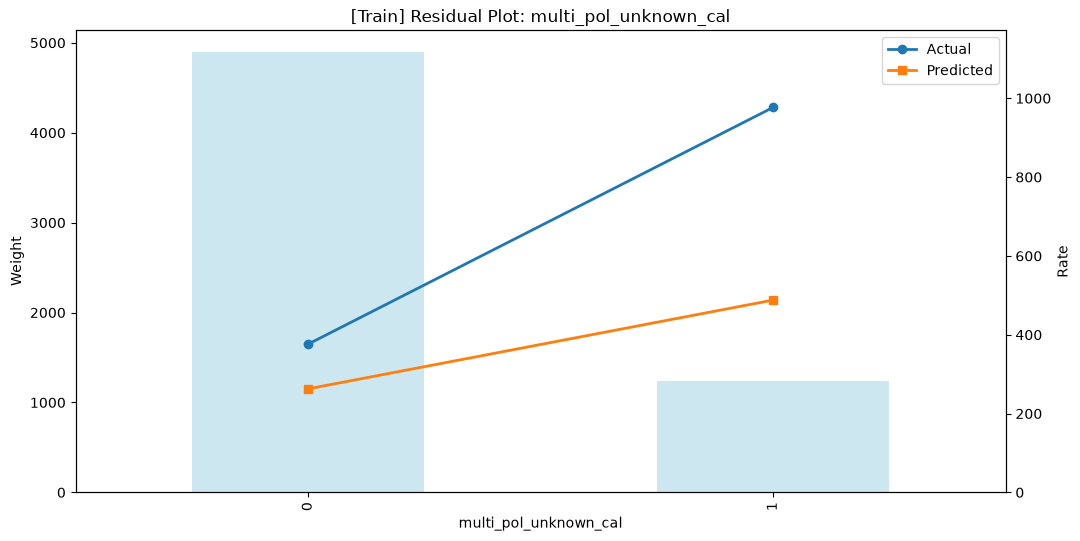

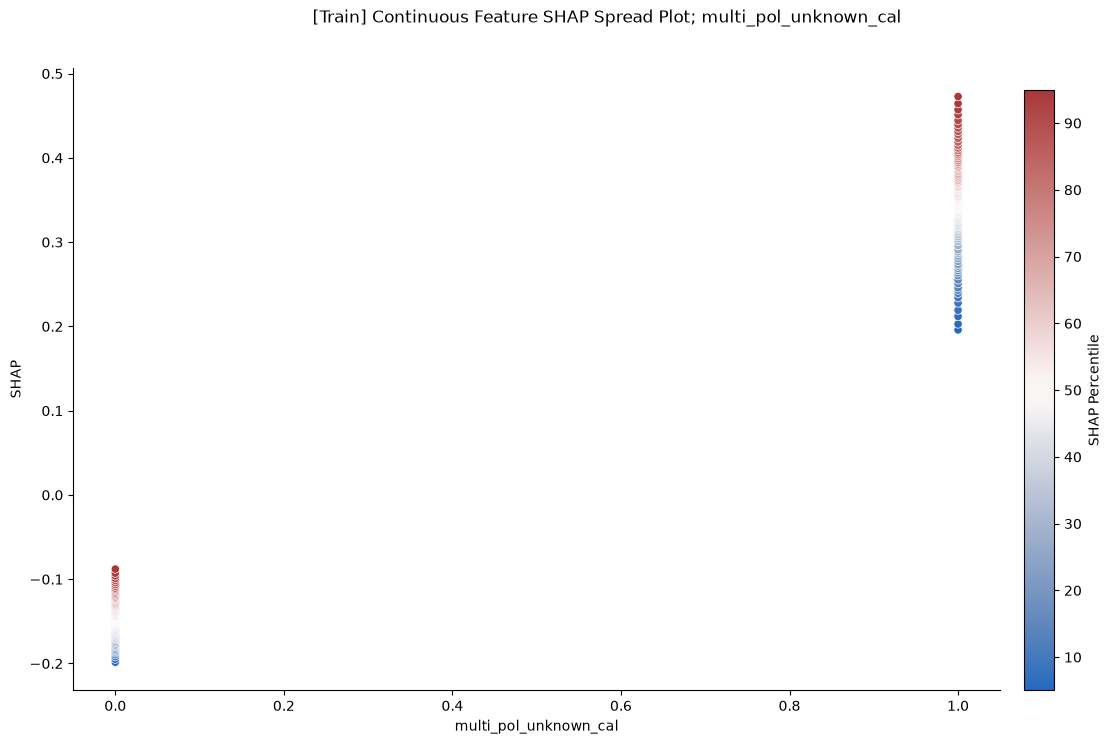

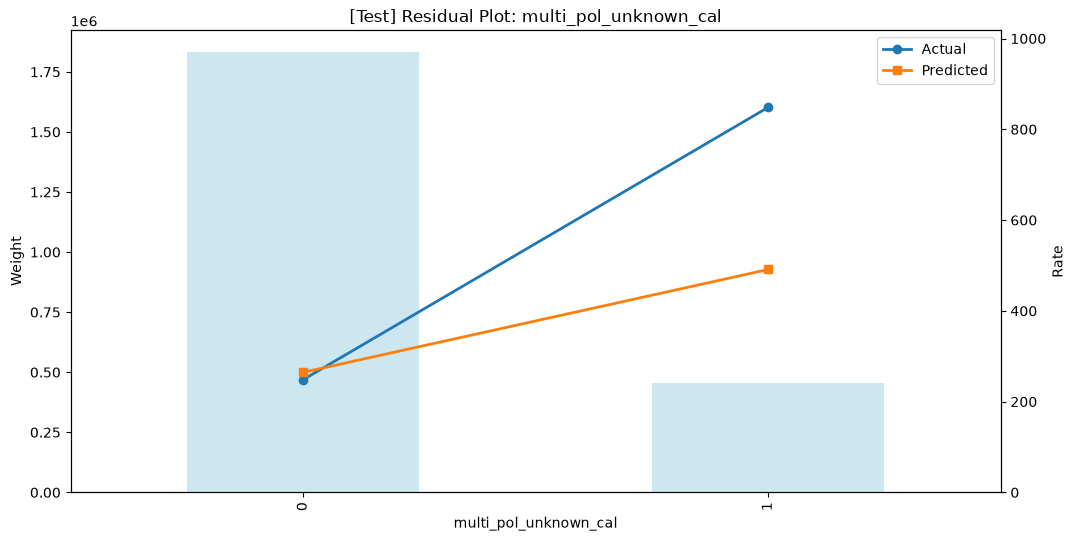

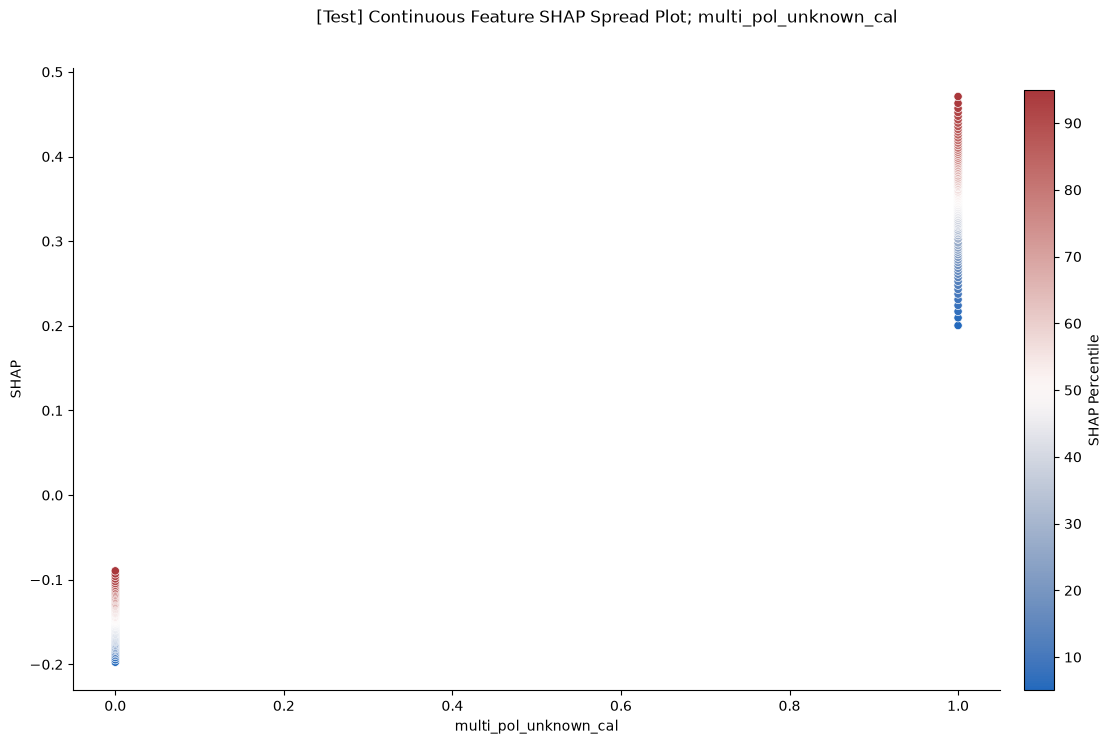


FEATURE: cef_first_poten_dam_ind


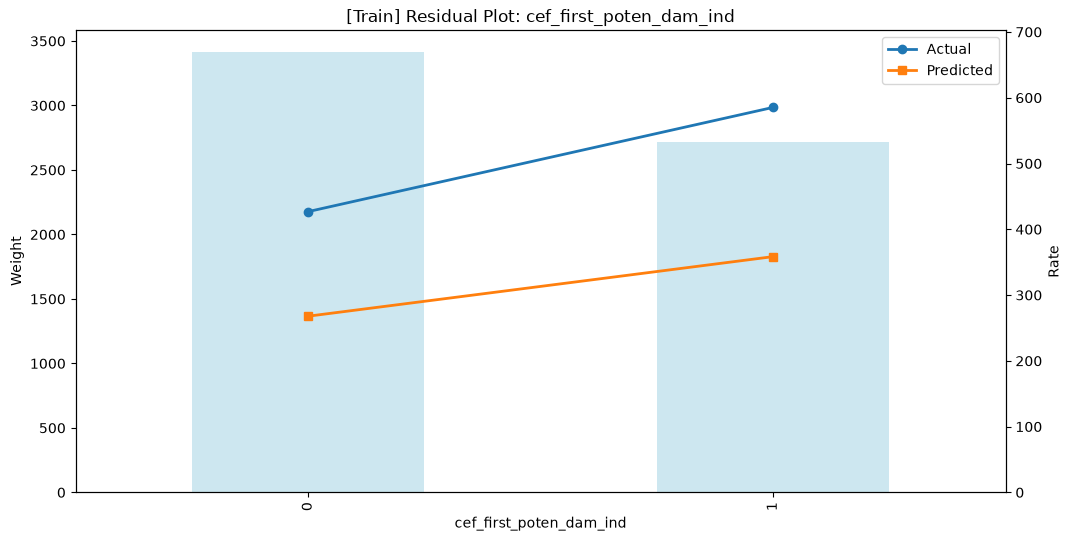

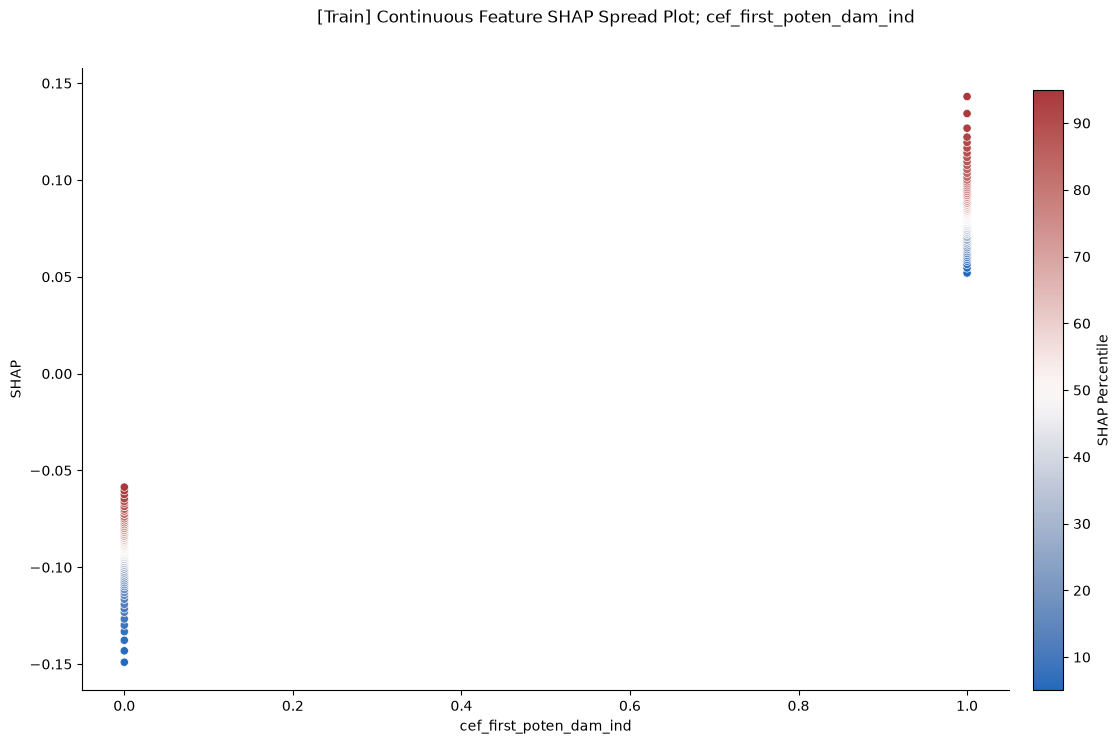

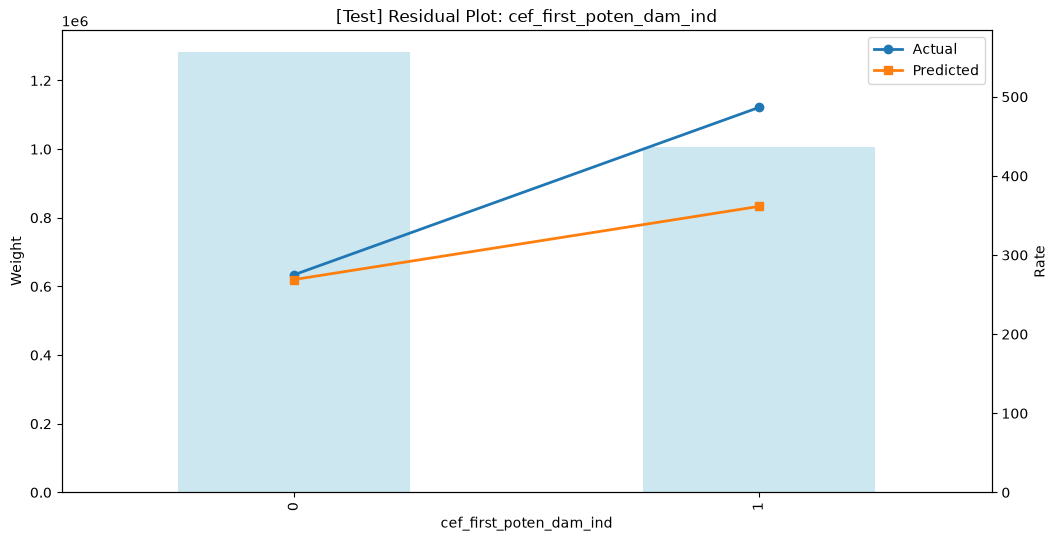

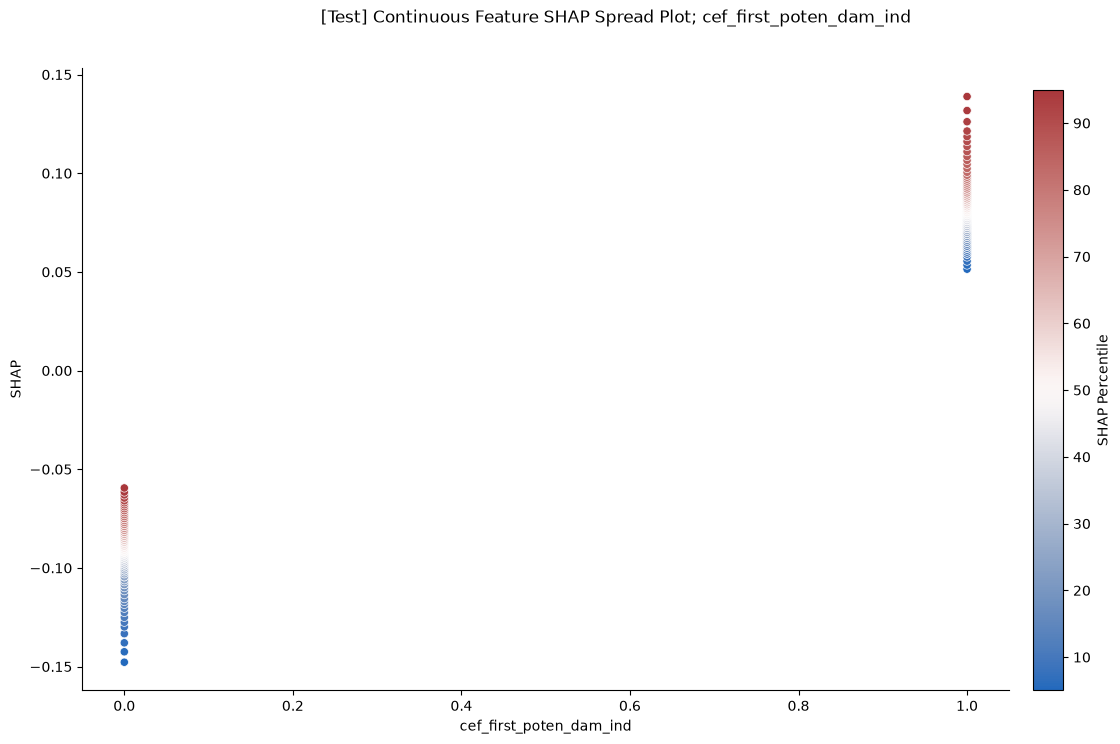


FEATURE: married_ind


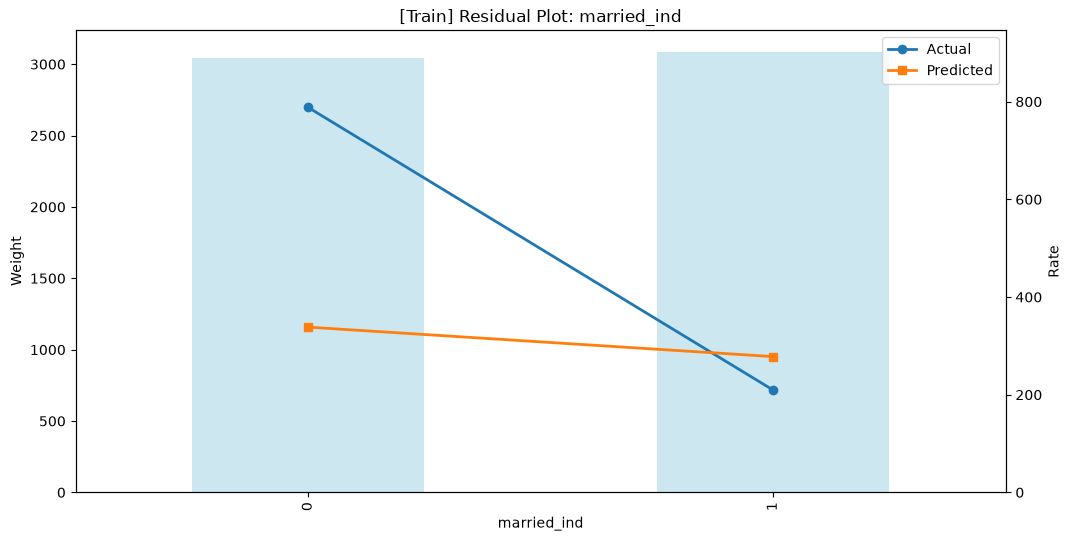

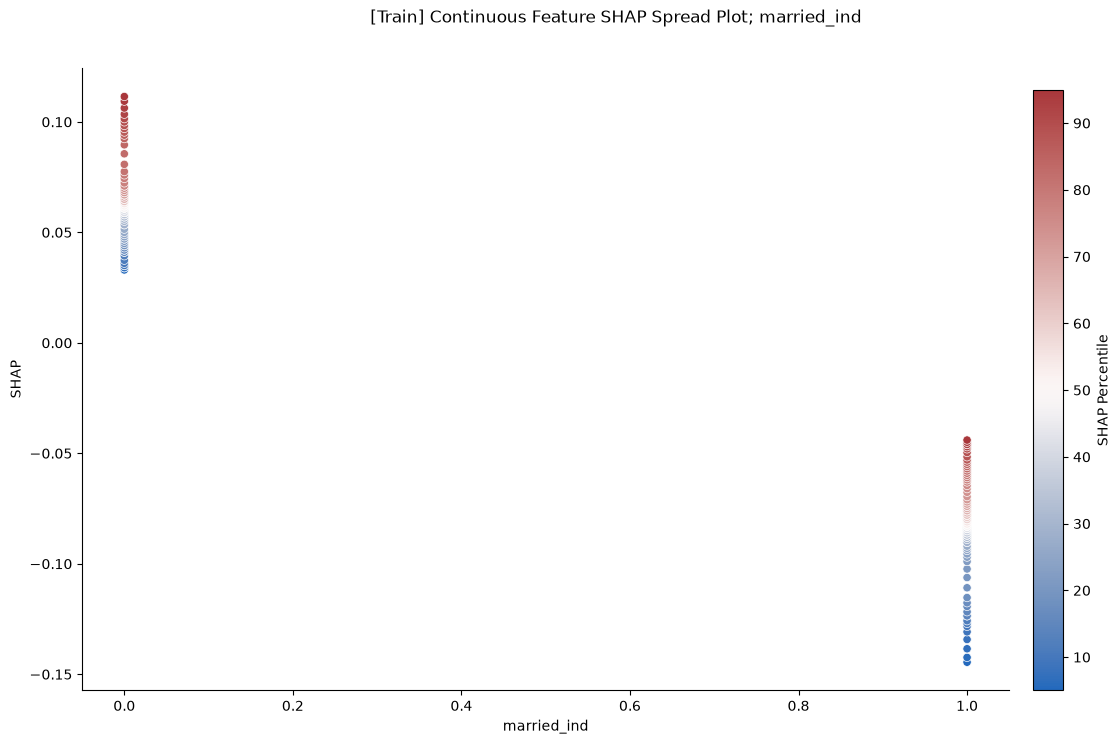

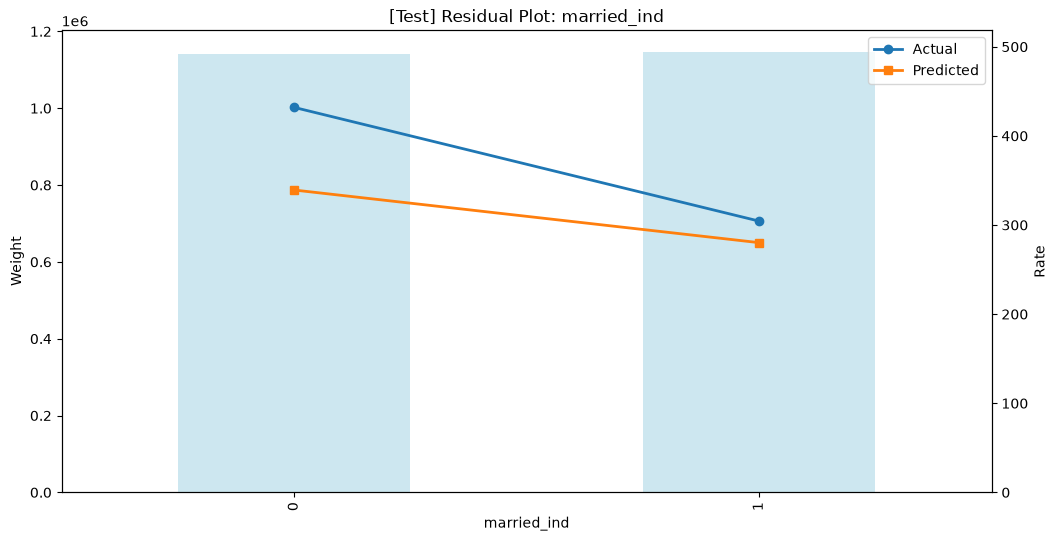

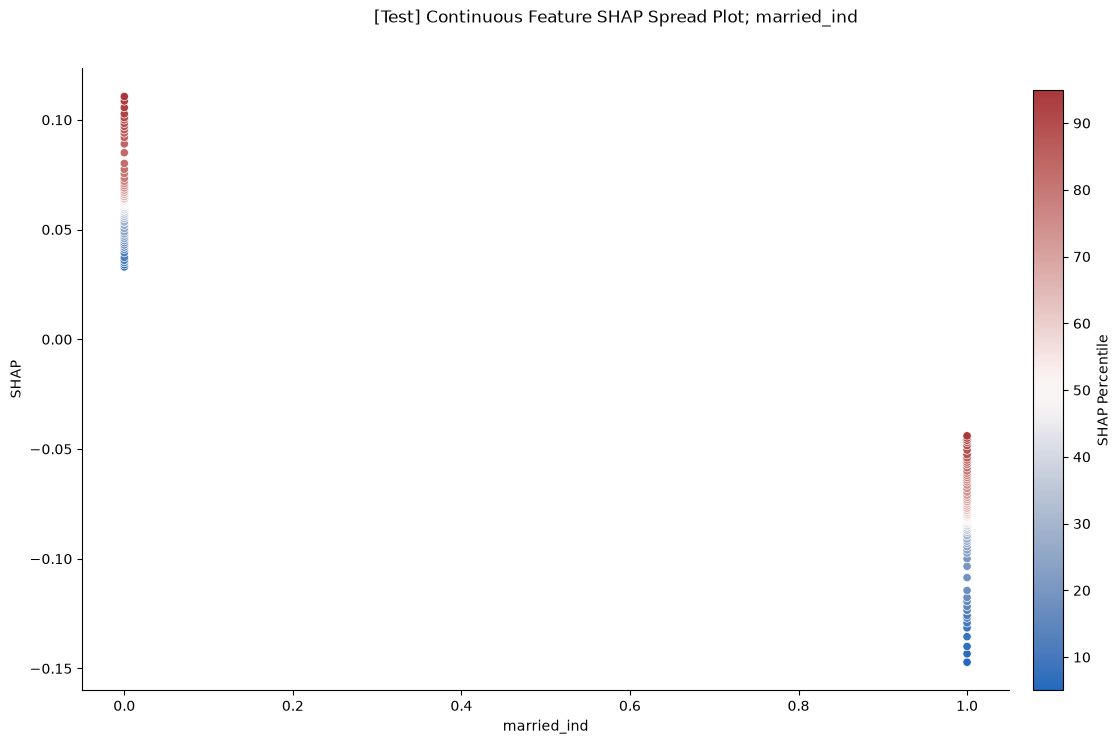


FEATURE: cef_lien_holder_ind


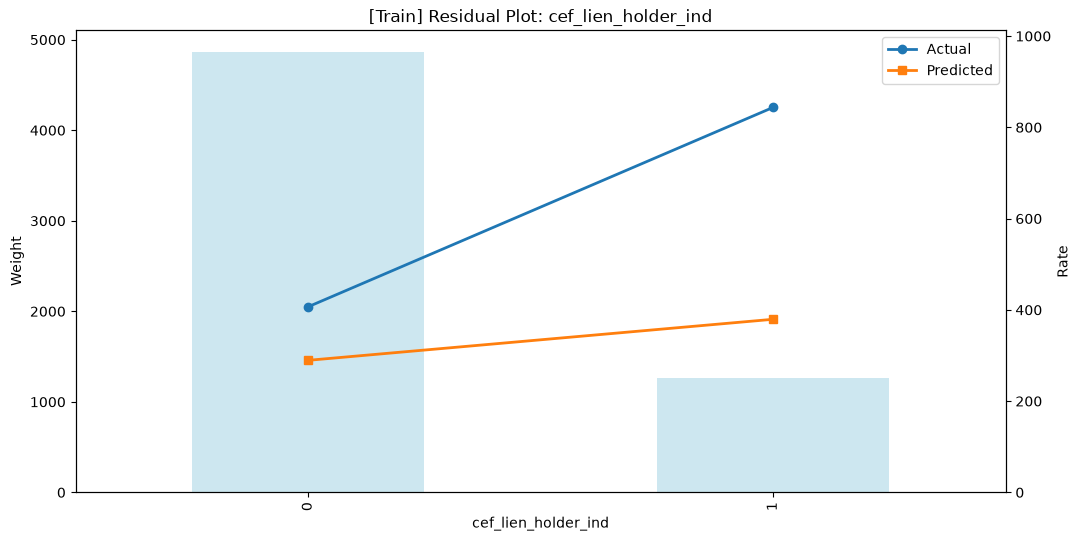

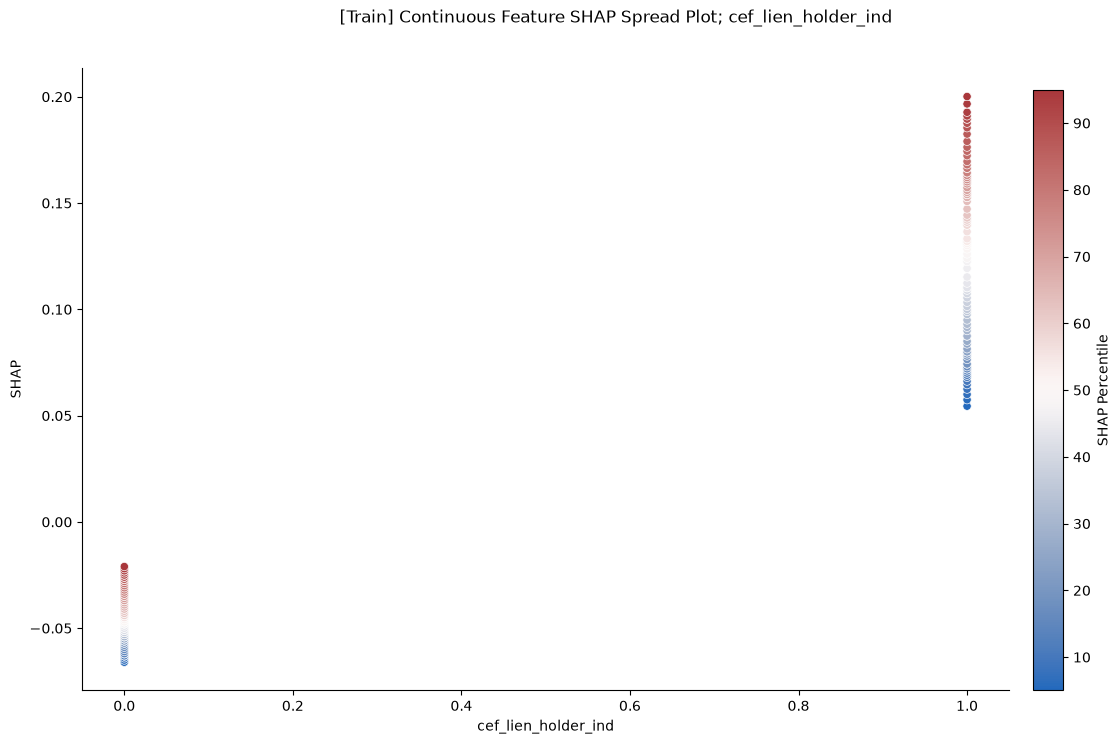

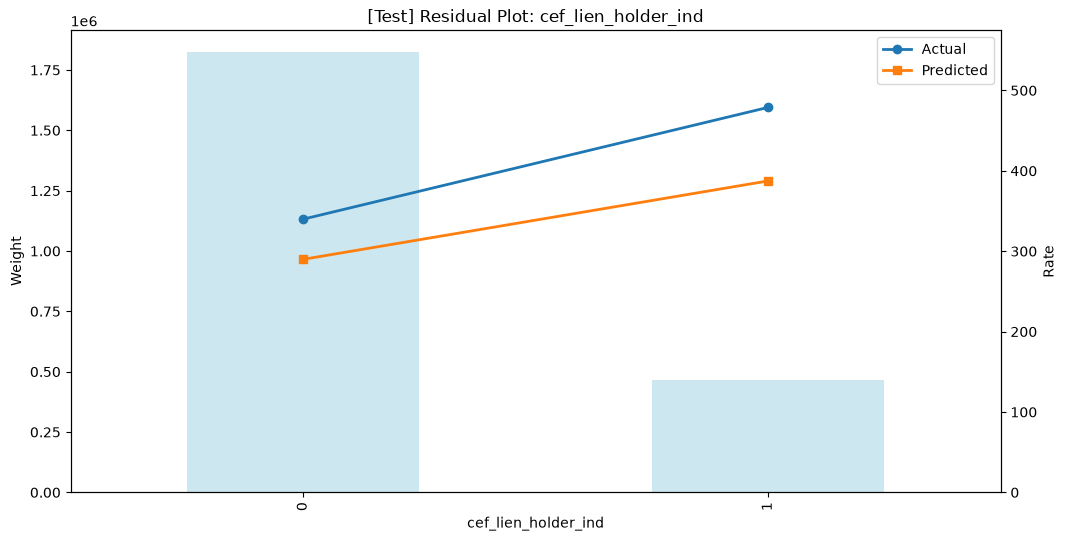

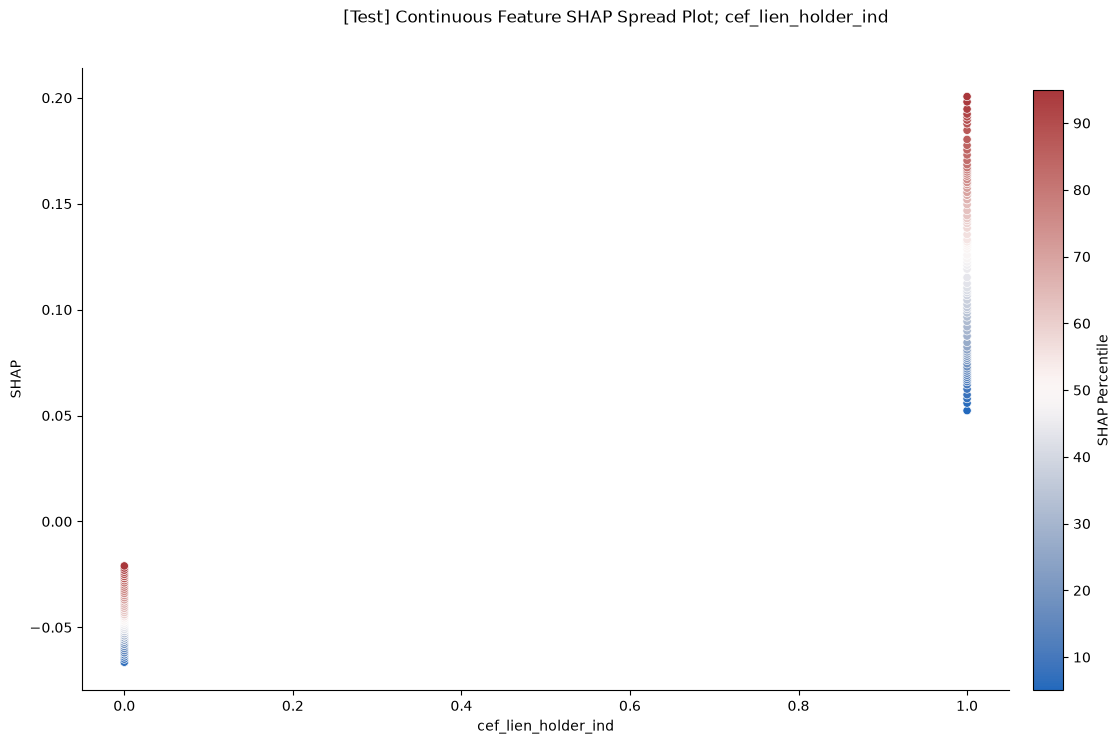


FEATURE: vc_premium_audio_raw


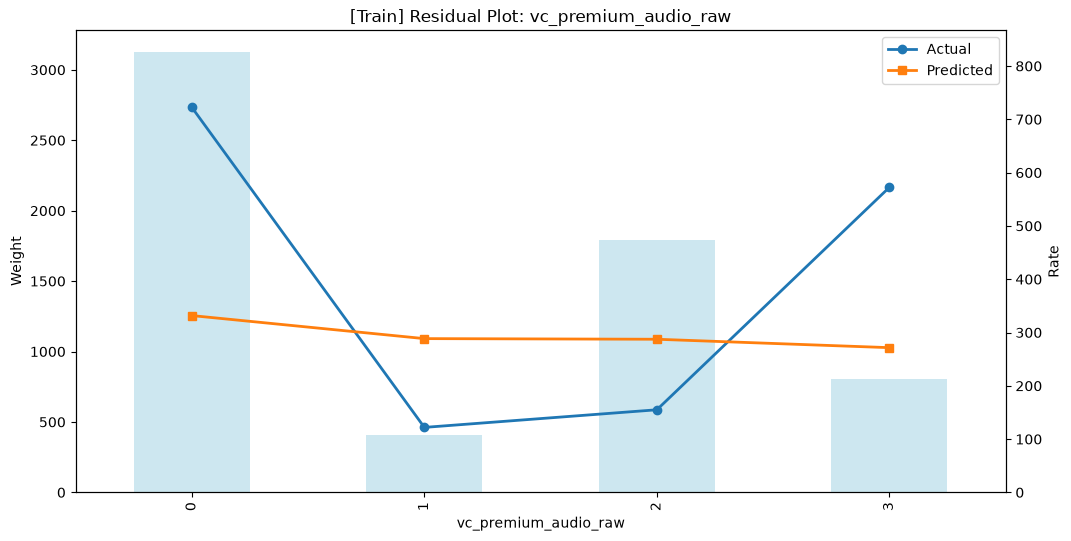

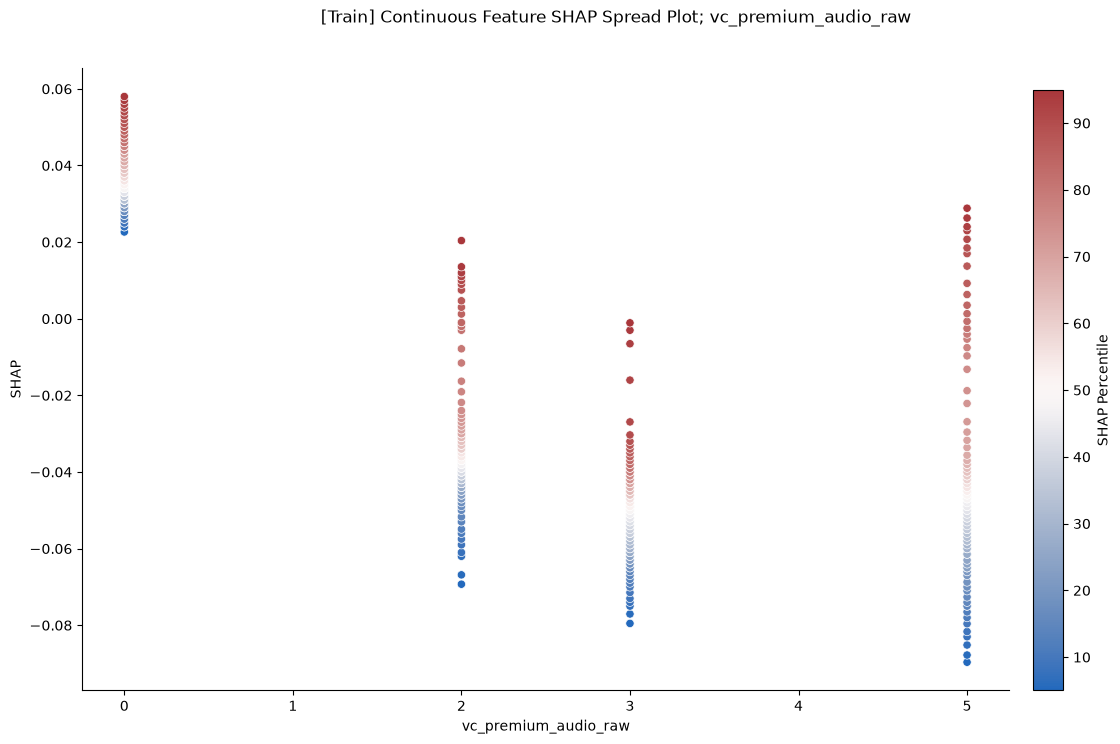

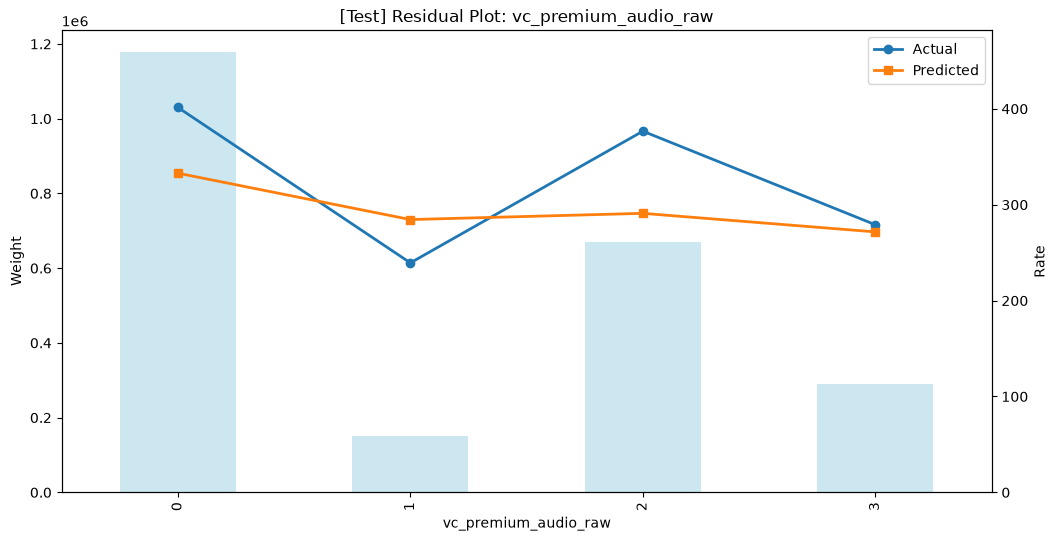

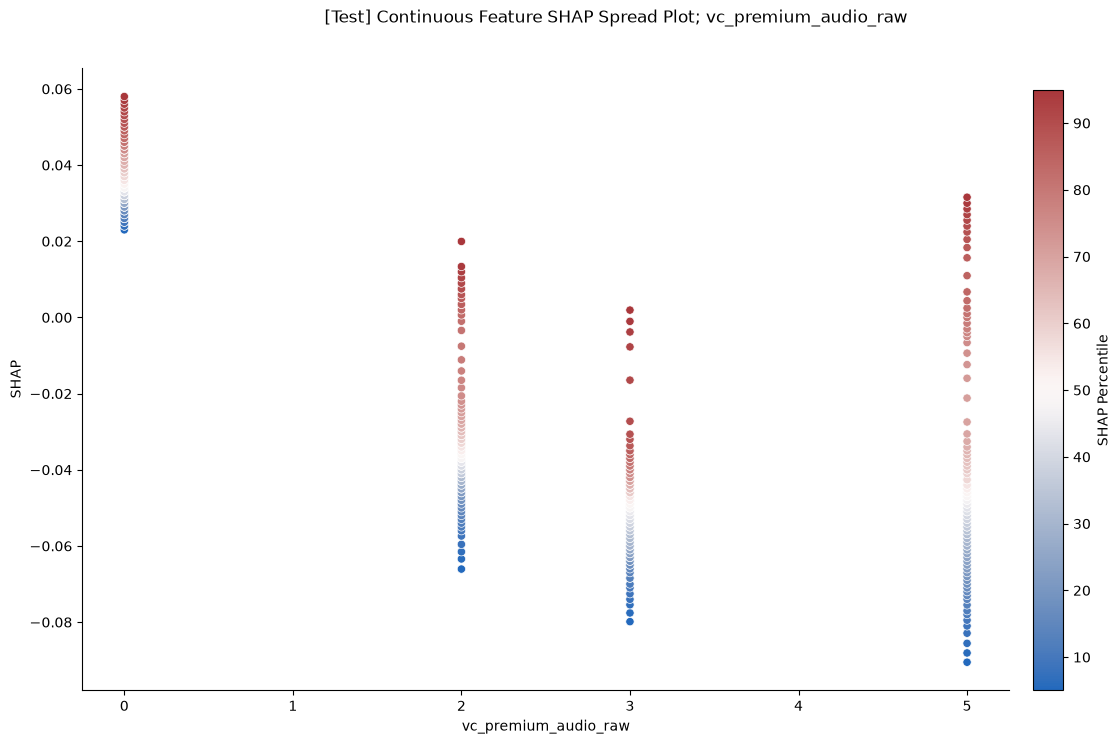


FEATURE: vc_doors_raw


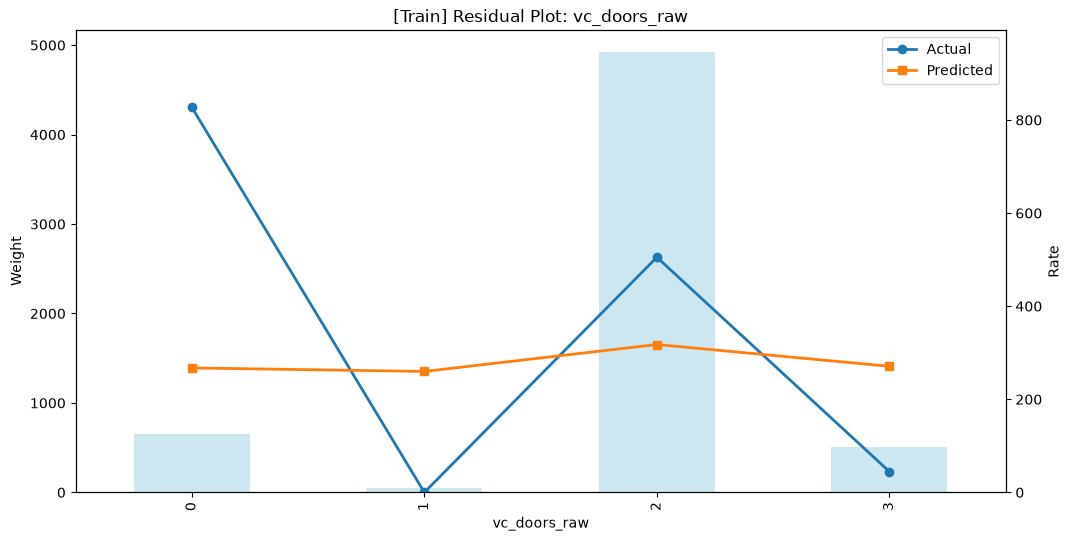

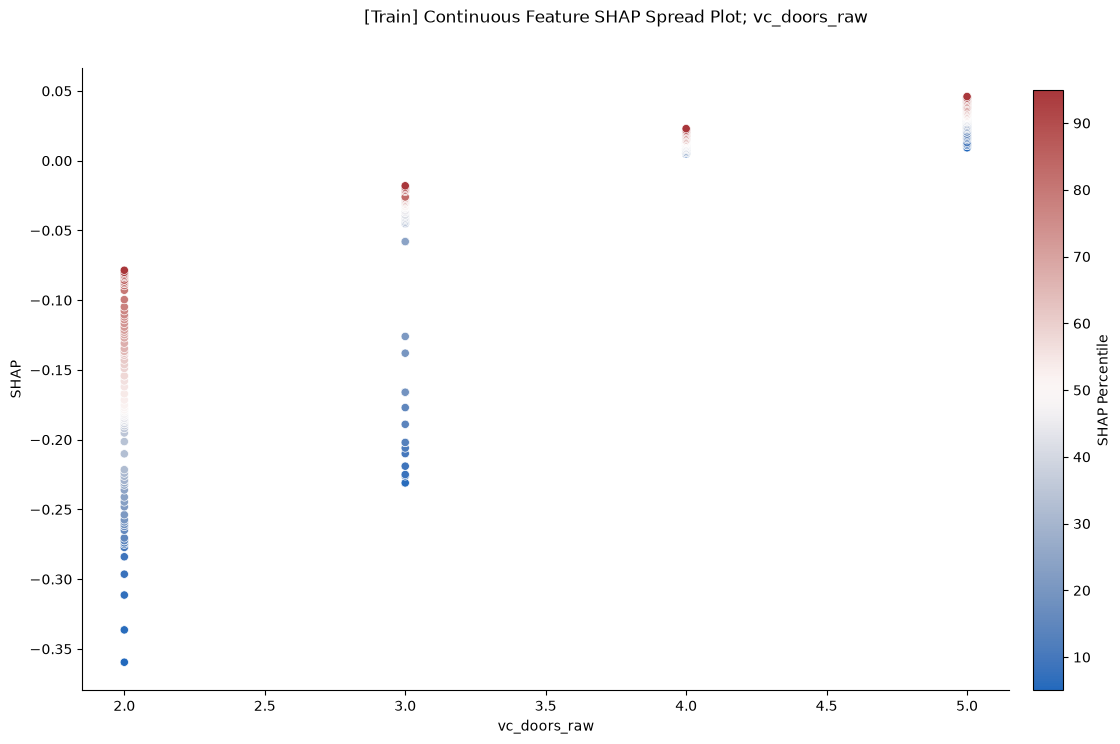

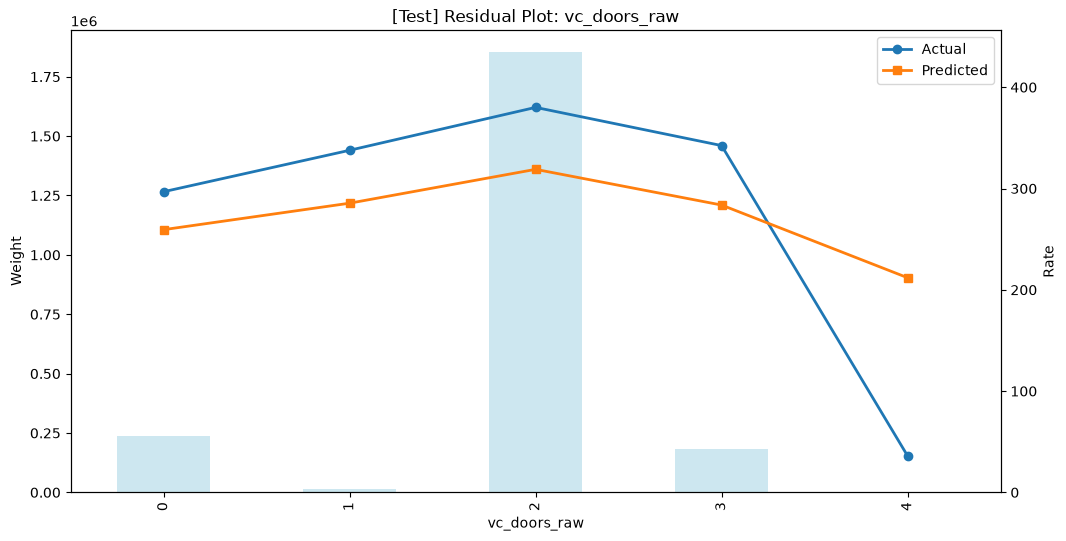

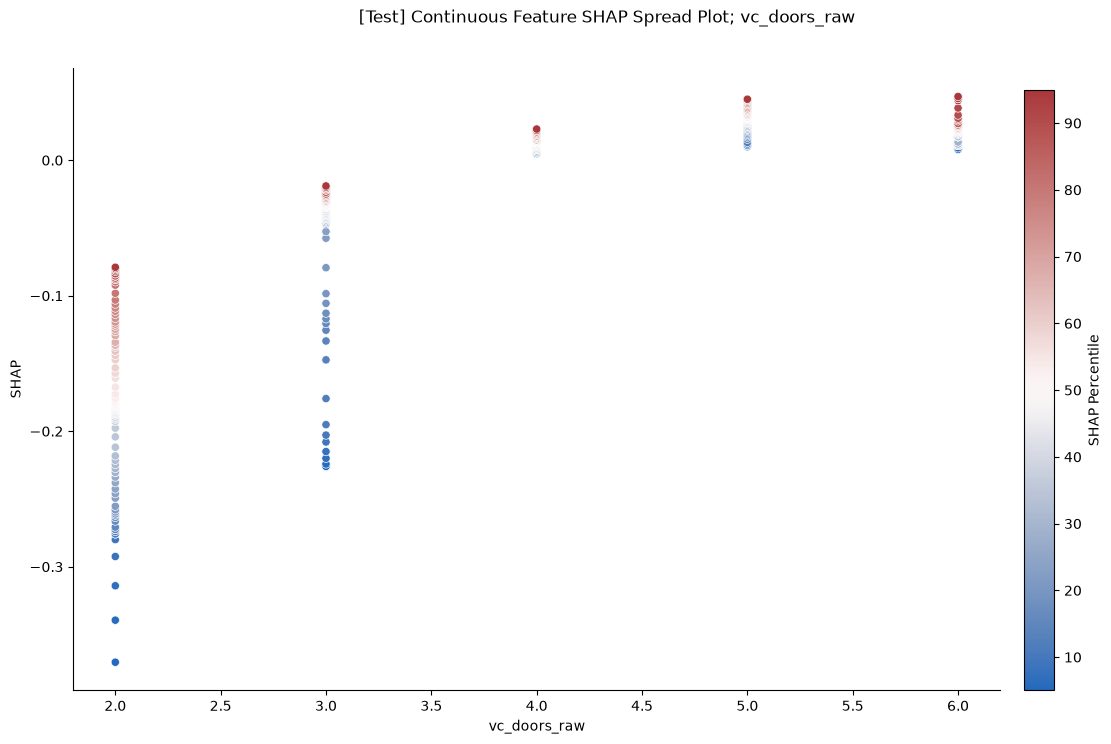


FEATURE: vc_rear_wiper_raw


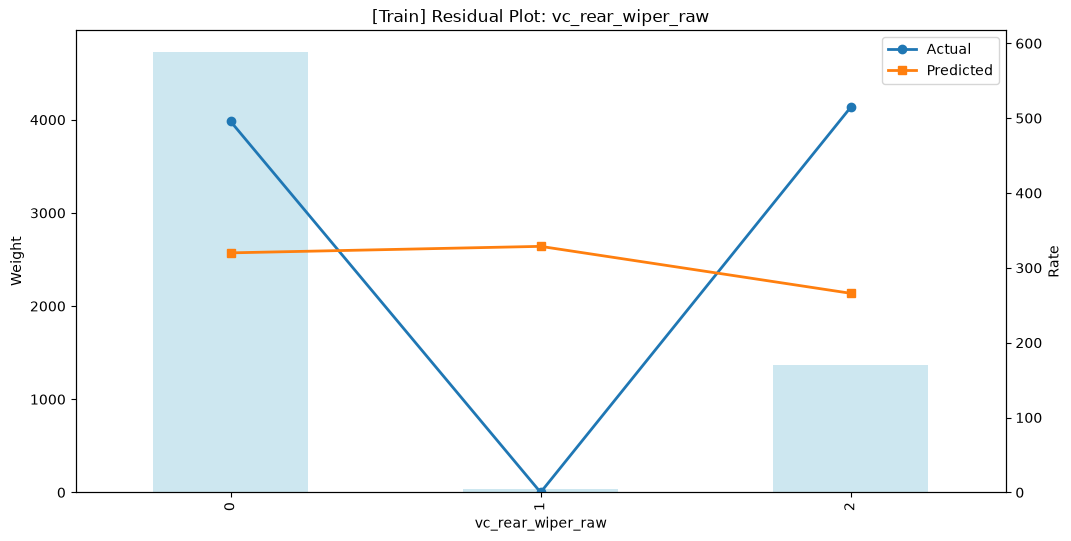

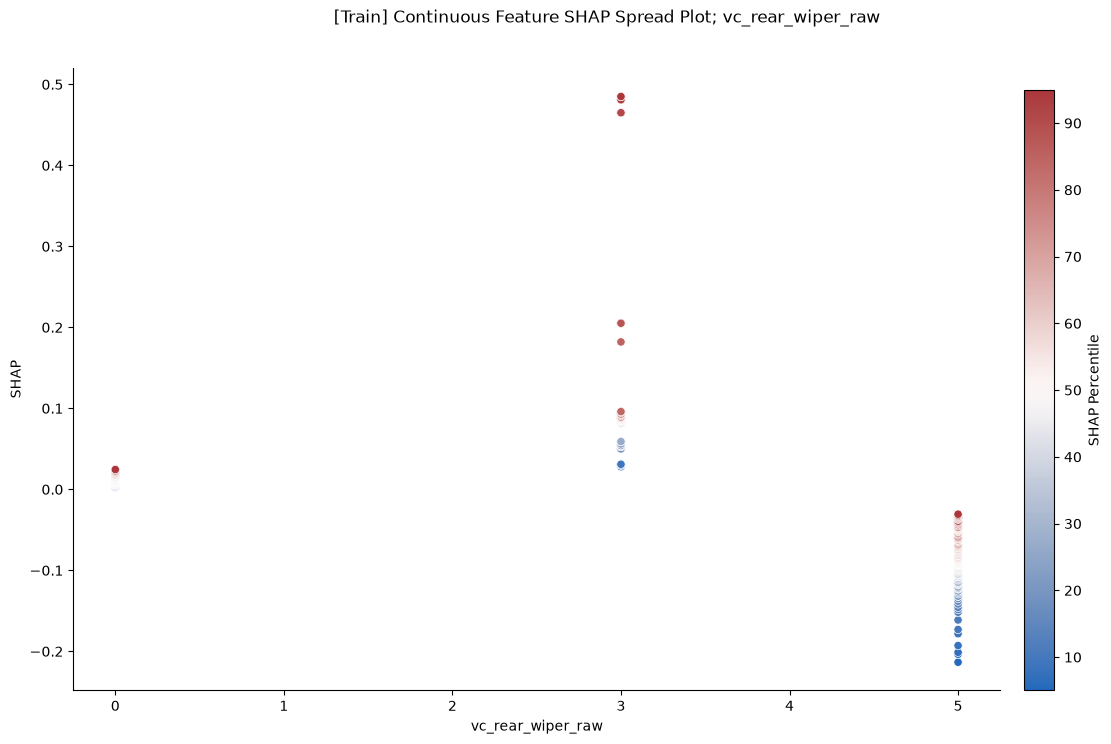

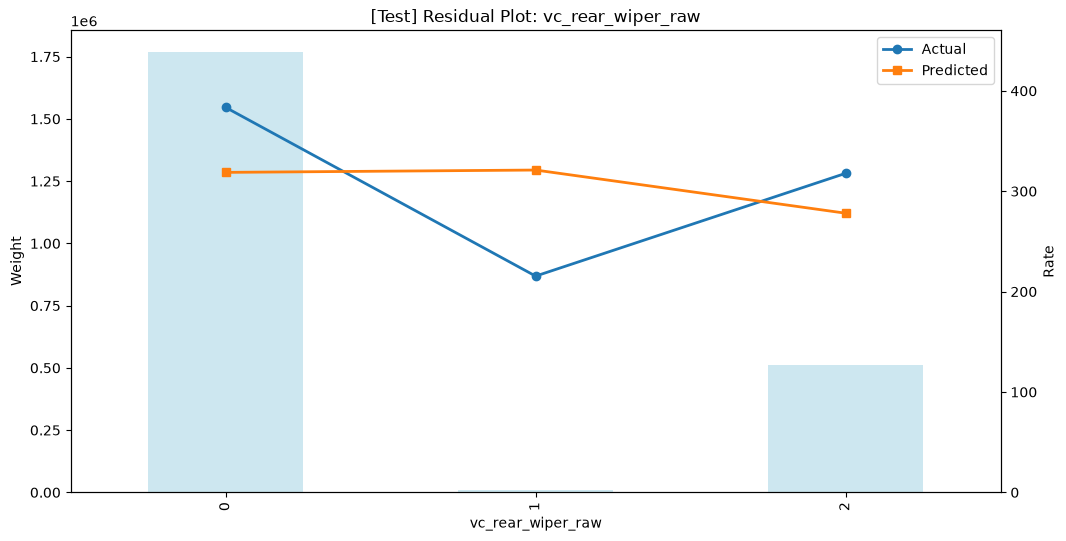

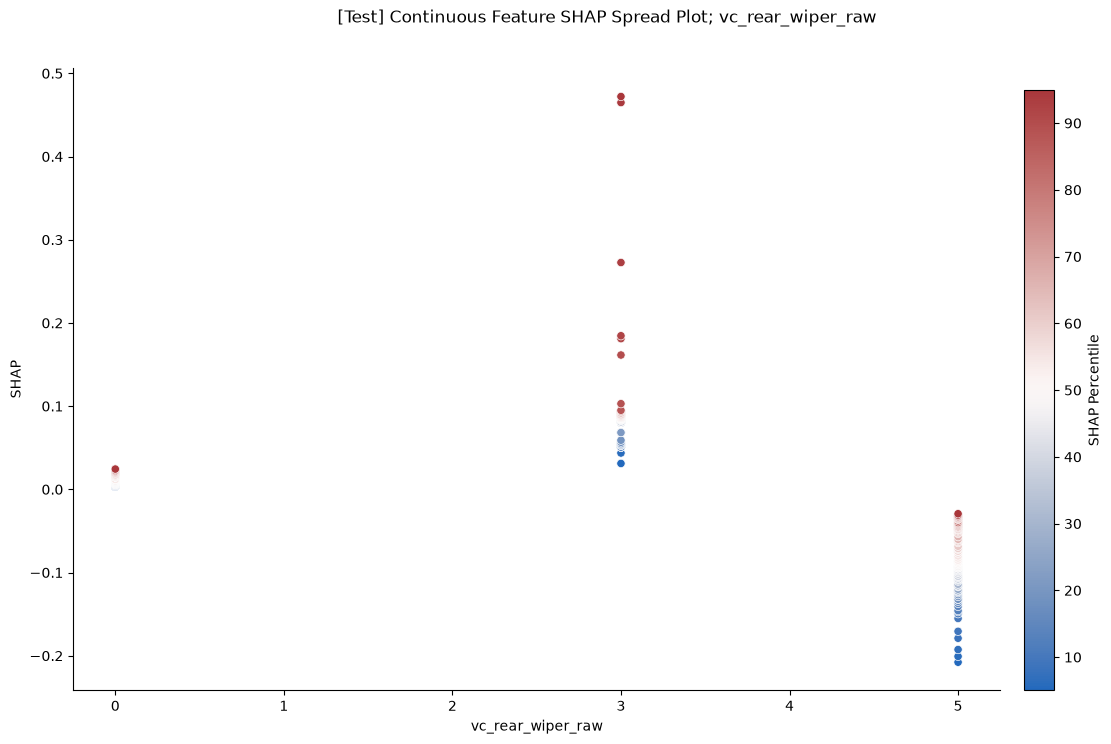


FEATURE: vc_heated_side_mirrors_raw


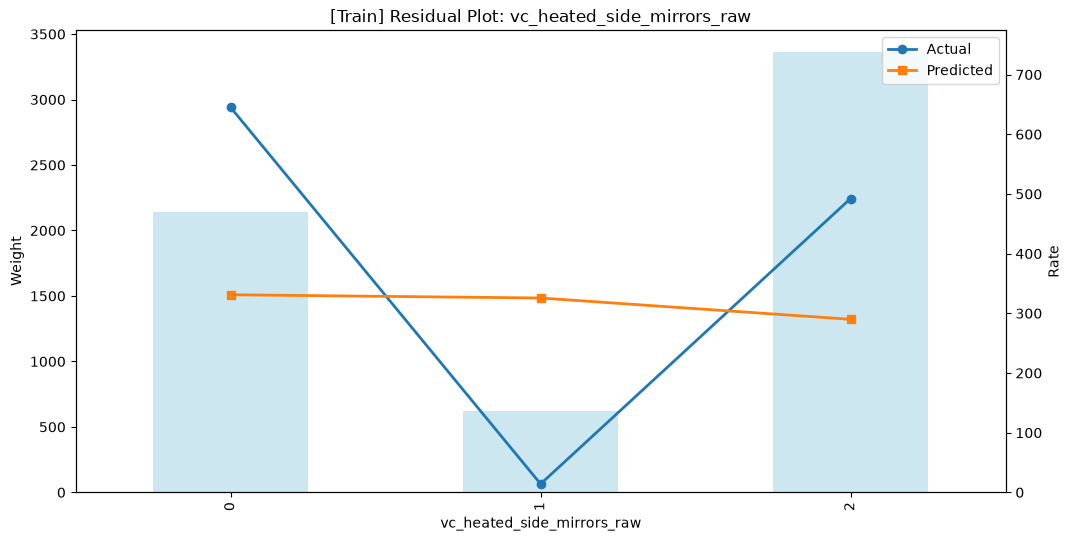

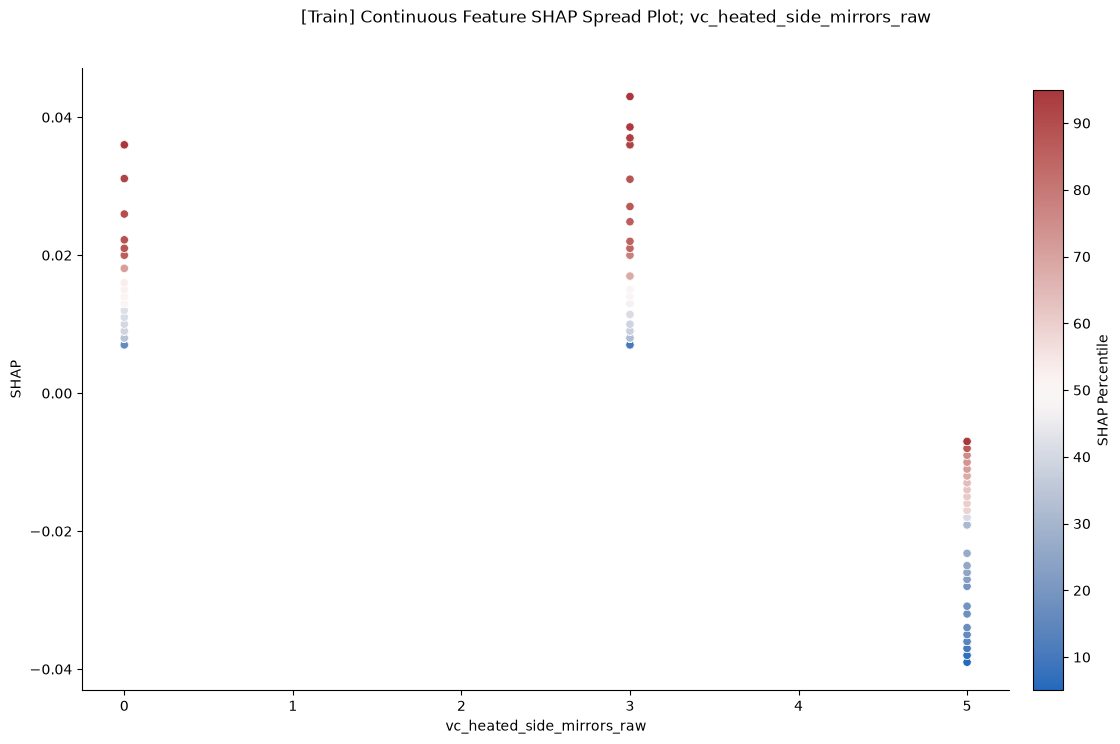

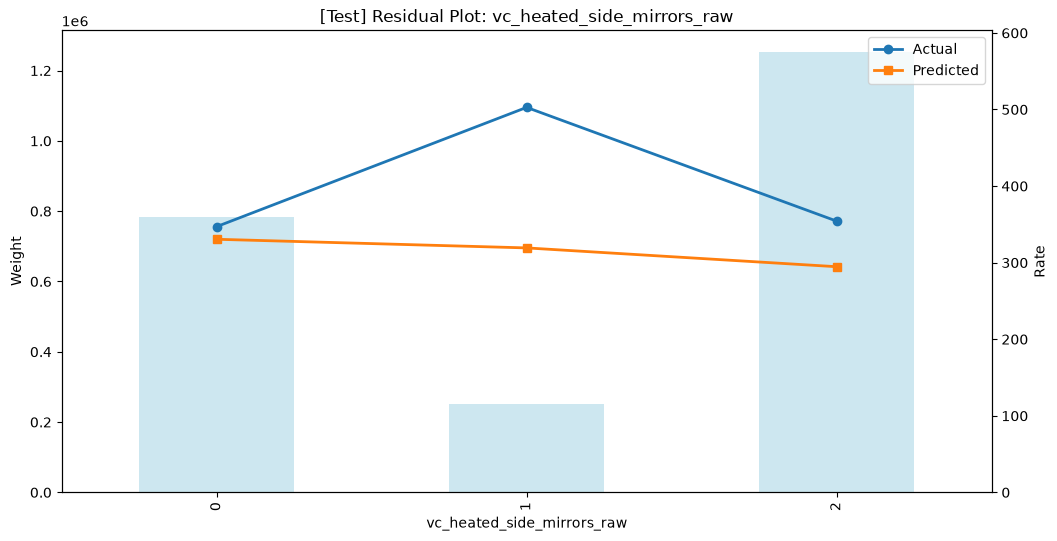

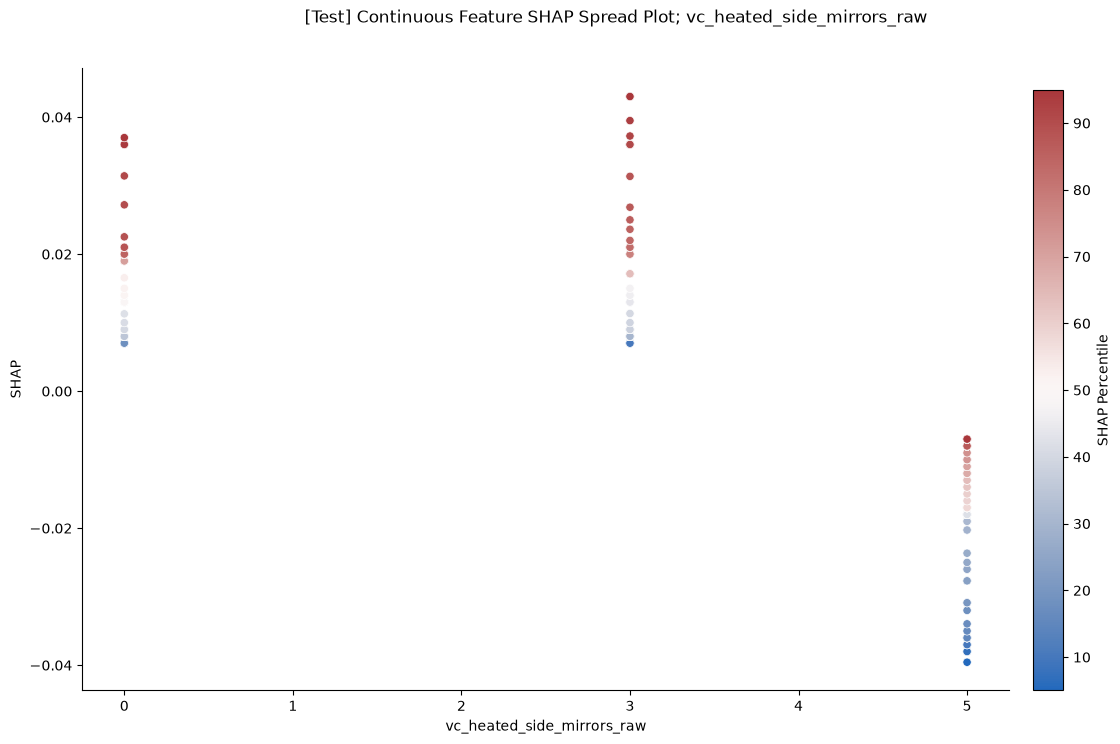


FEATURE: vc_speed_sensitive_volume_raw


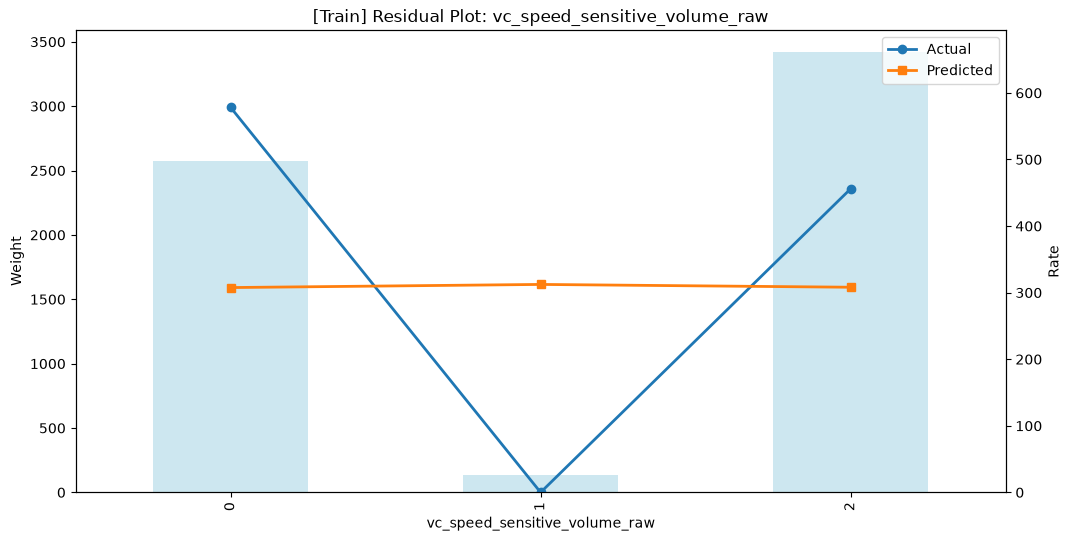

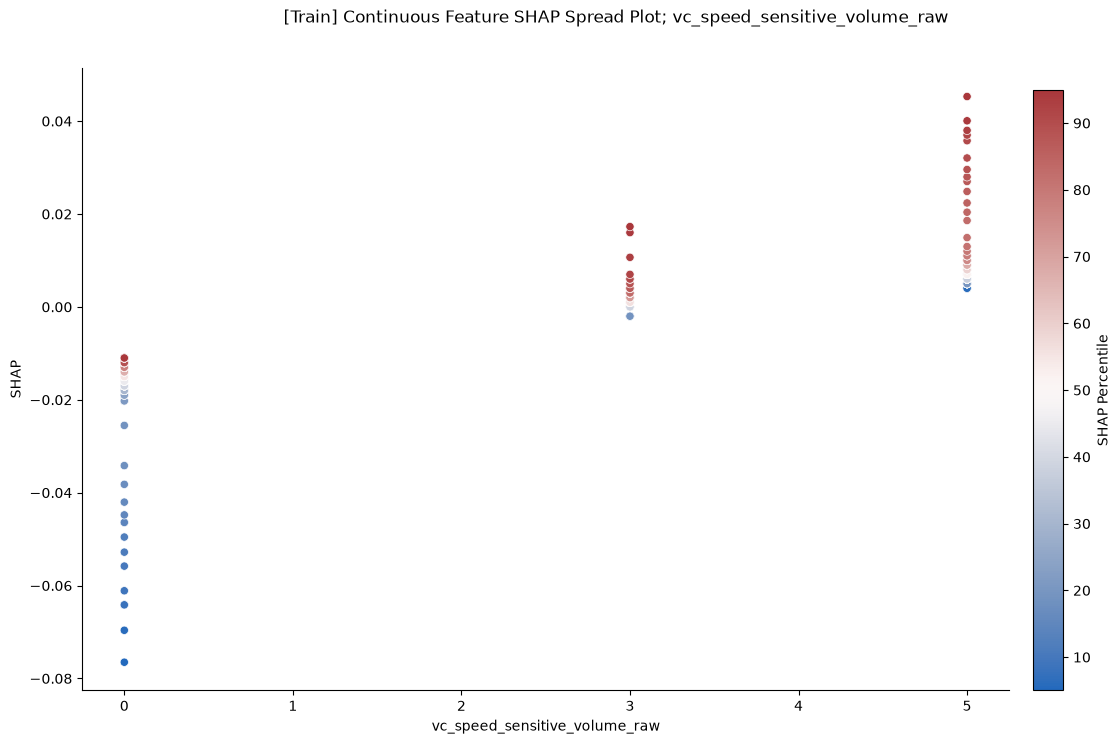

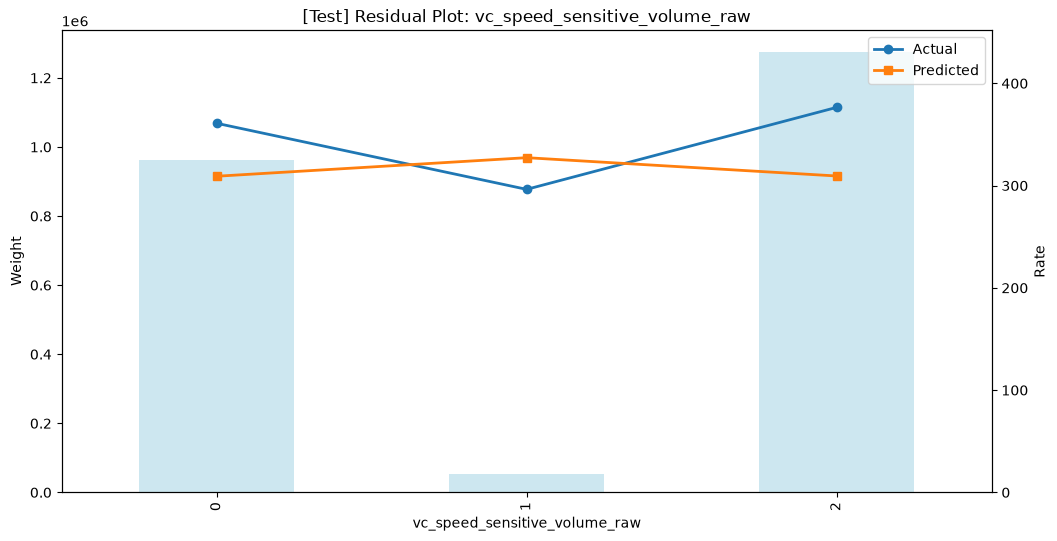

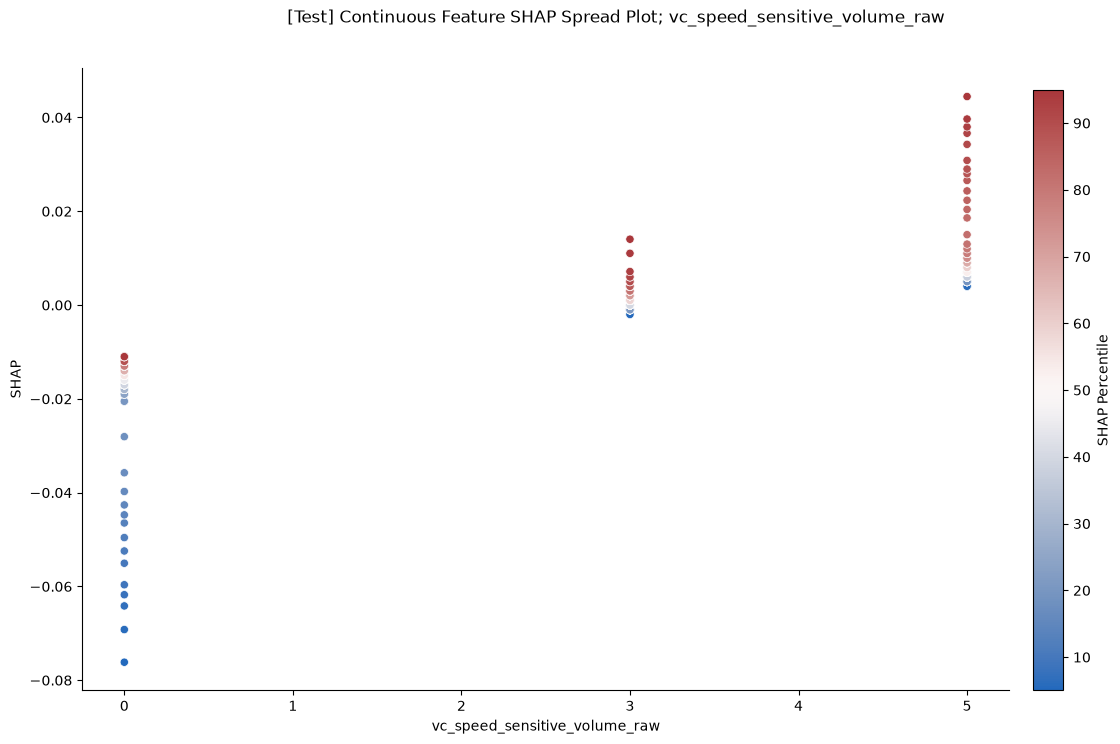


FEATURE: vc_auto_dimming_side_mirrors_raw


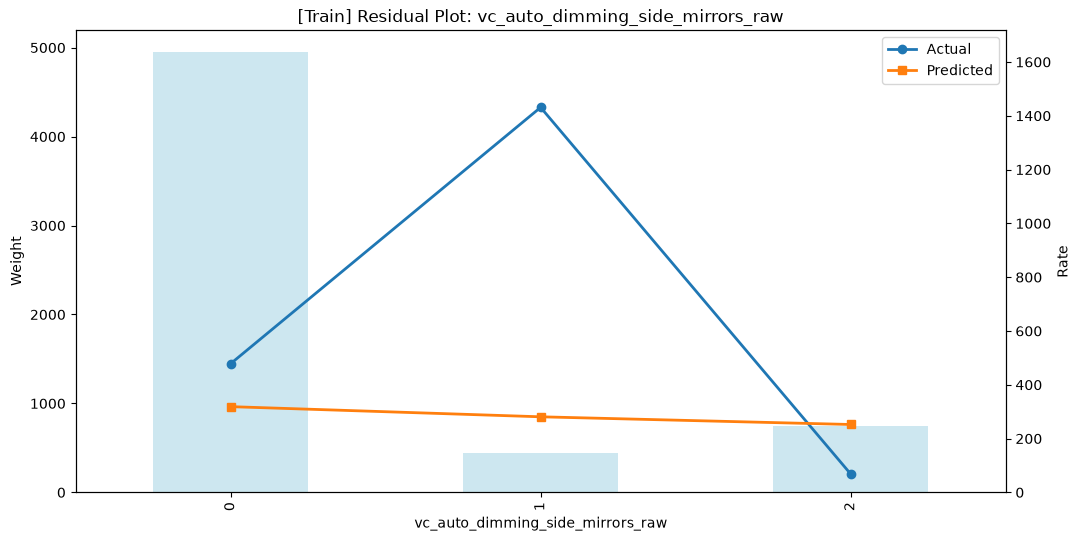

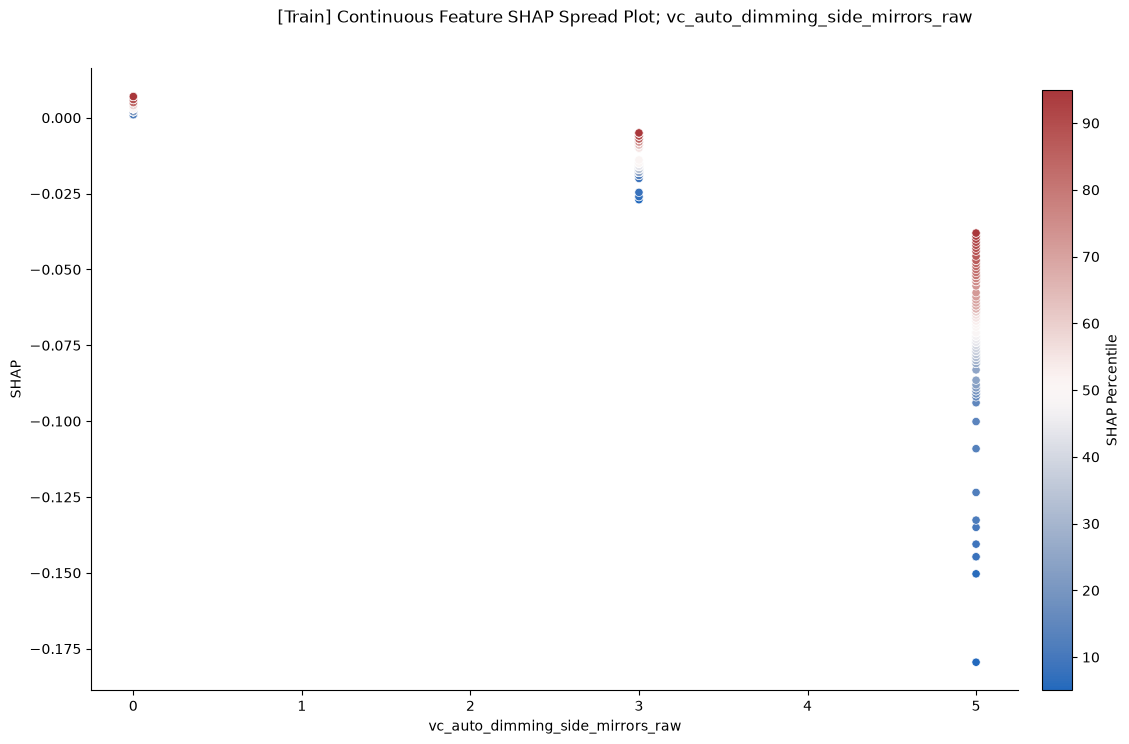

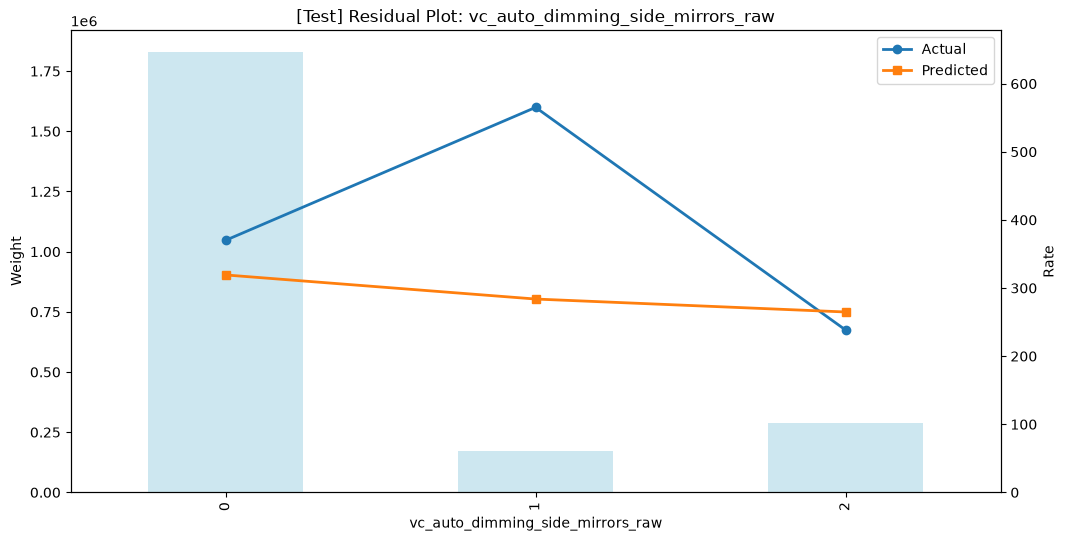

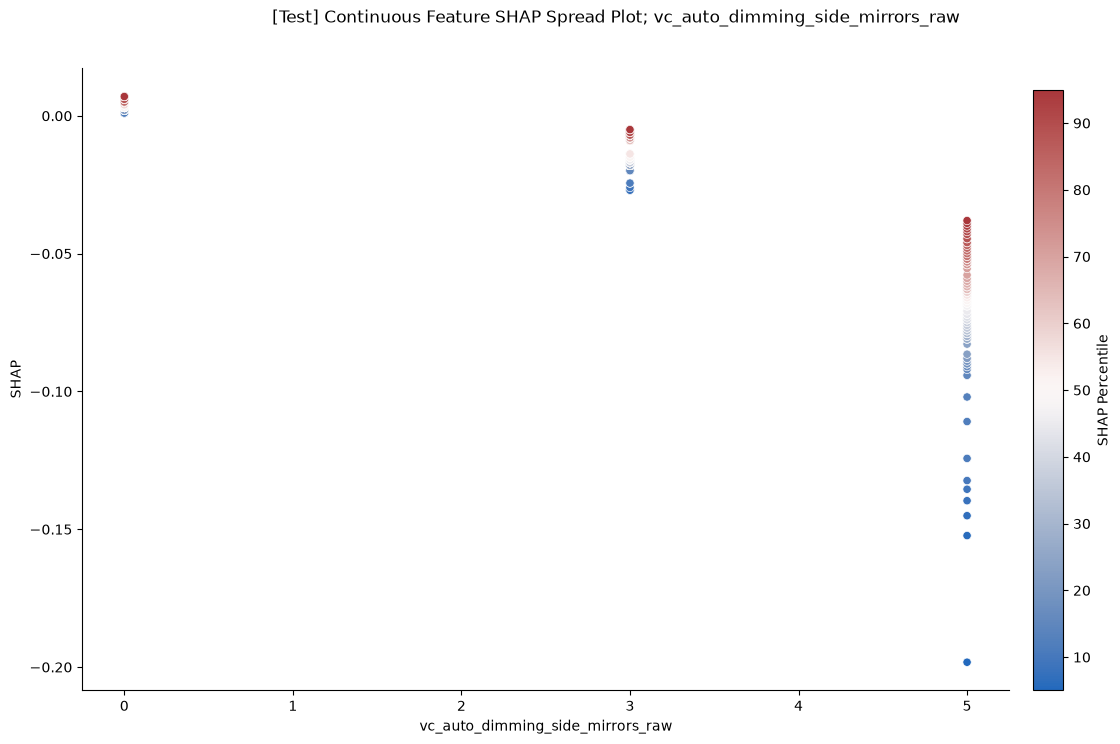


FEATURE: vc_transmission_type_automatic_ind


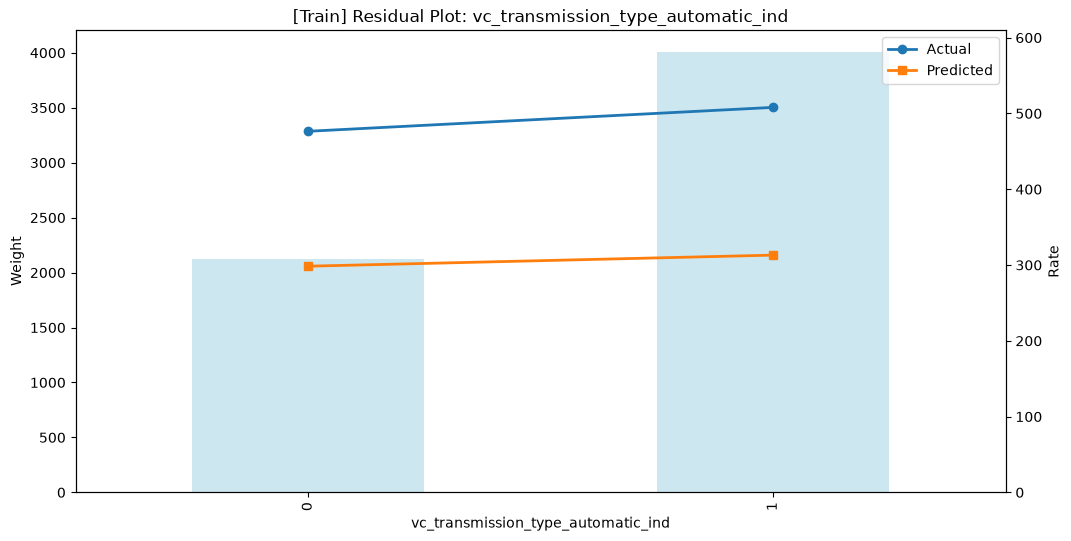

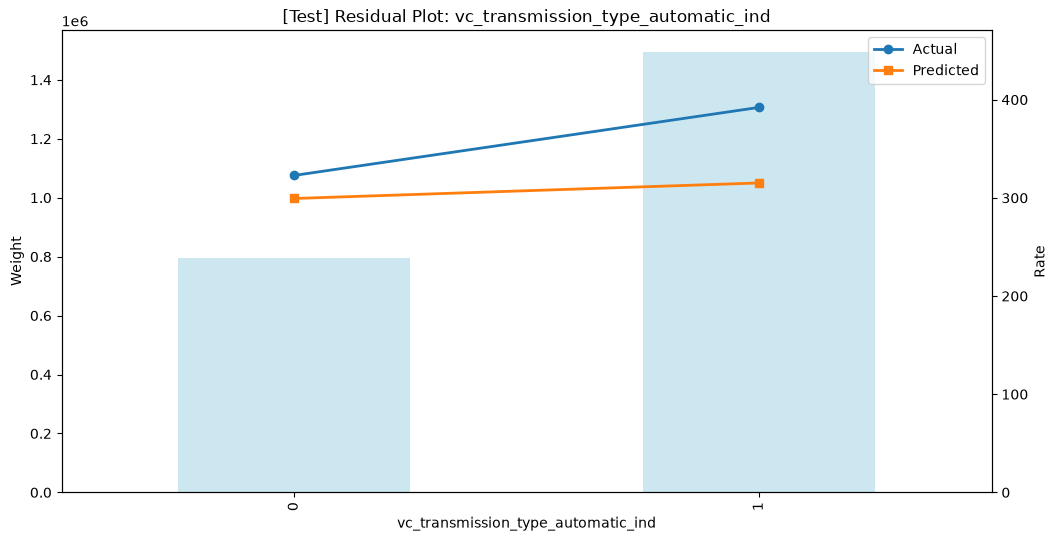

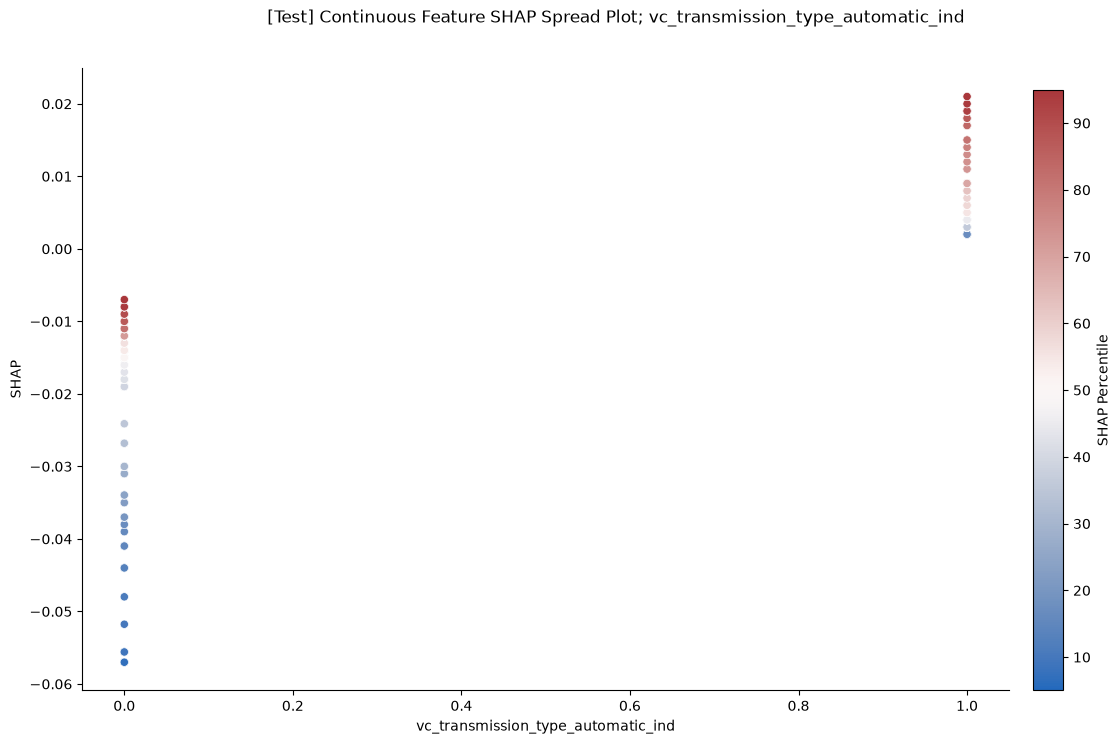


FEATURE: vc_tinted_windows_raw


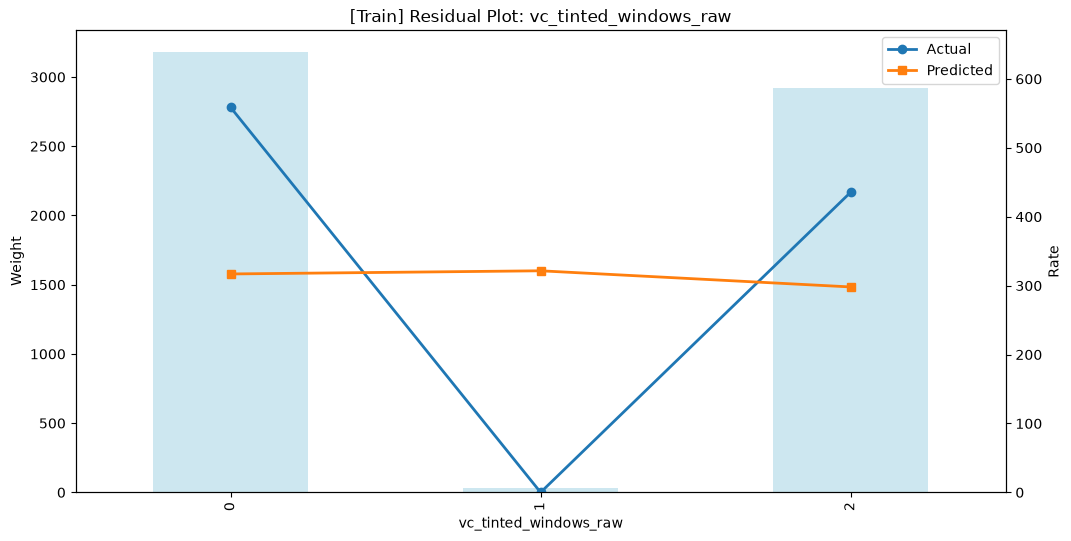

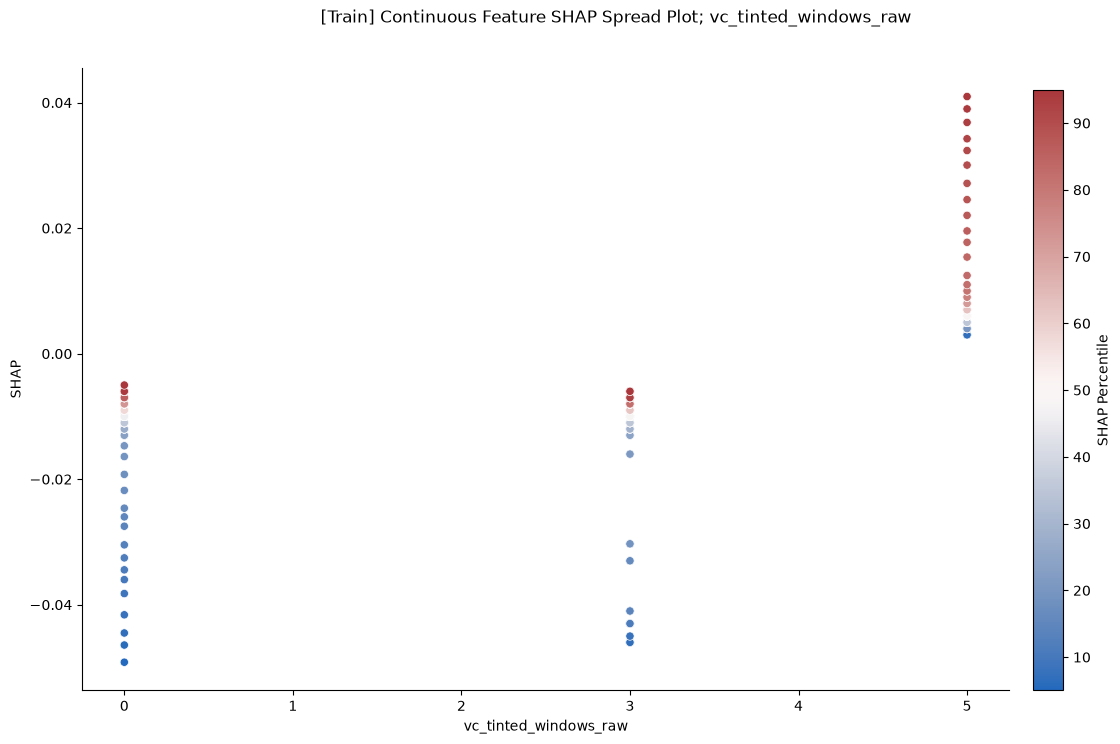

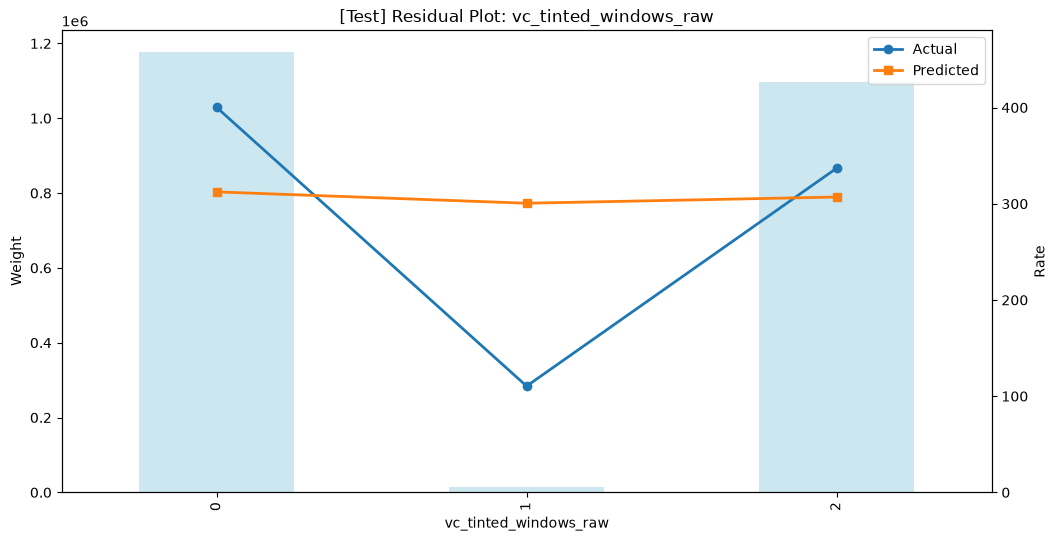

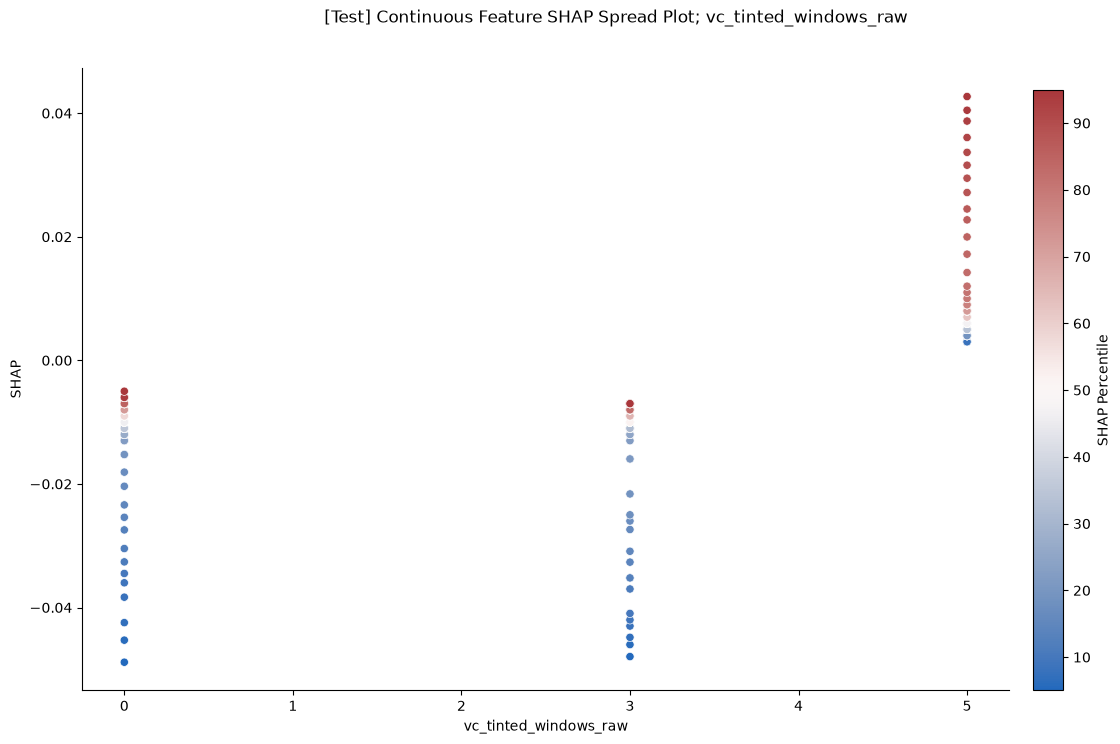


FEATURE: vc_backup_camera_raw


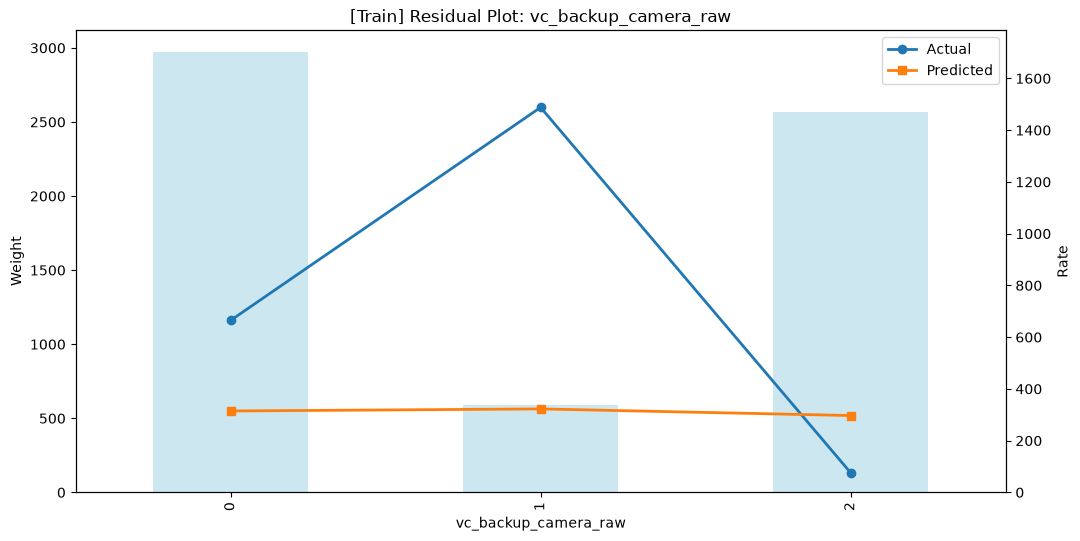

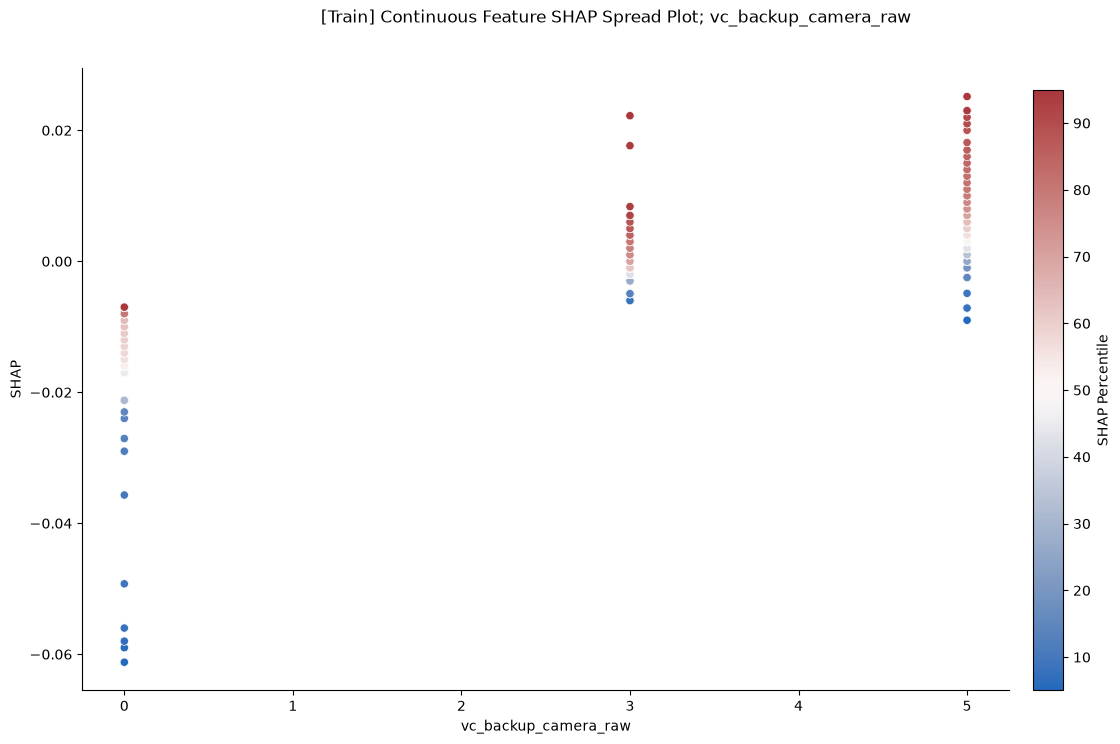

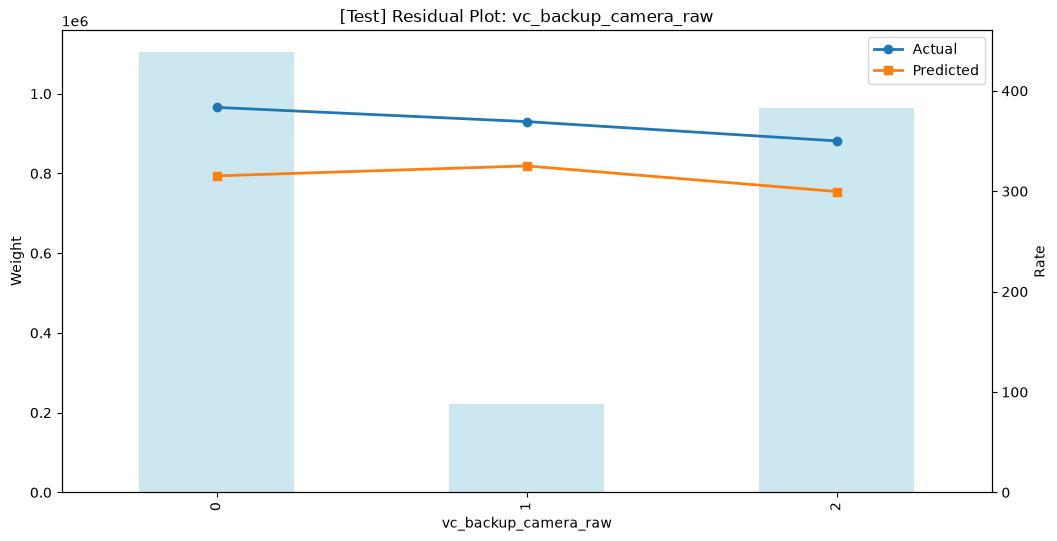

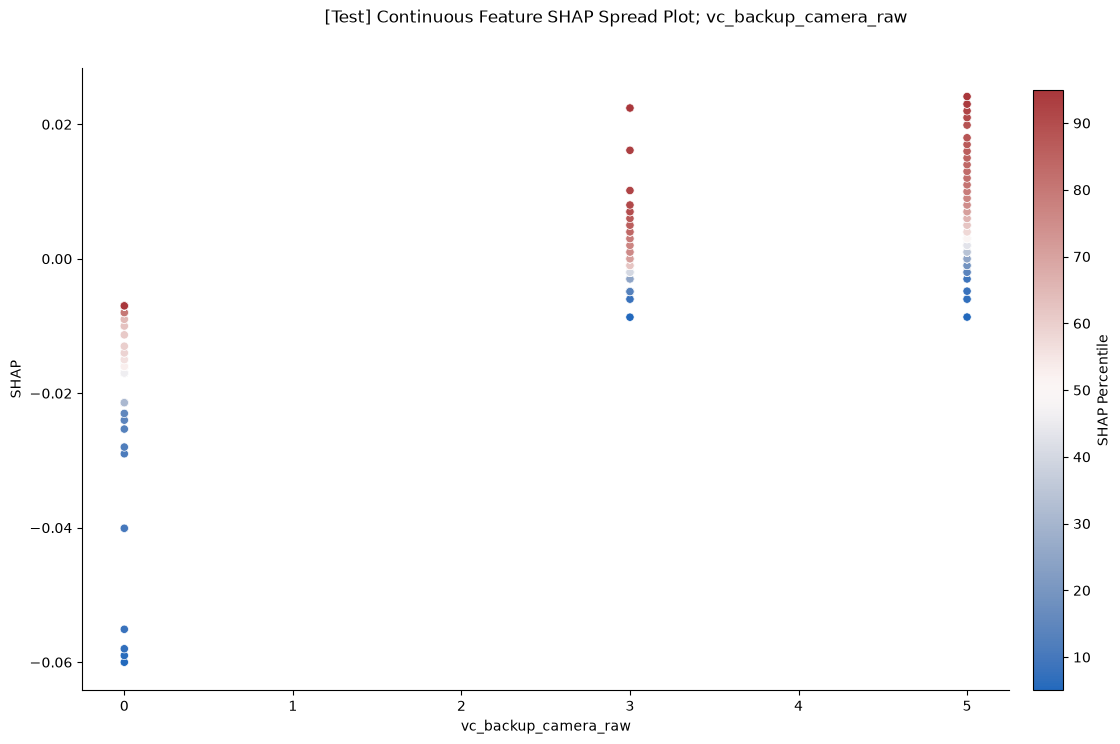


FEATURE: vc_transmission_type_manual_ind


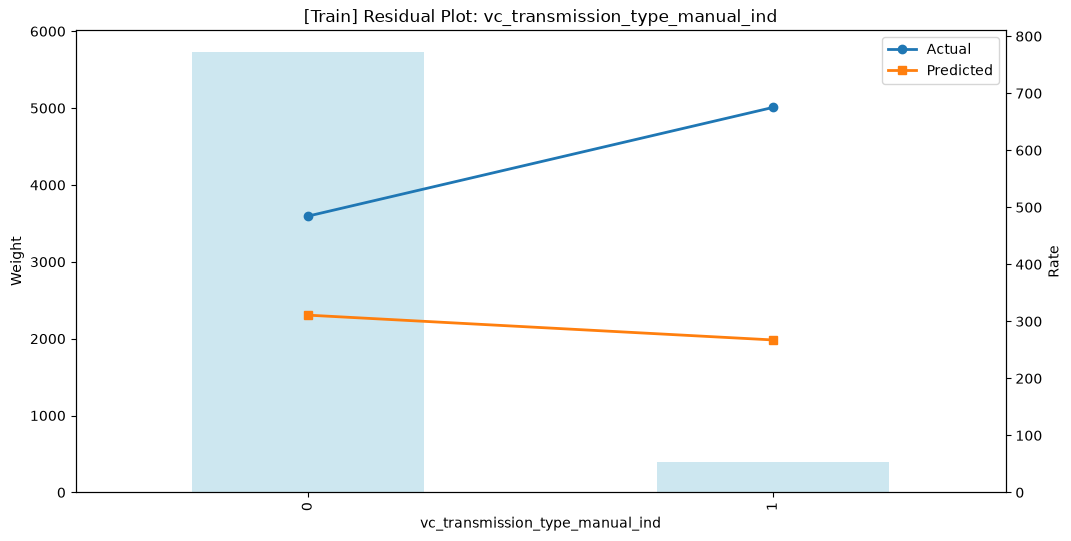

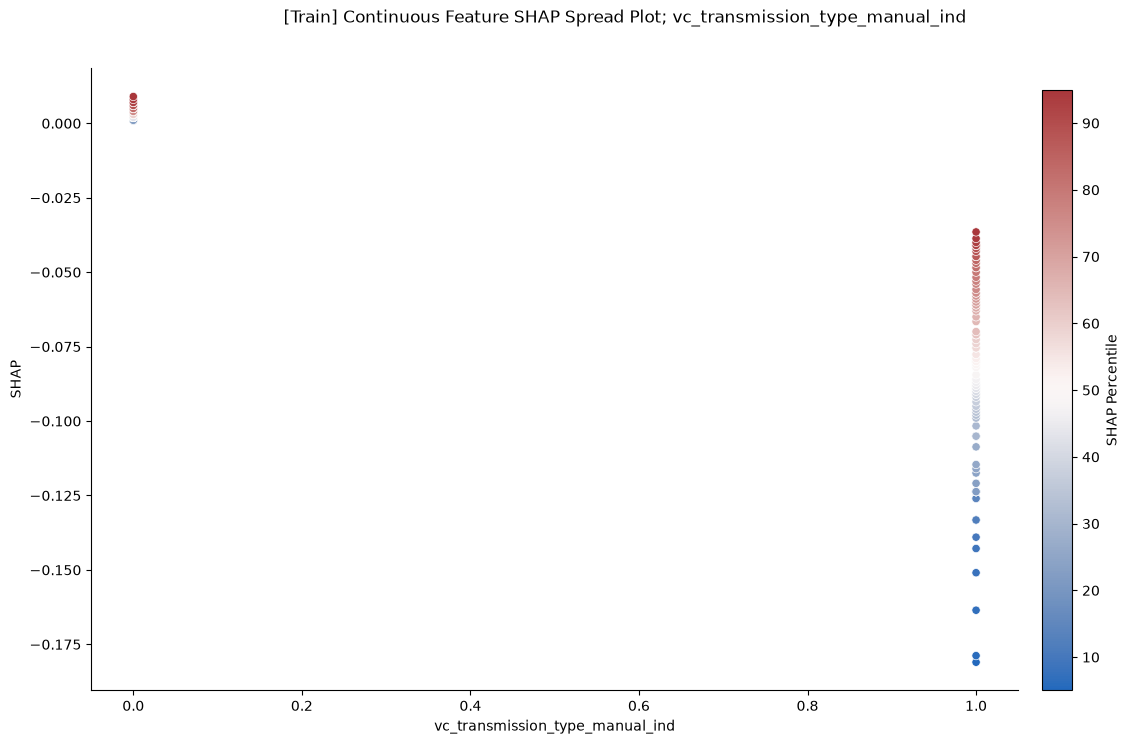

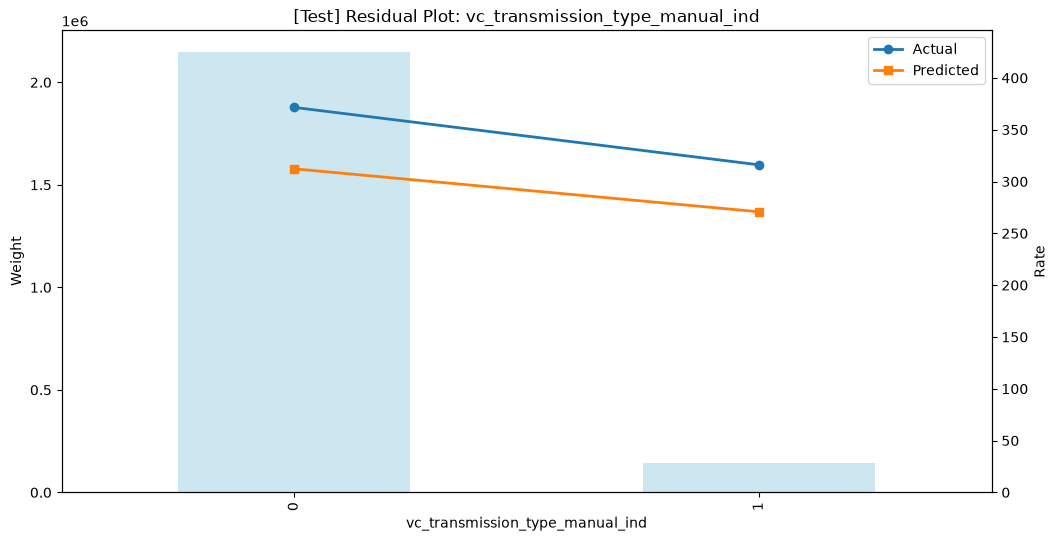

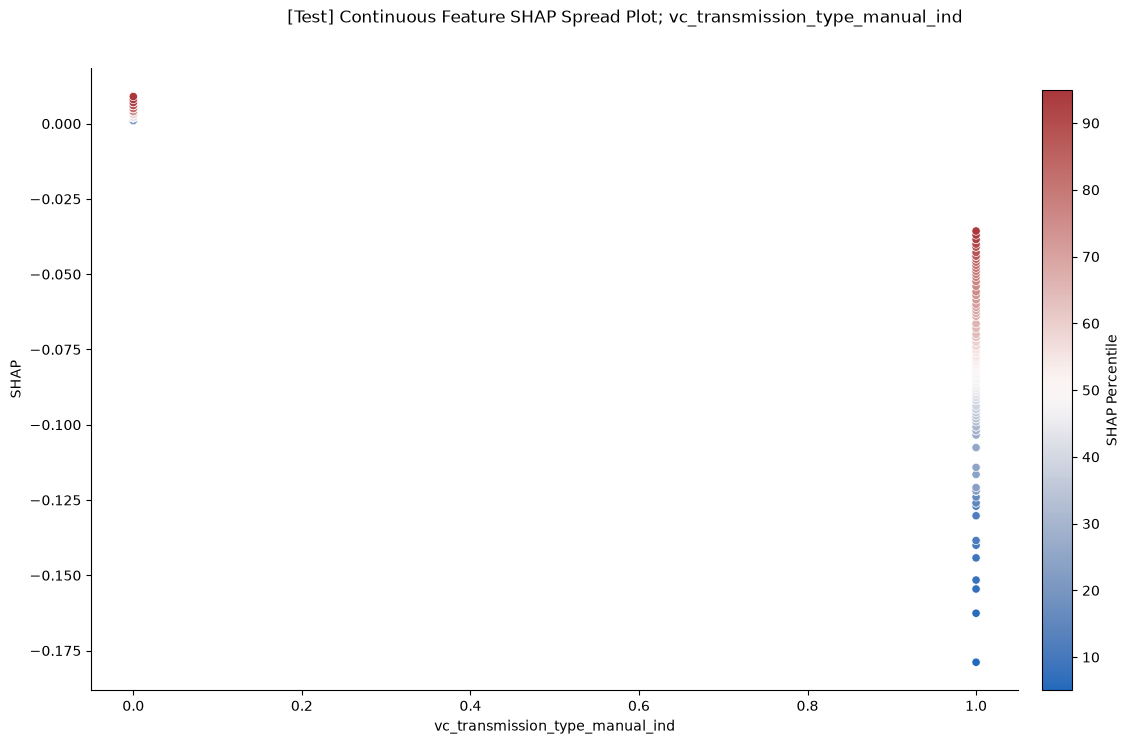


FEATURE: vc_variable_power_steering_raw


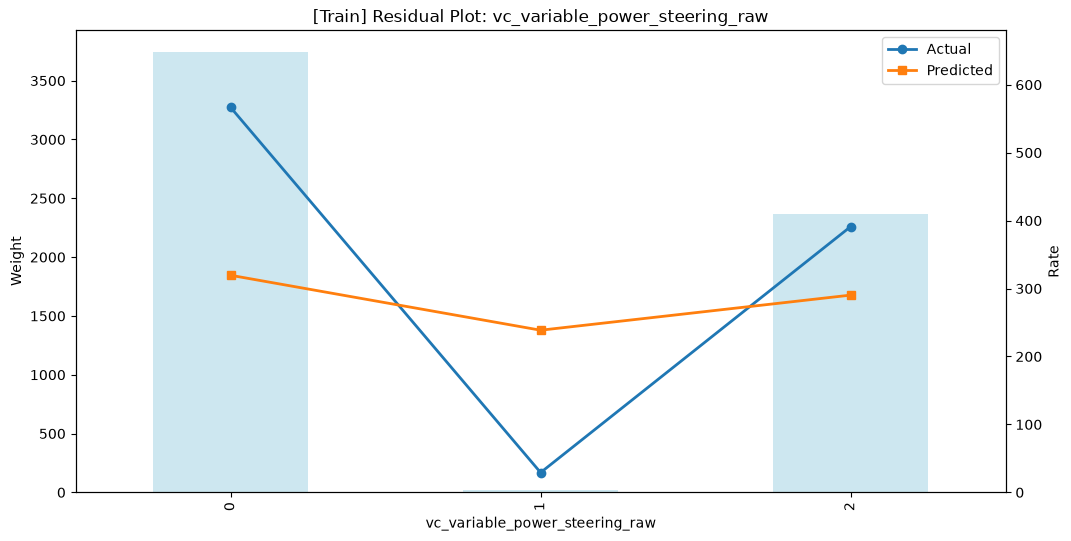

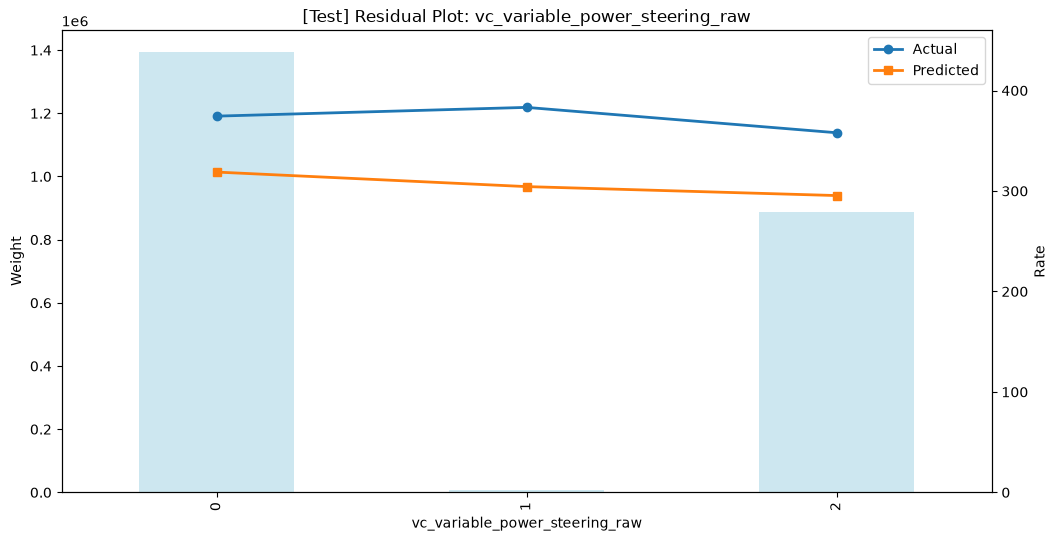


FEATURE: vc_taillights_led_raw


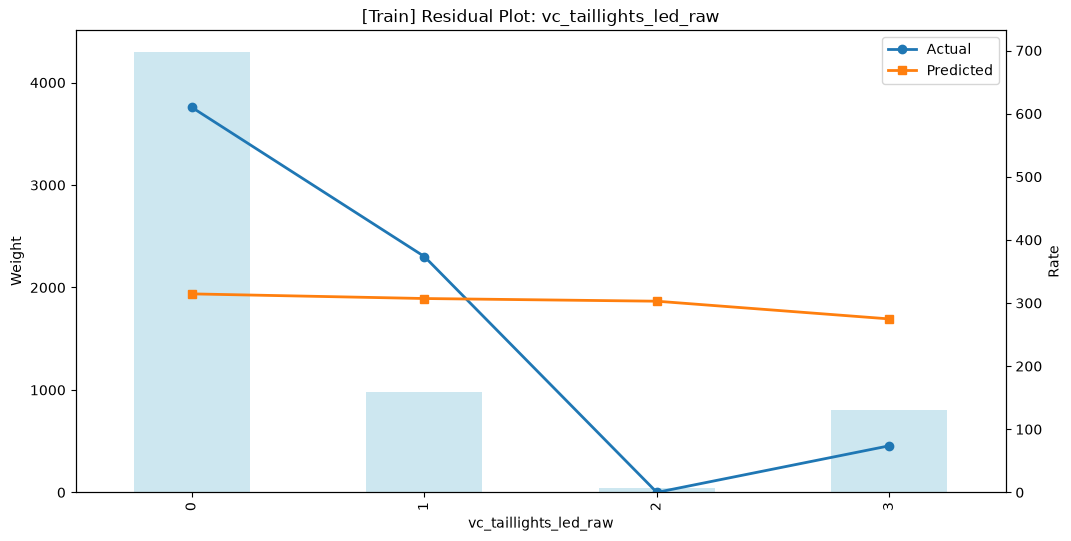

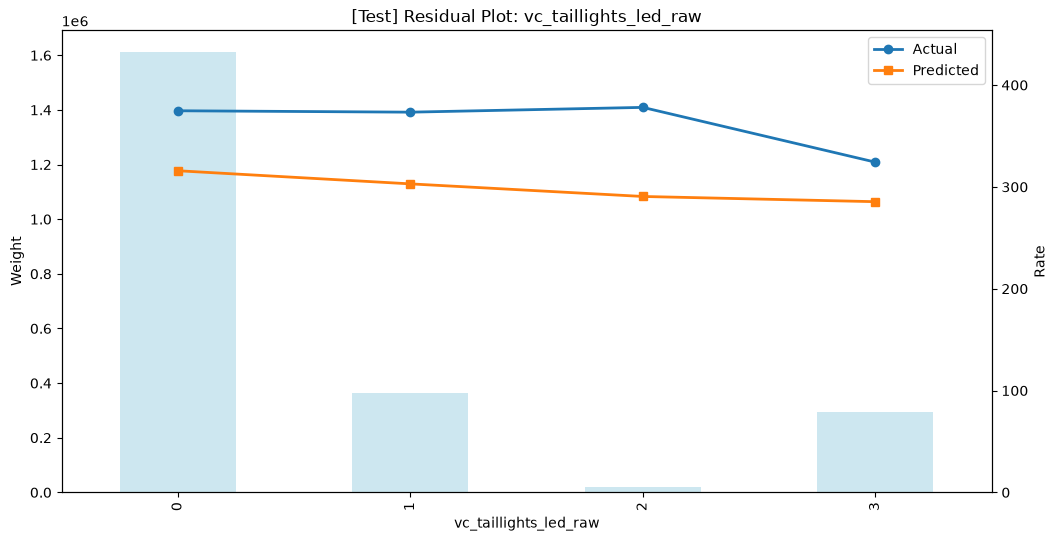


FEATURE: vc_blind_spot_warning_raw


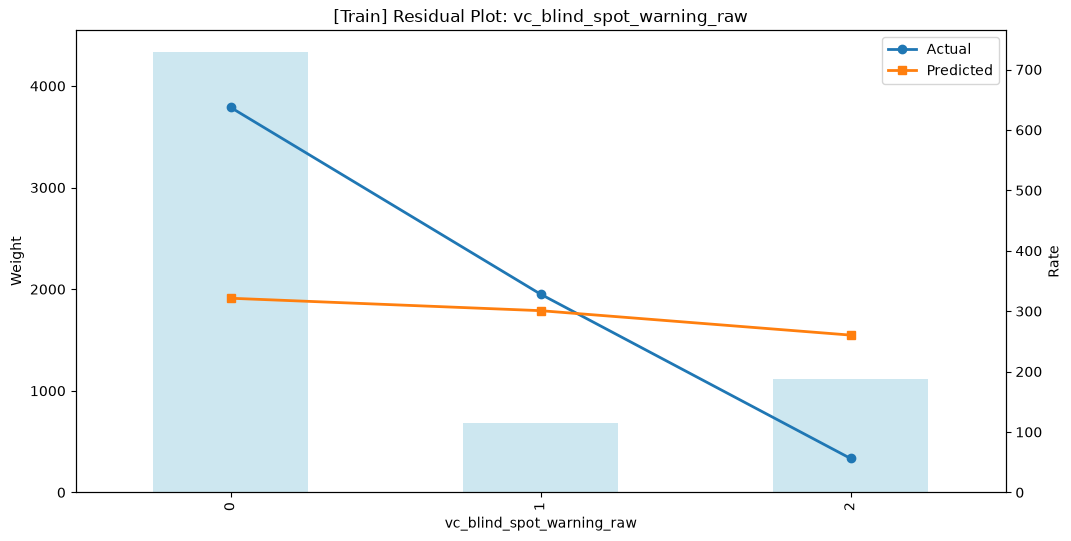

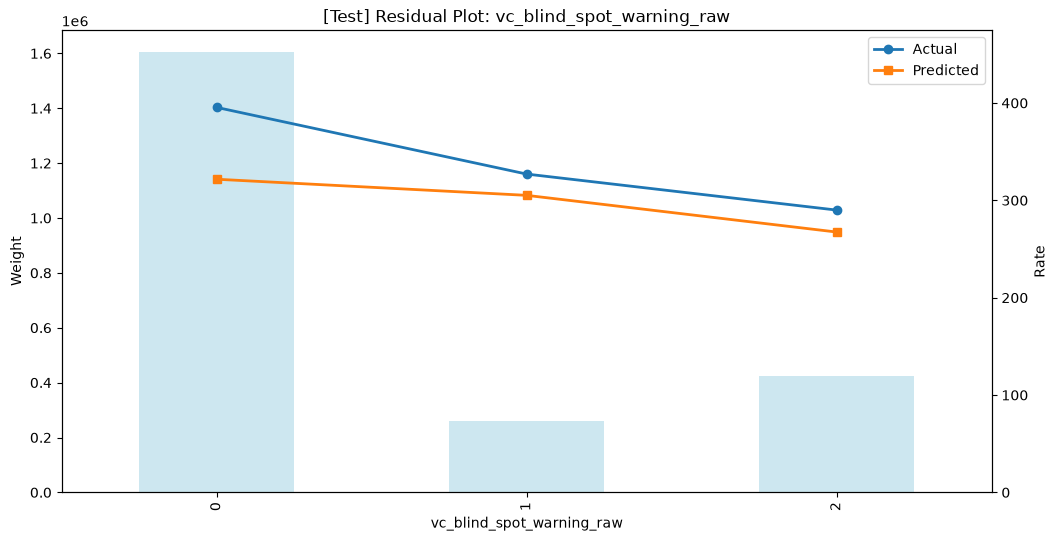


FEATURE: vc_headlights_auto_on_off_raw


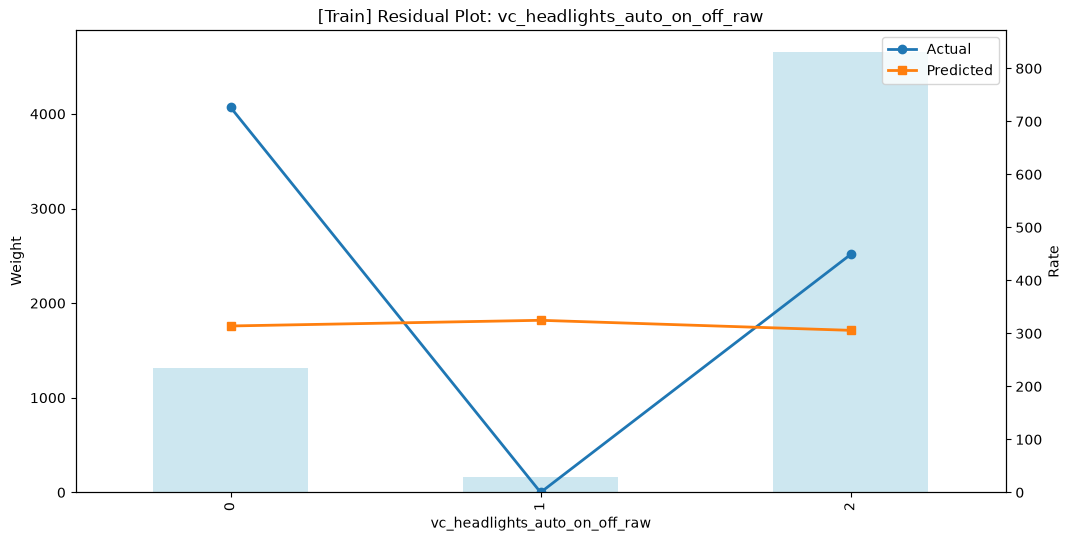

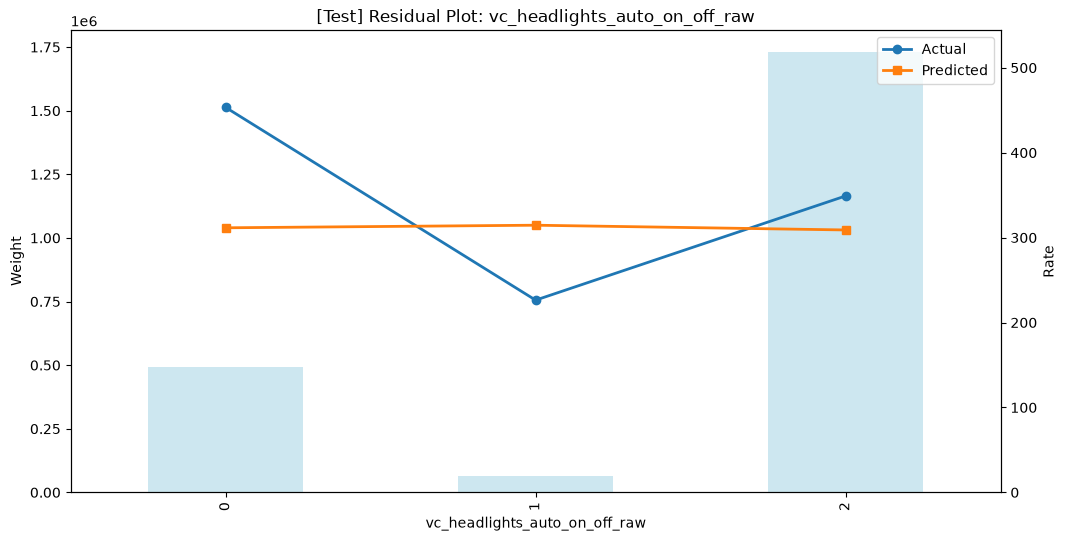


FEATURE: vc_touch_screen_raw


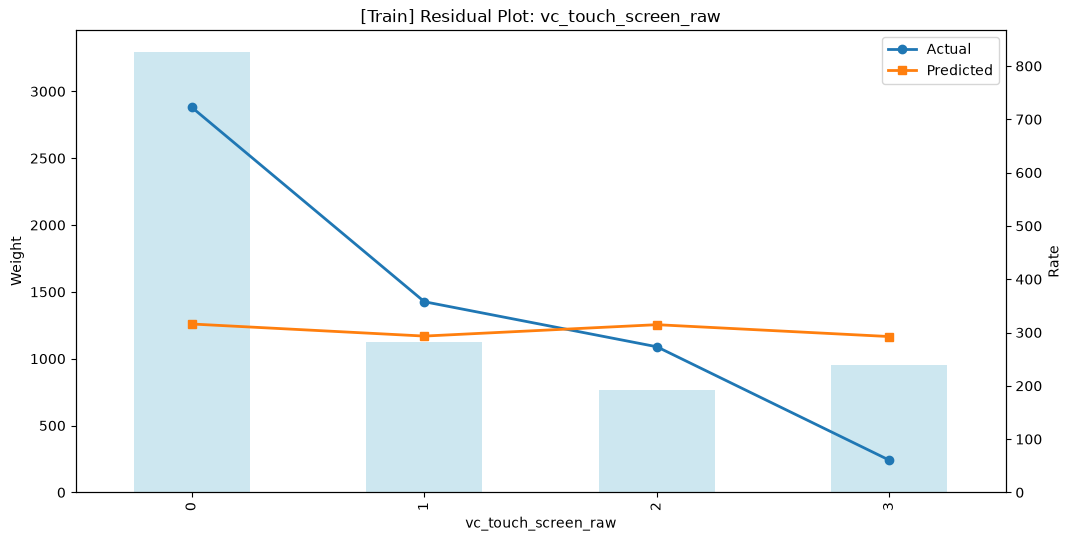

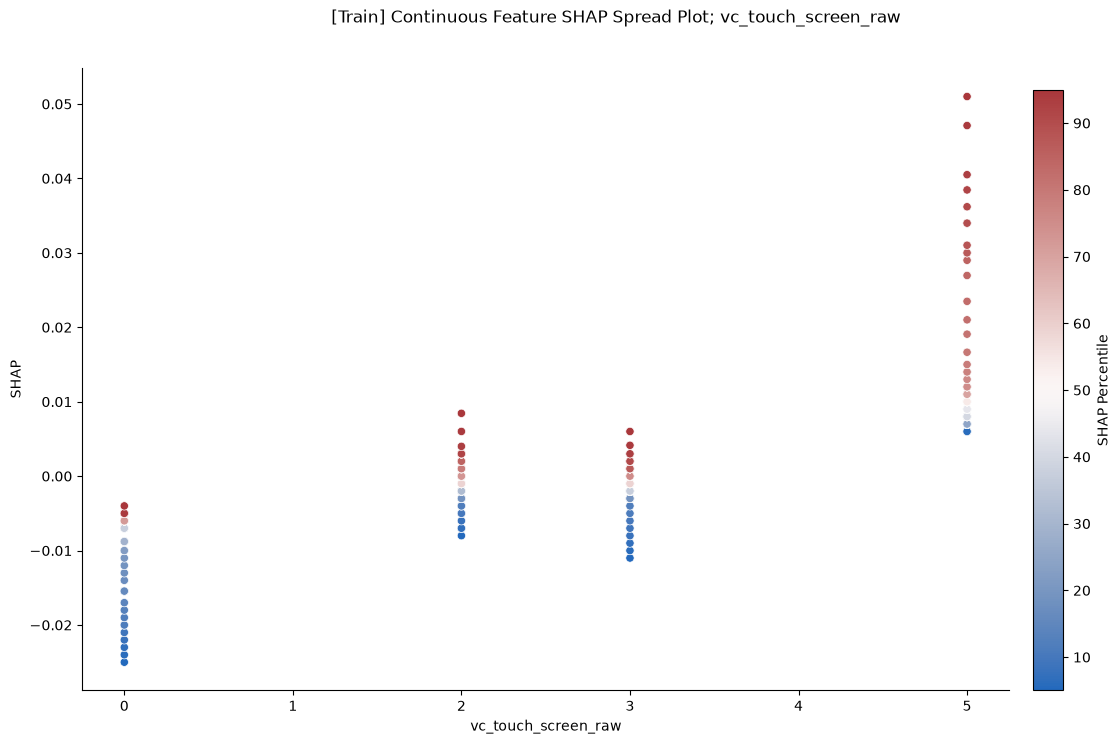

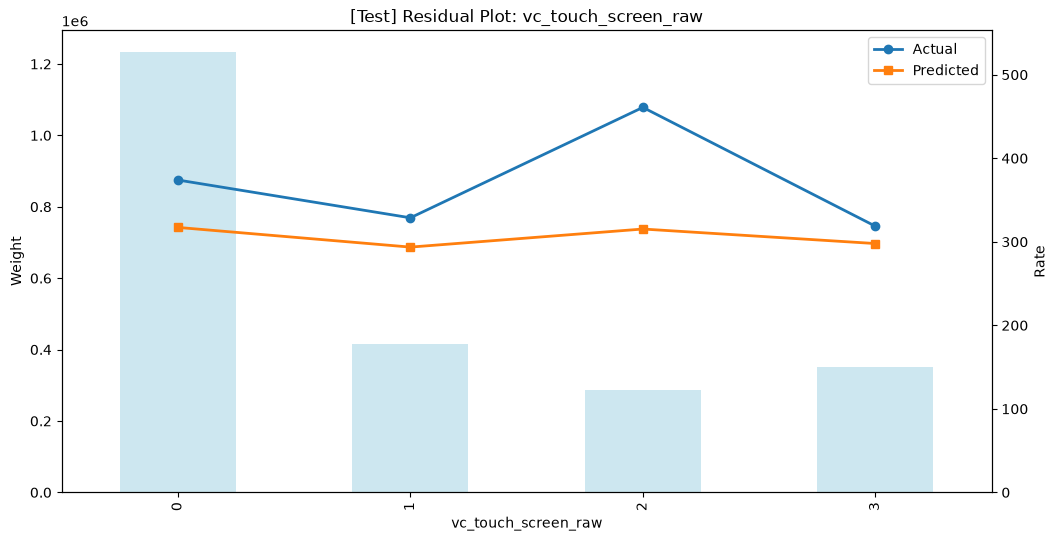

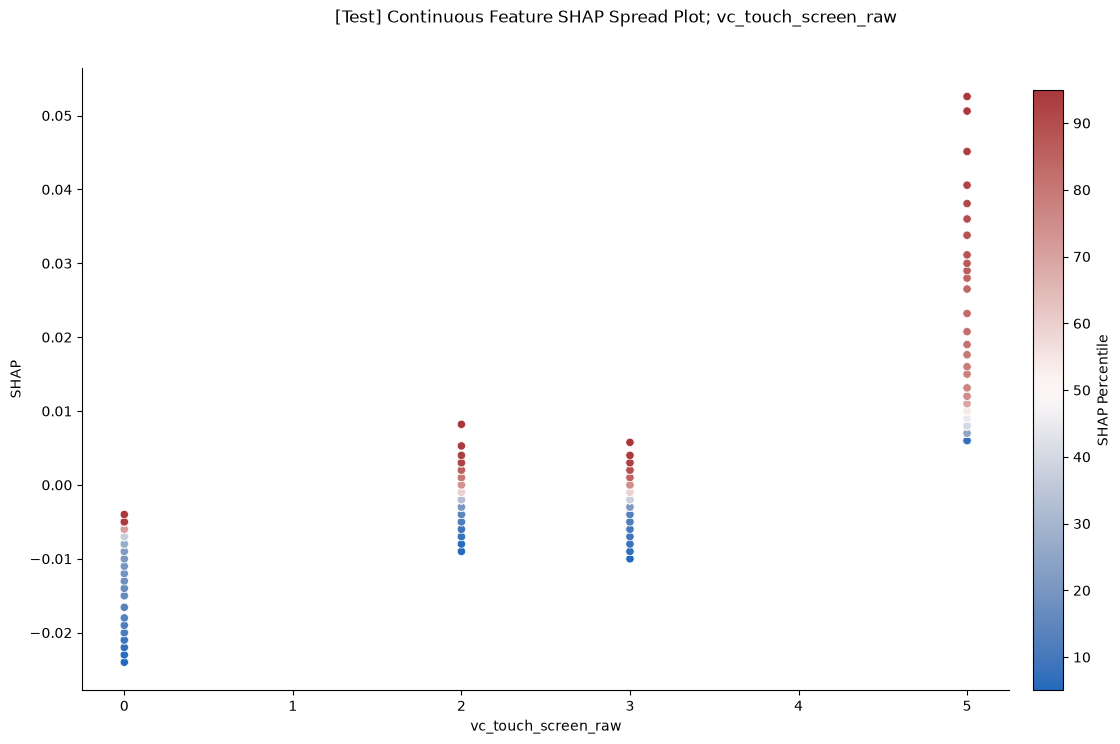


FEATURE: vc_lane_departure_warning_raw


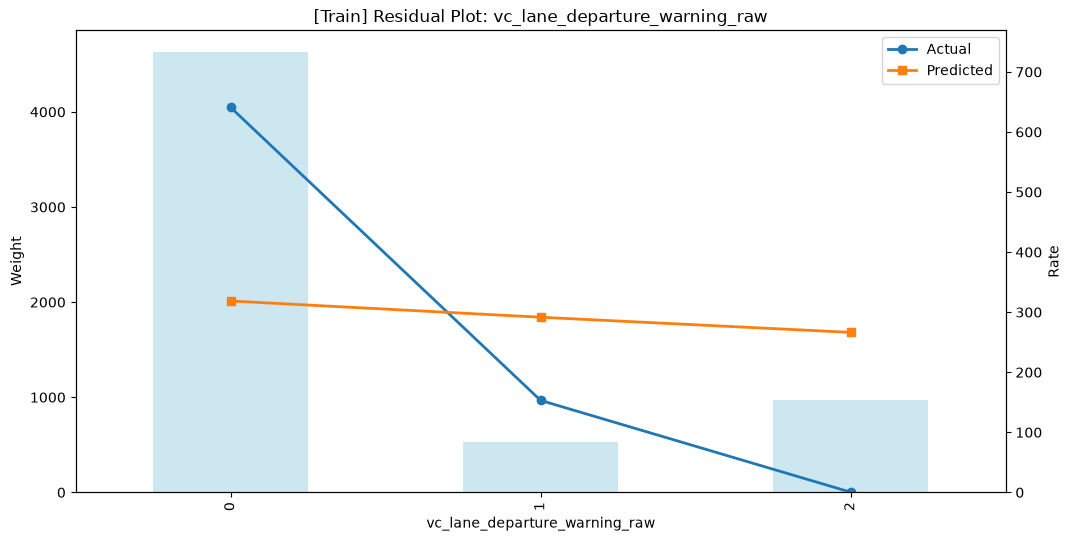

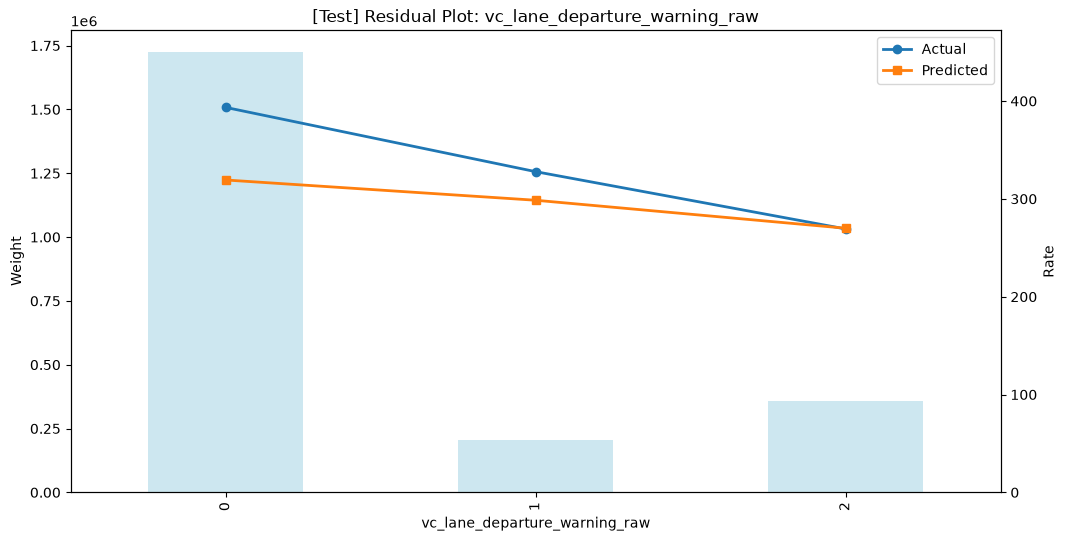


FEATURE: vc_driver_attention_system_raw


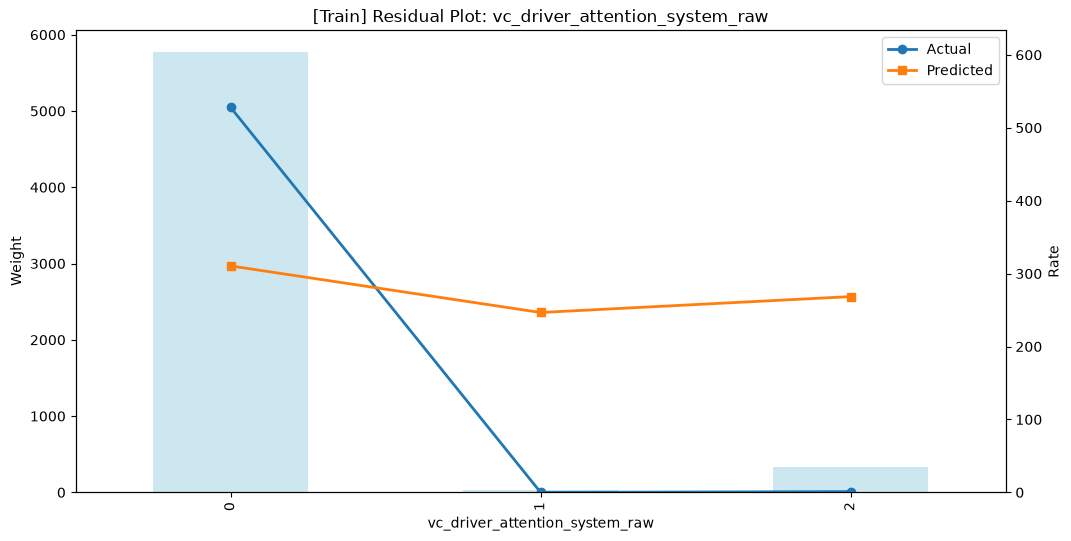

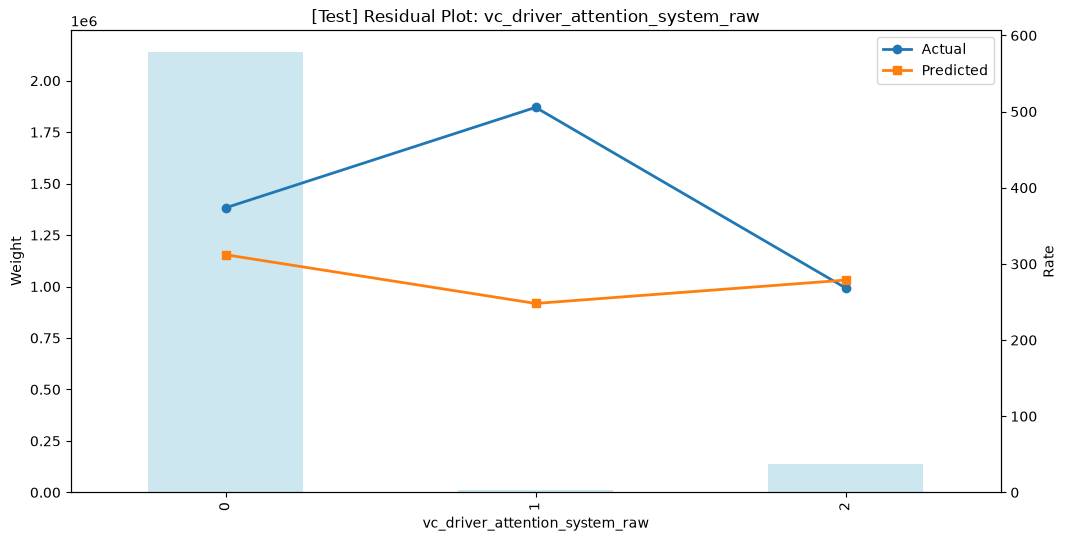


FEATURE: vc_audible_forward_collision_warning_raw


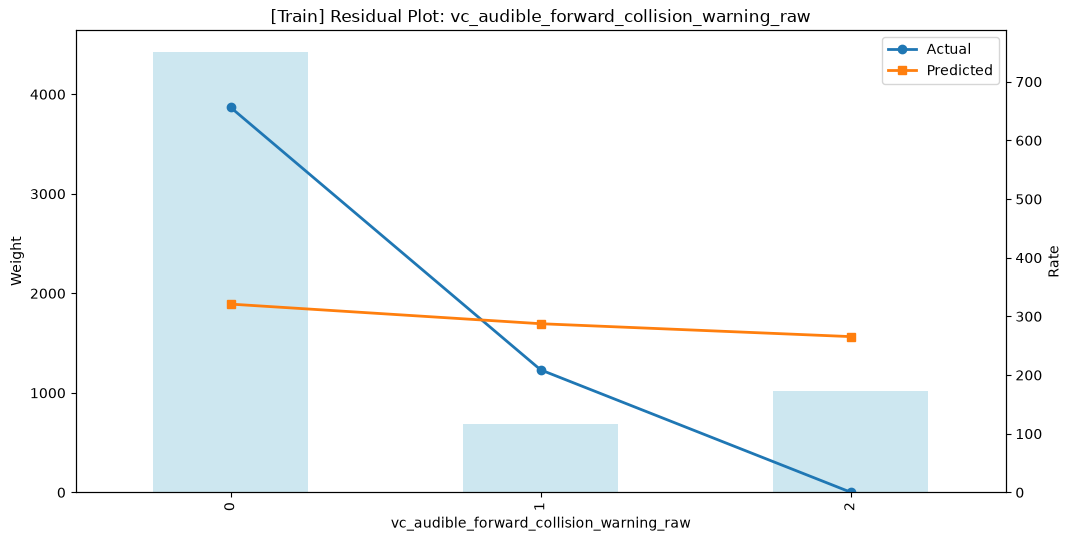

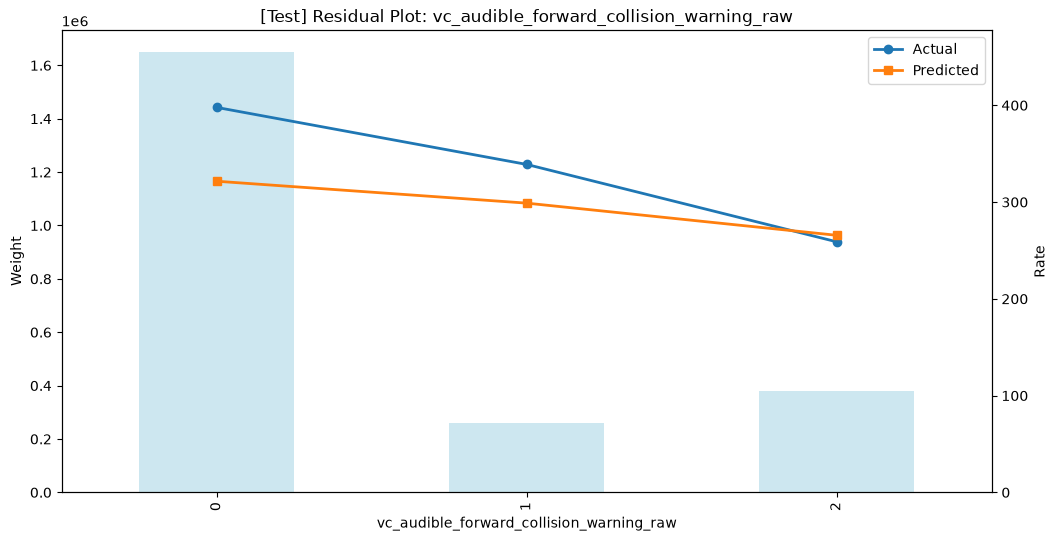


FEATURE: vc_adaptive_cruise_control_raw


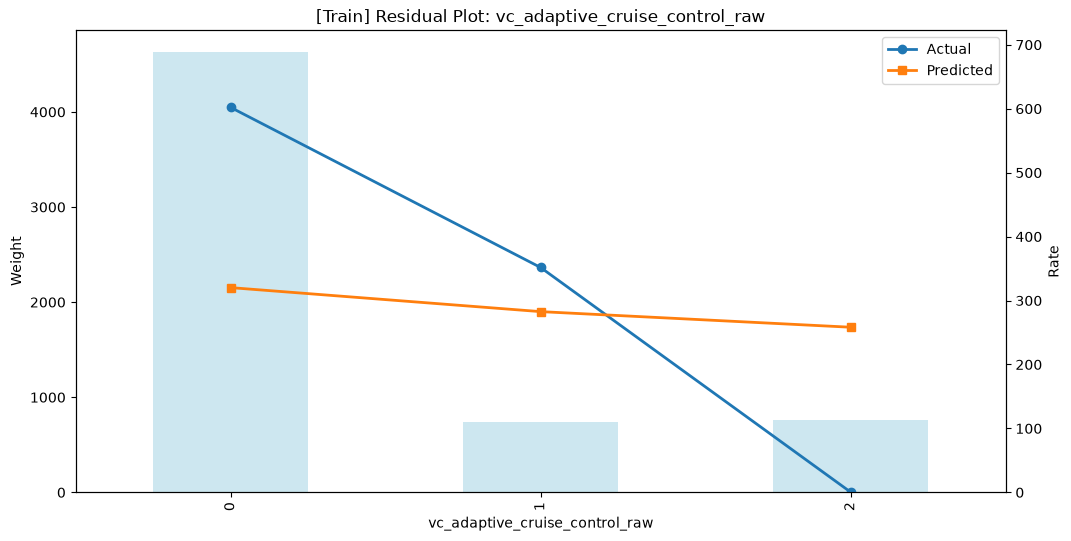

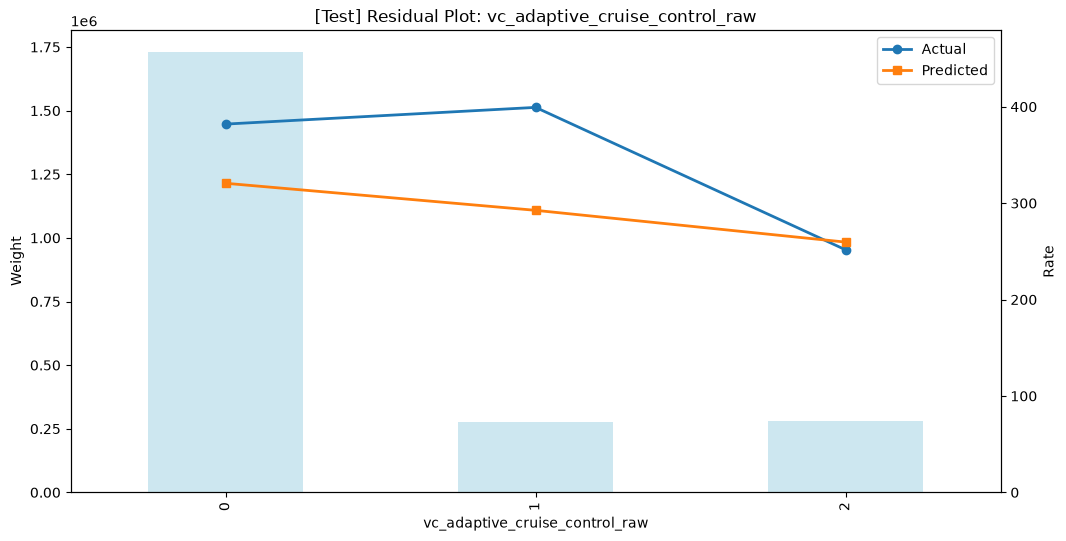


FEATURE: vc_auto_dimming_rearview_mirror_raw


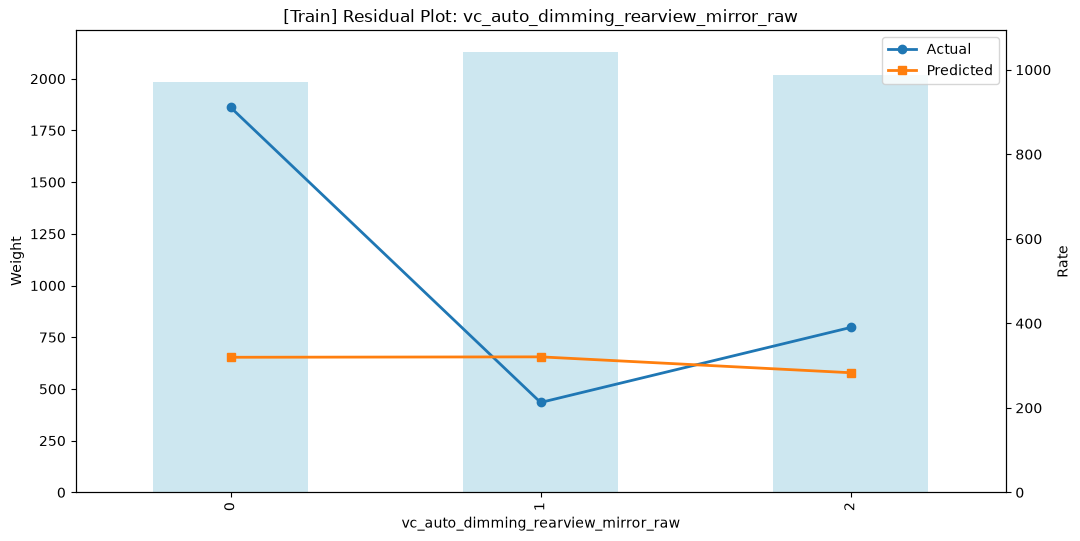

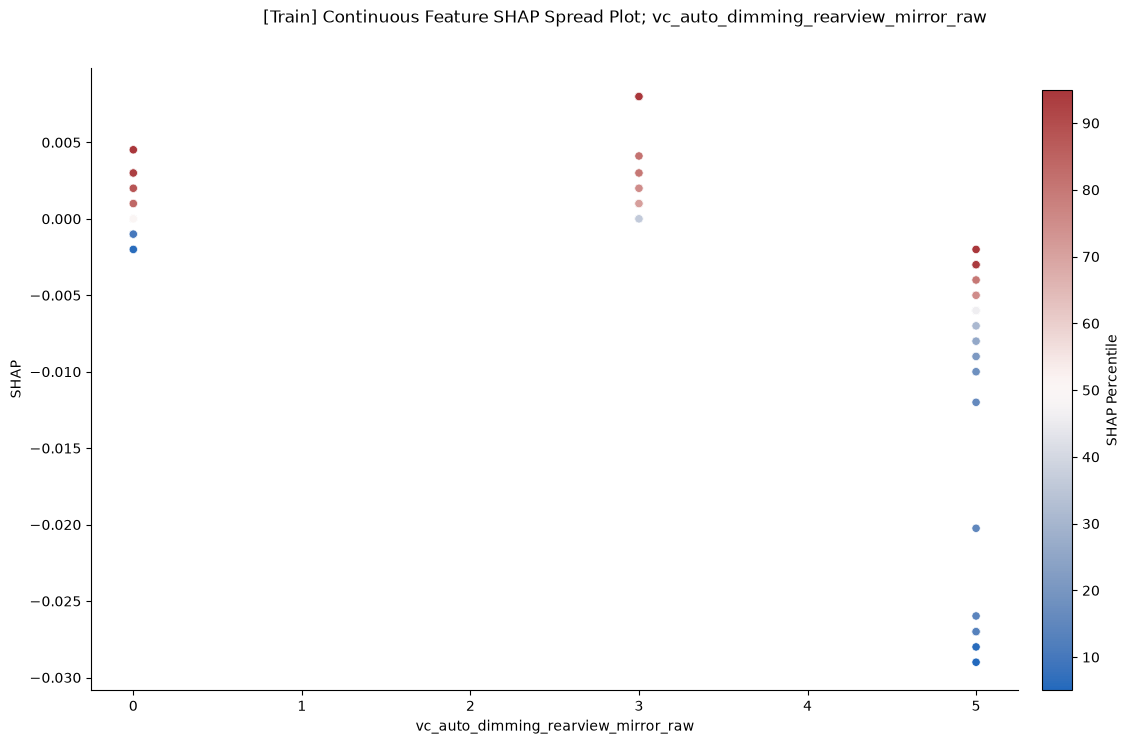

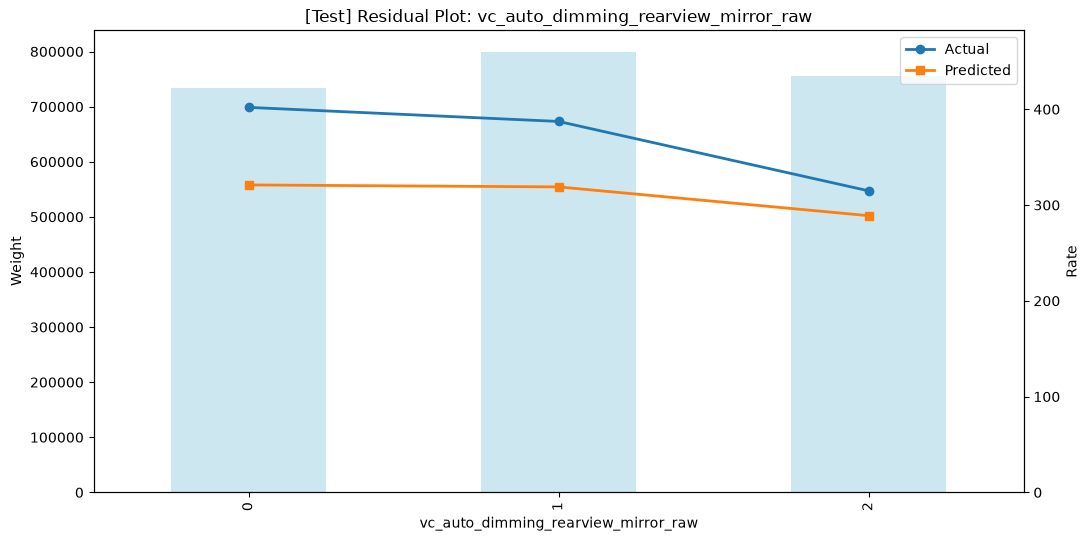

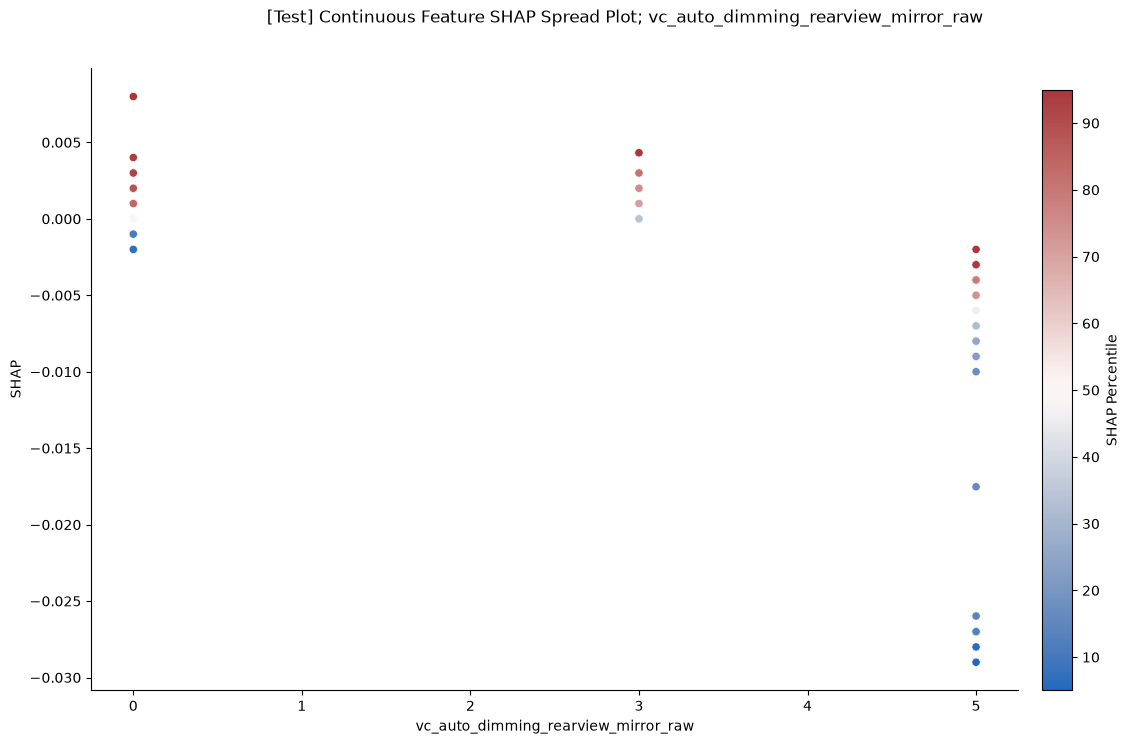


FEATURE: vc_pedestrian_detection_raw


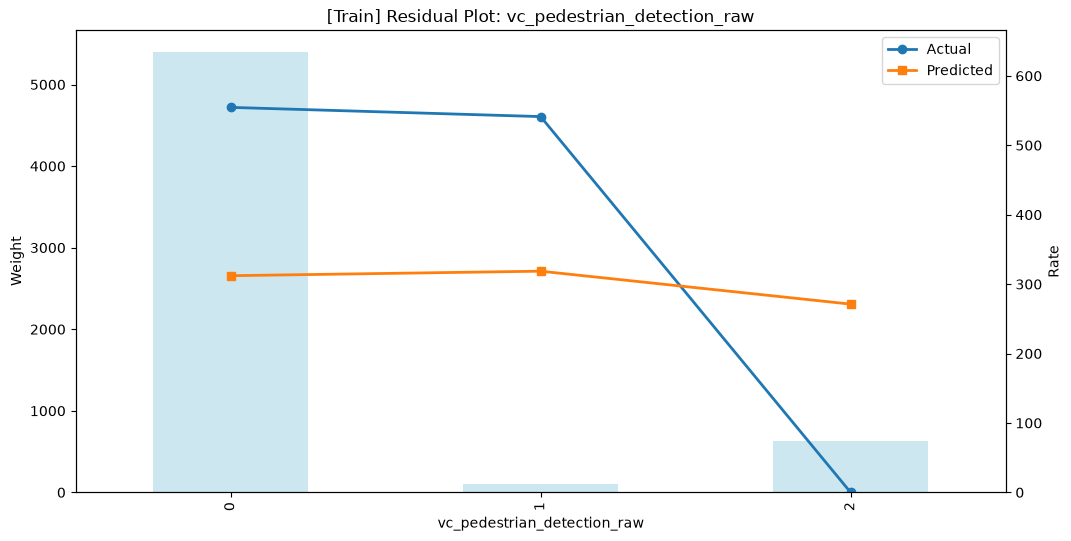

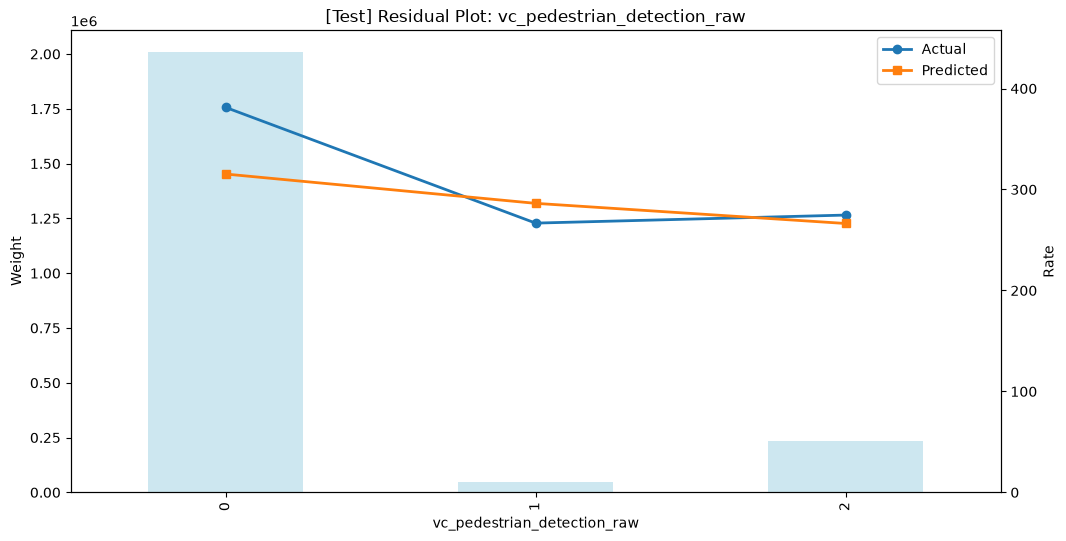


FEATURE: vc_front_parking_sensors_raw


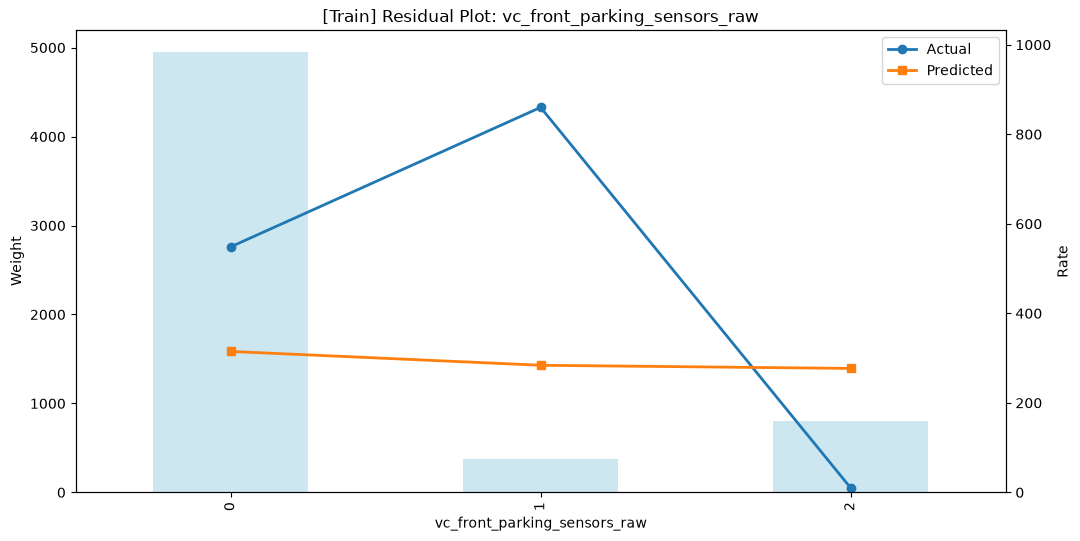

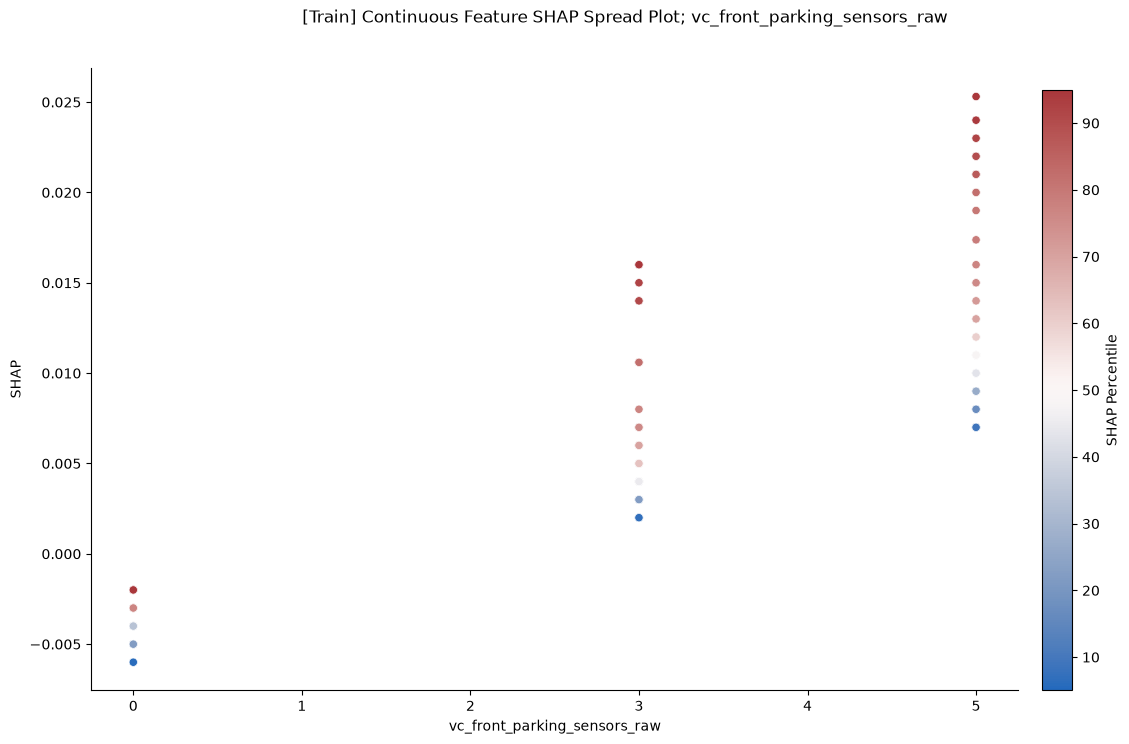

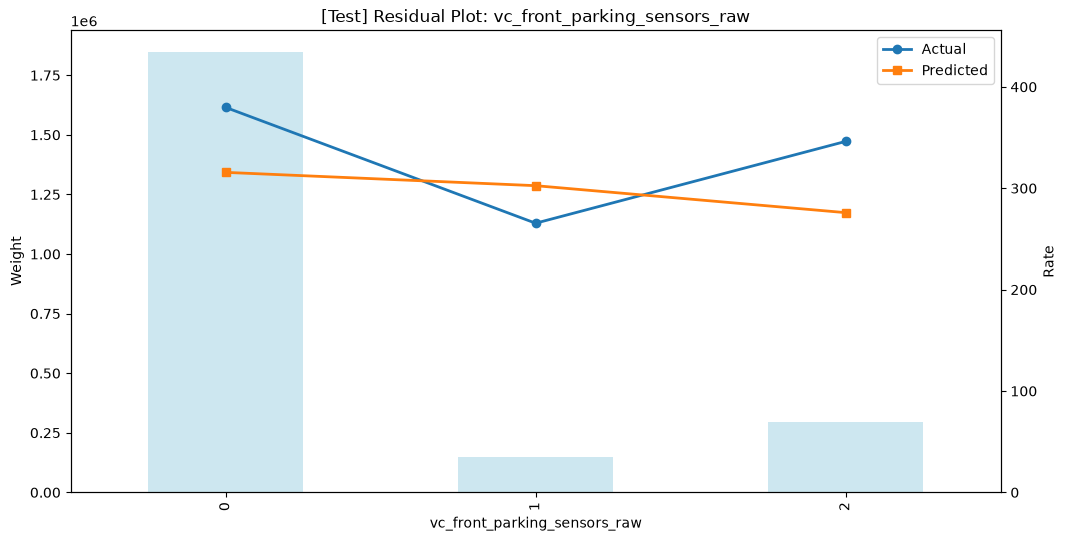

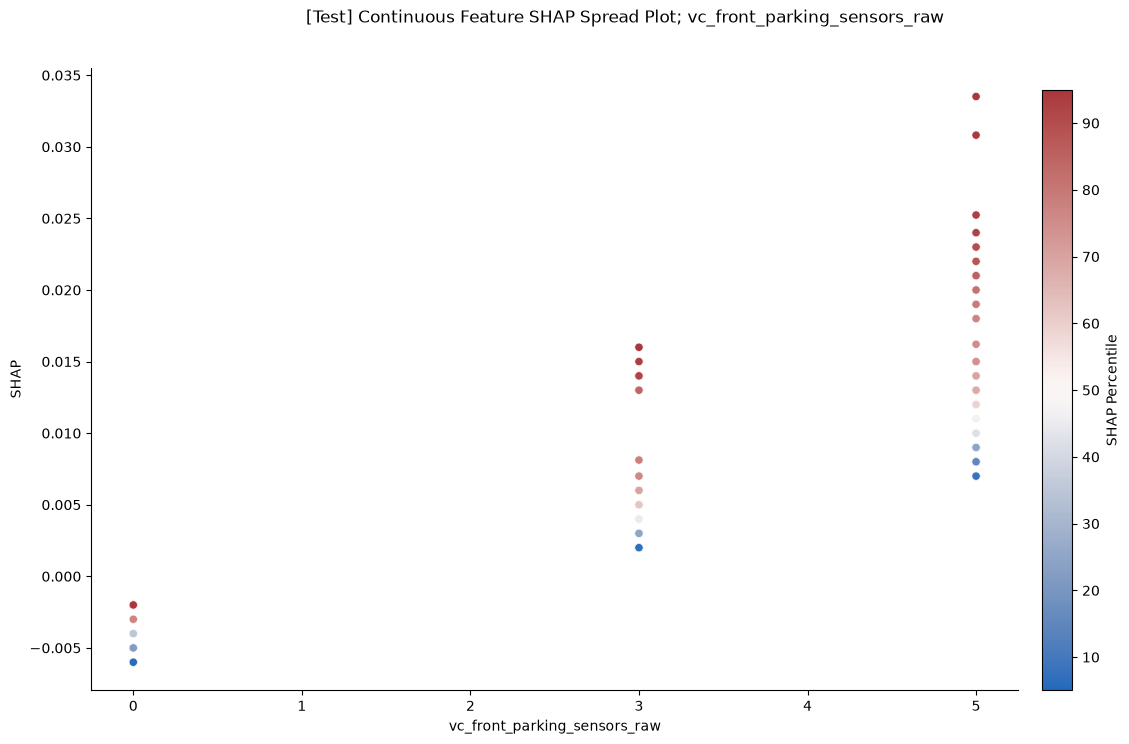


FEATURE: vc_wipers_automatic_raw


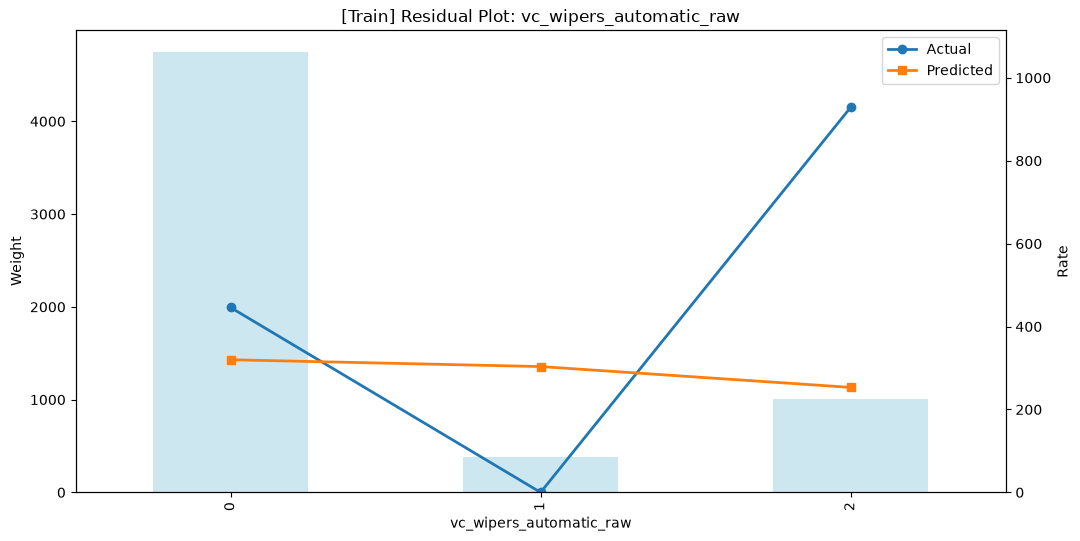

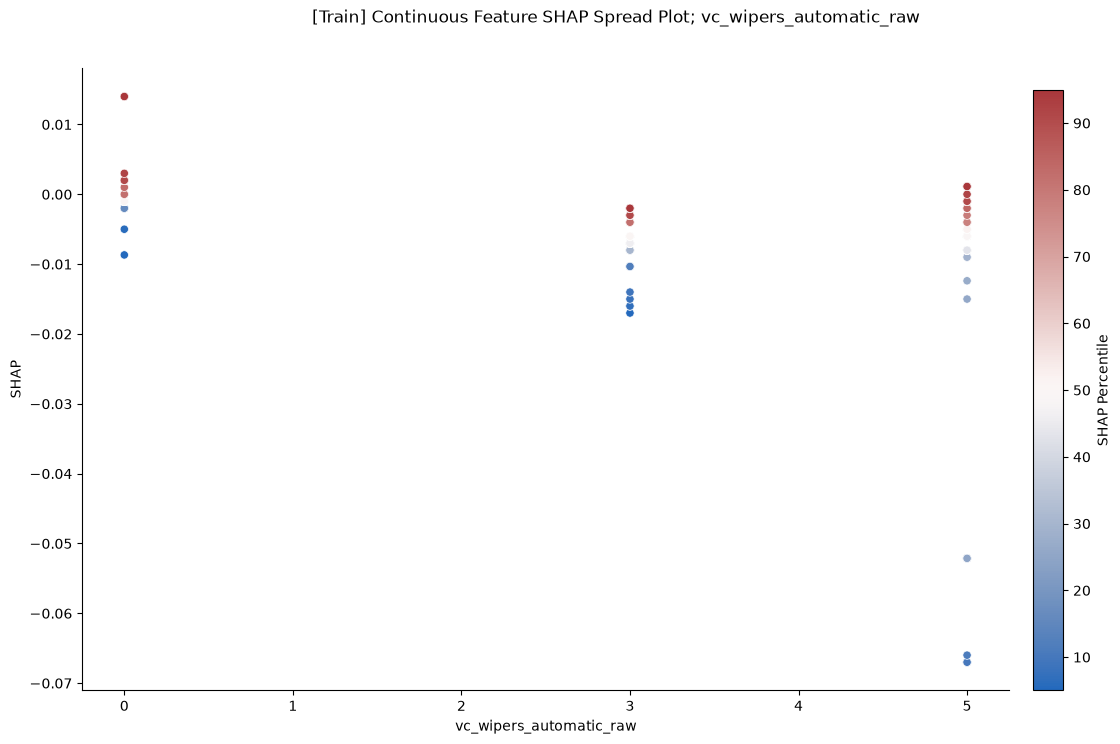

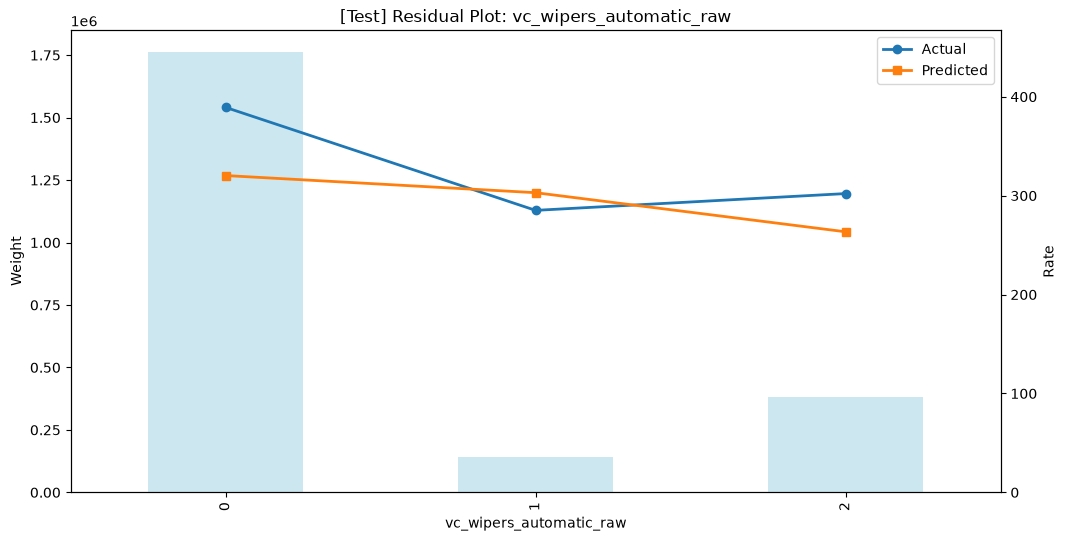

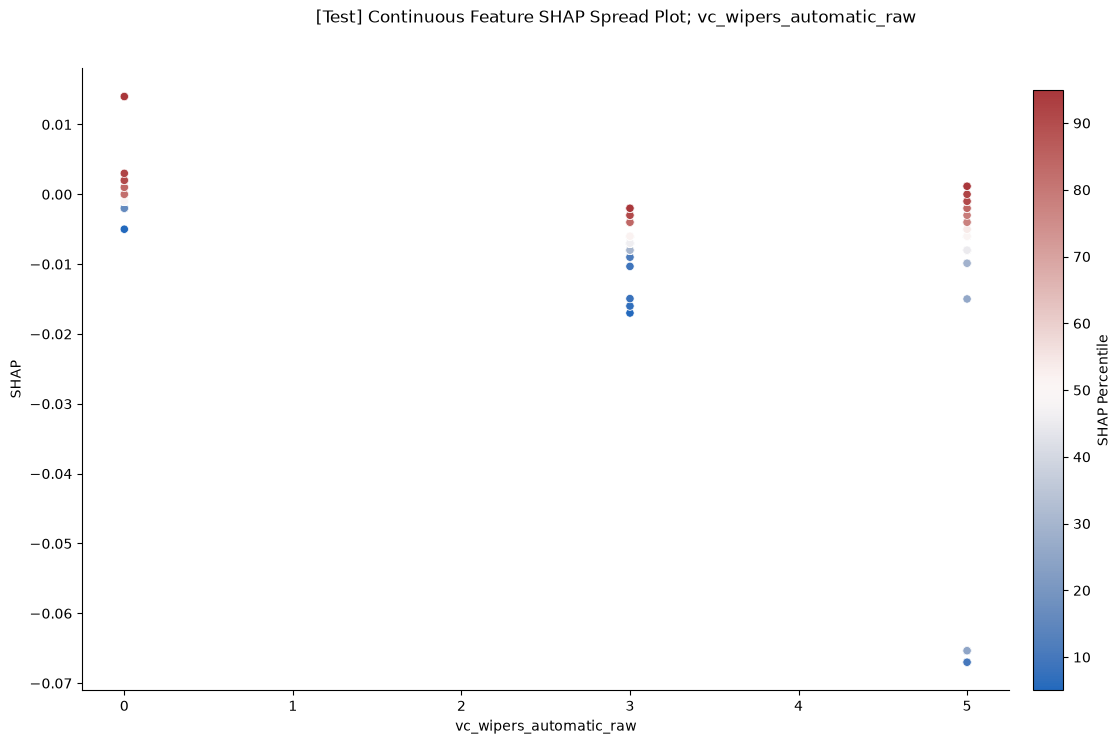


FEATURE: vc_forward_collision_warning_raw


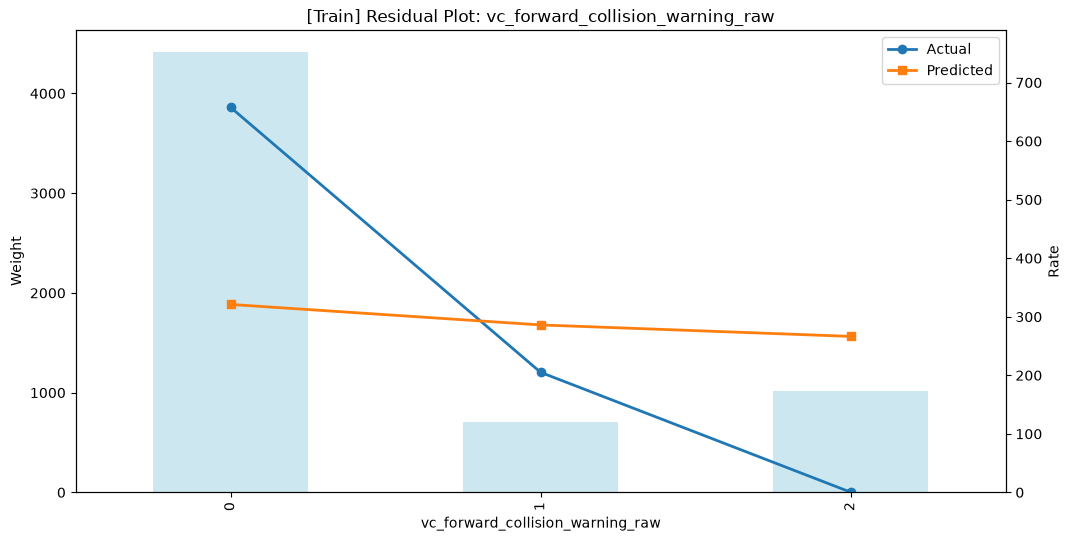

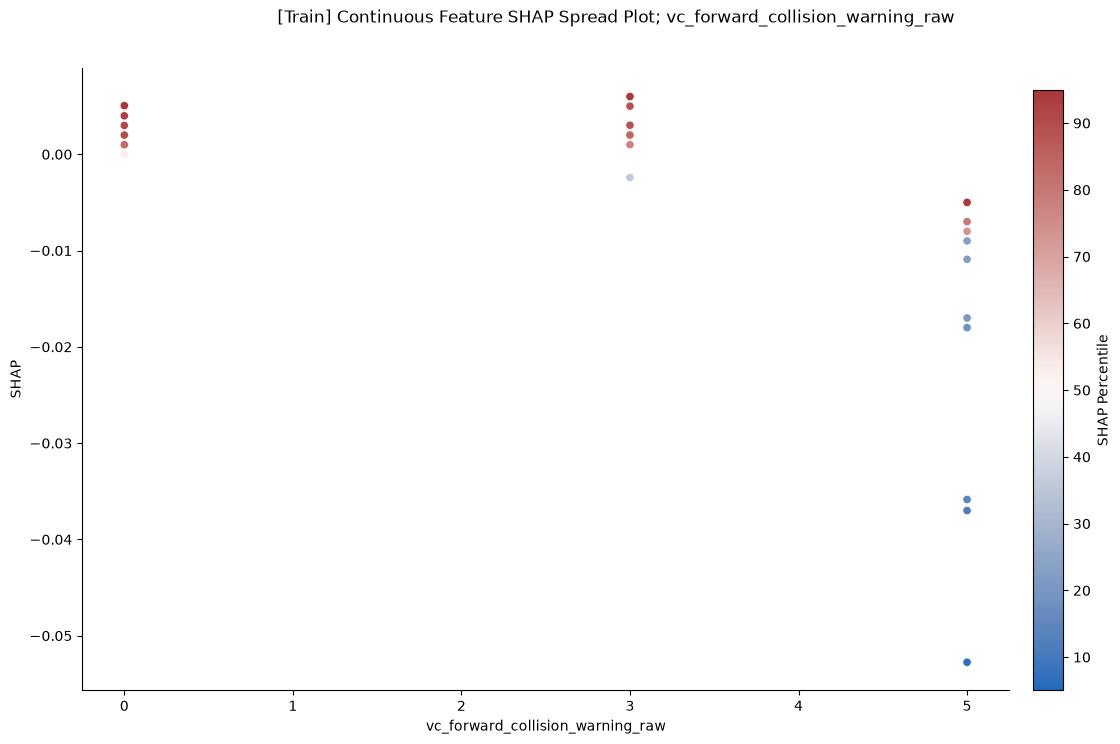

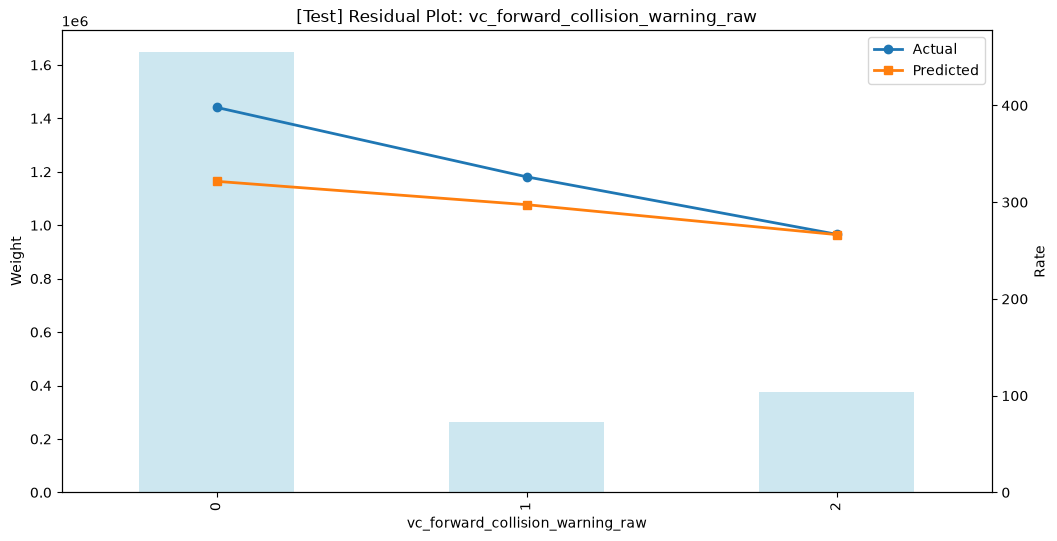

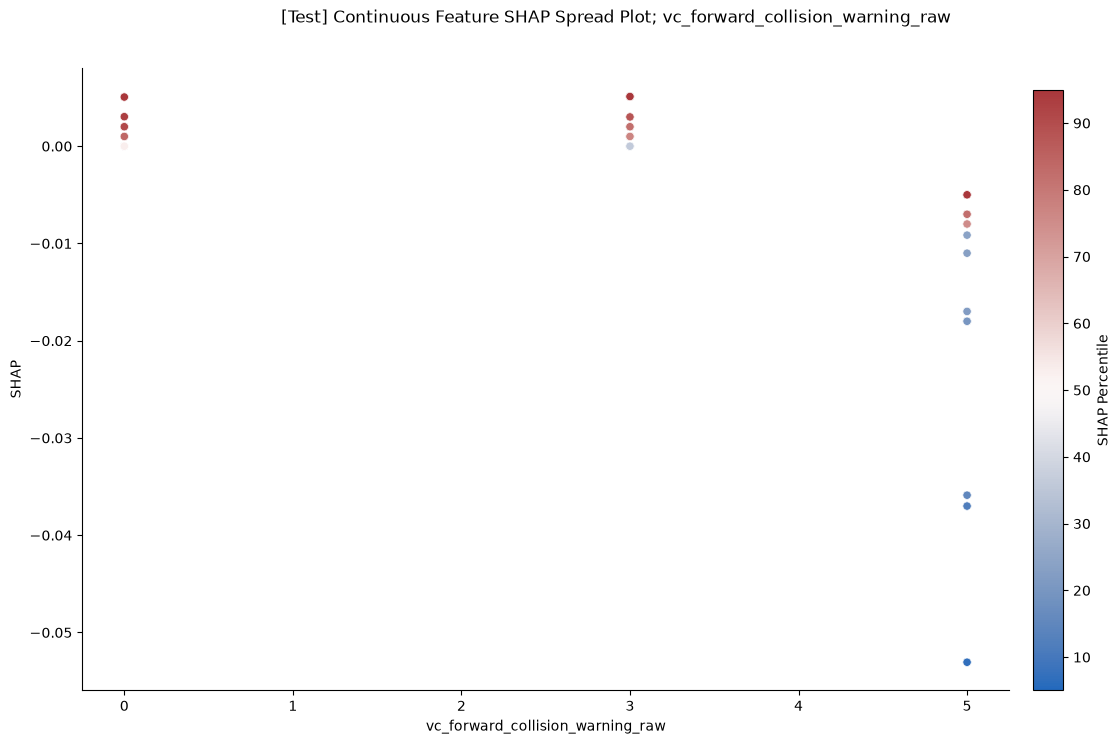


FEATURE: vc_active_collision_avoidance_system_raw


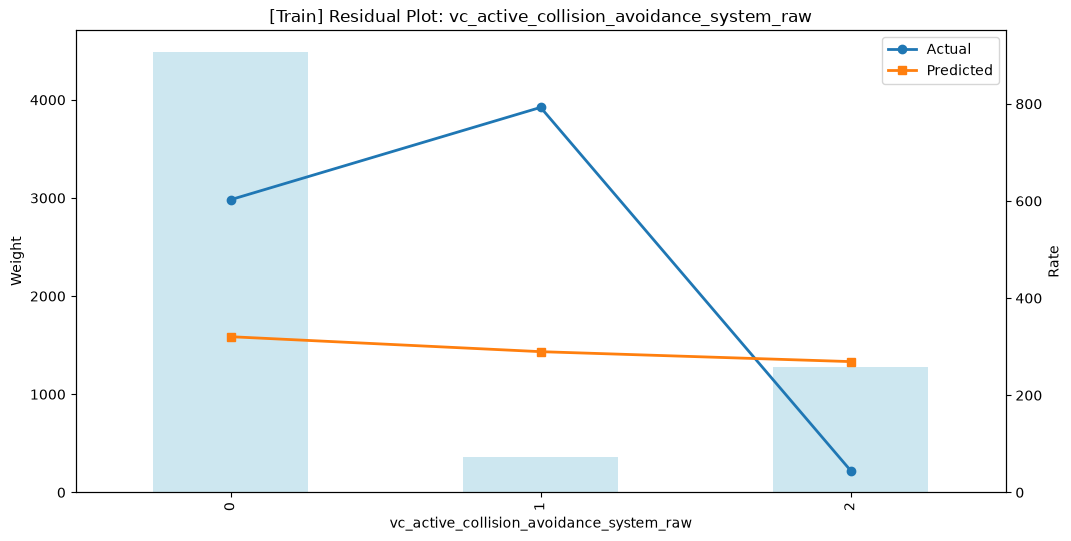

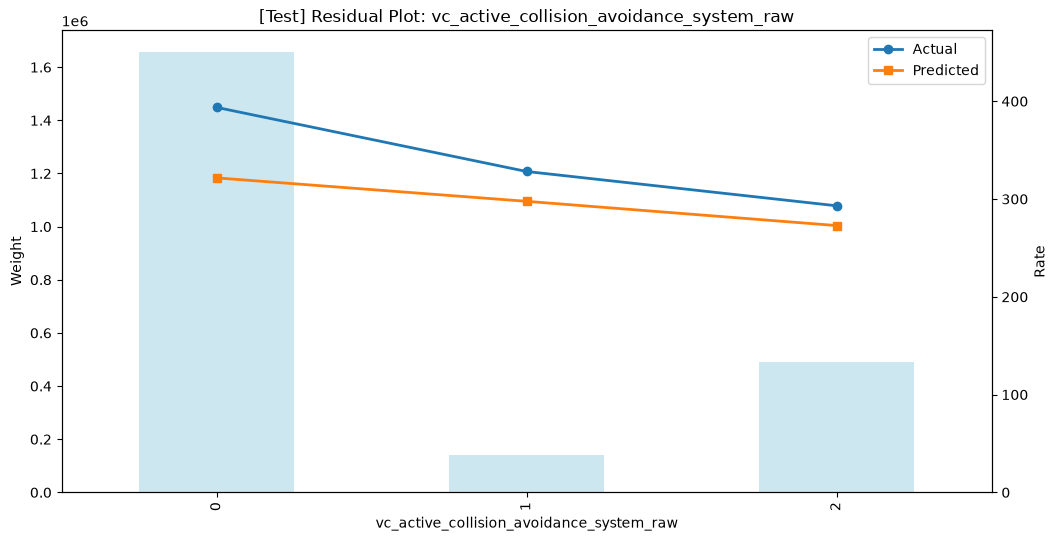


FEATURE: vc_automatic_high_beams_raw


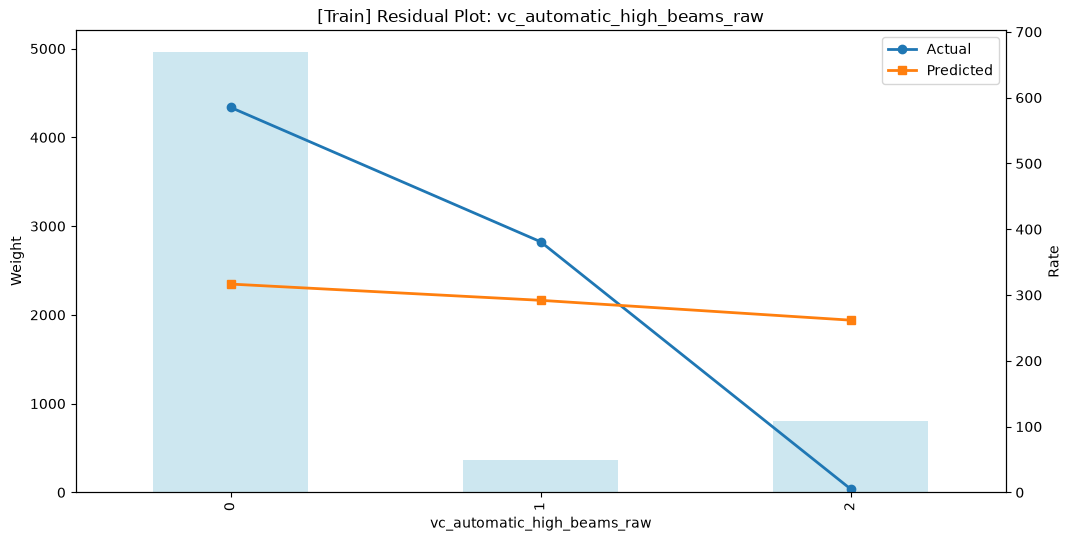

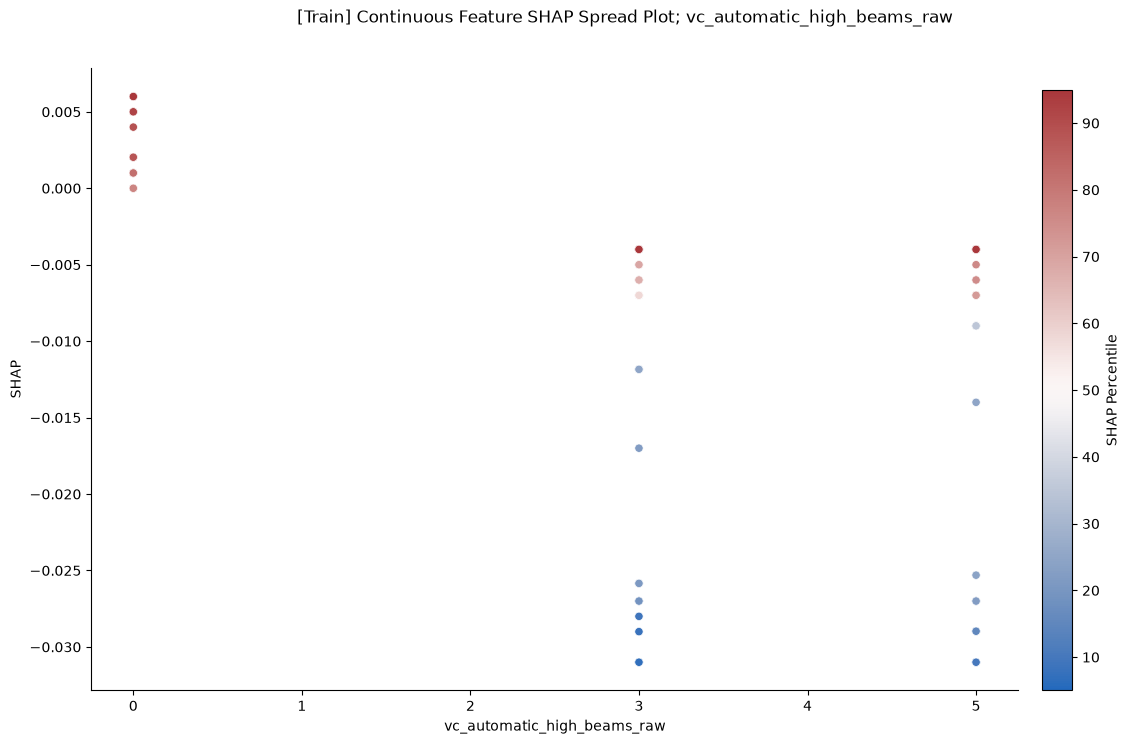

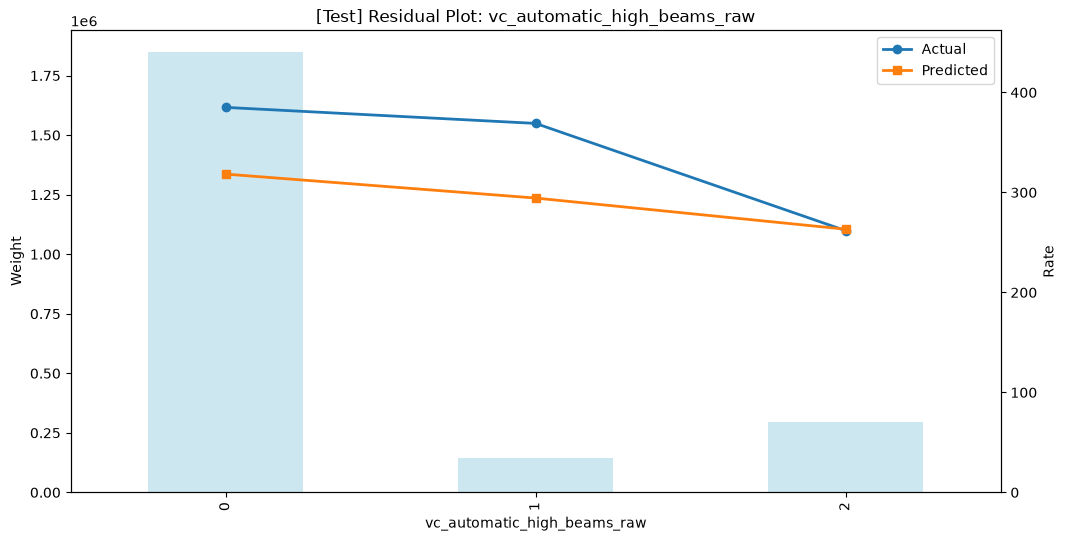

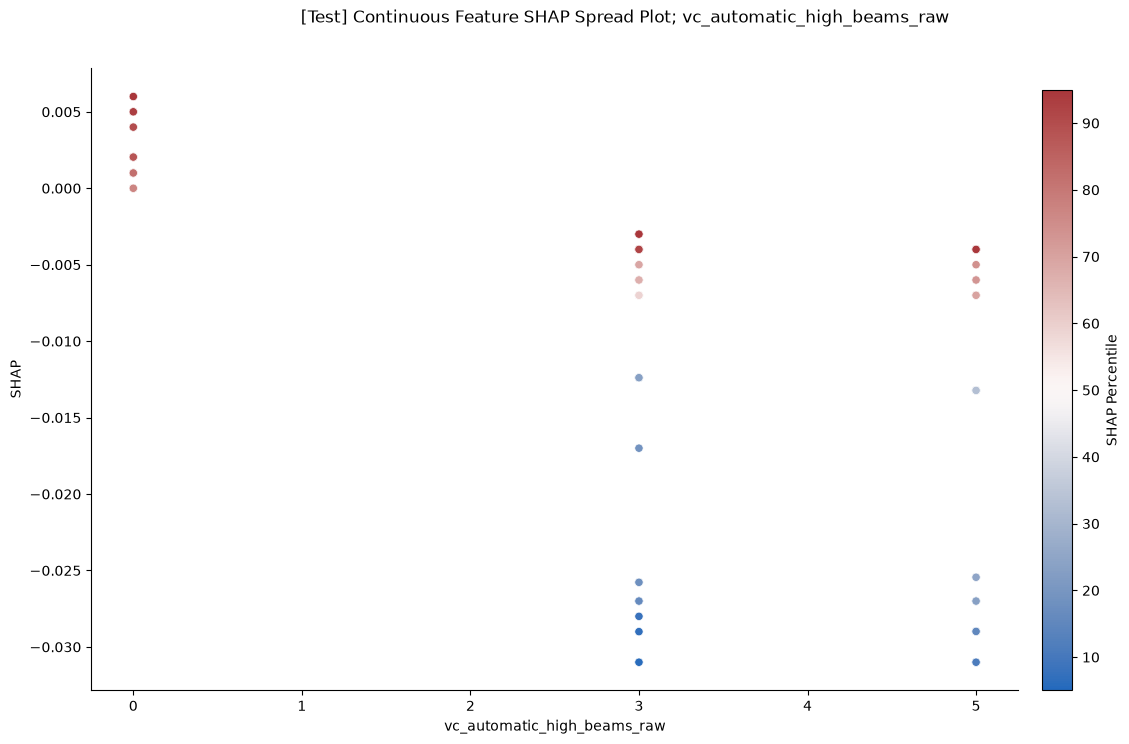


FEATURE: gender_male_ind


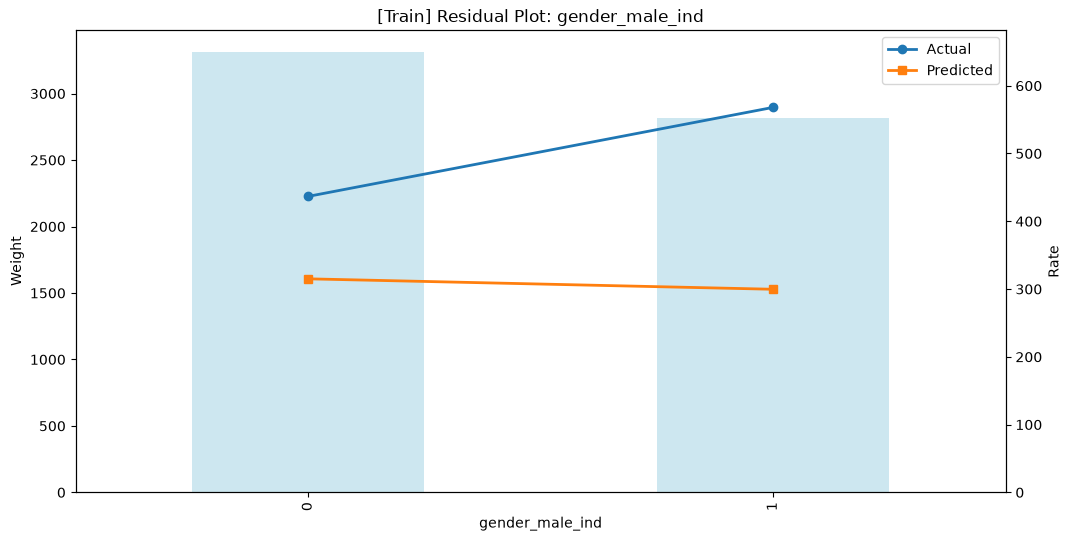

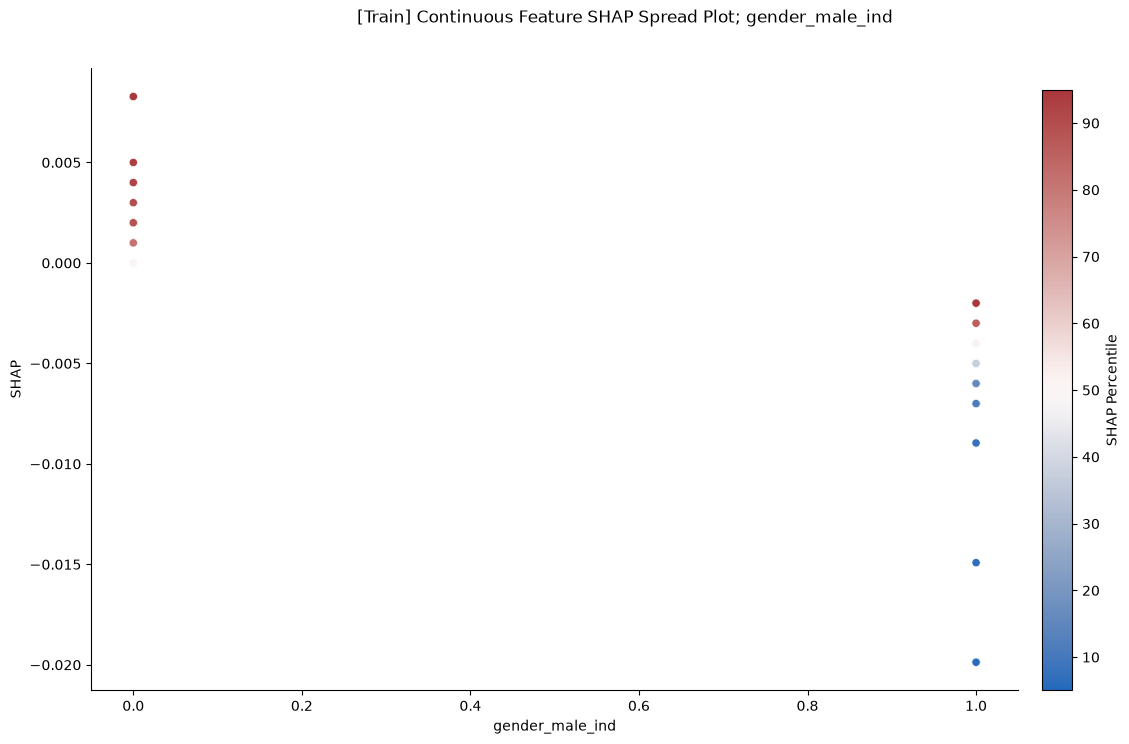

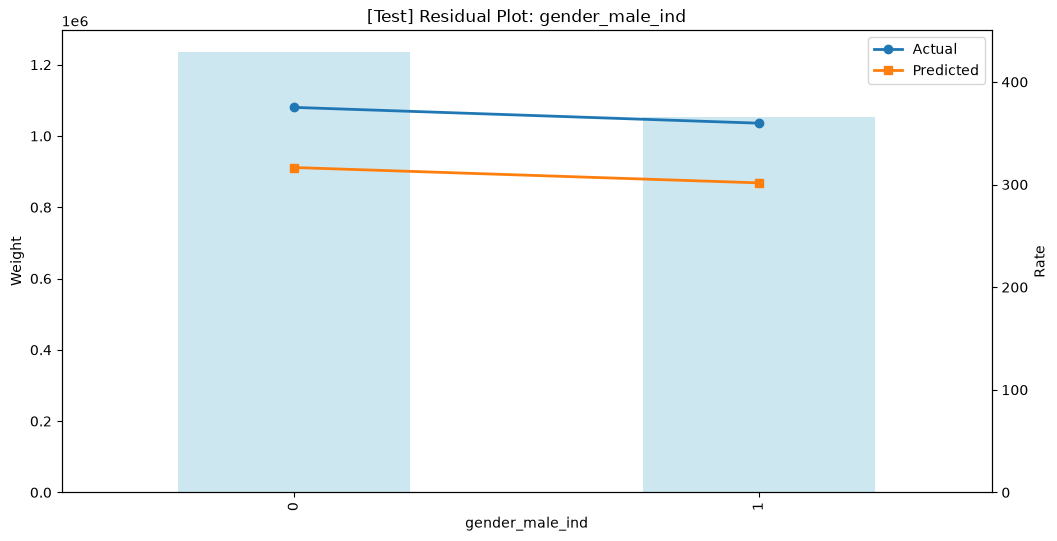

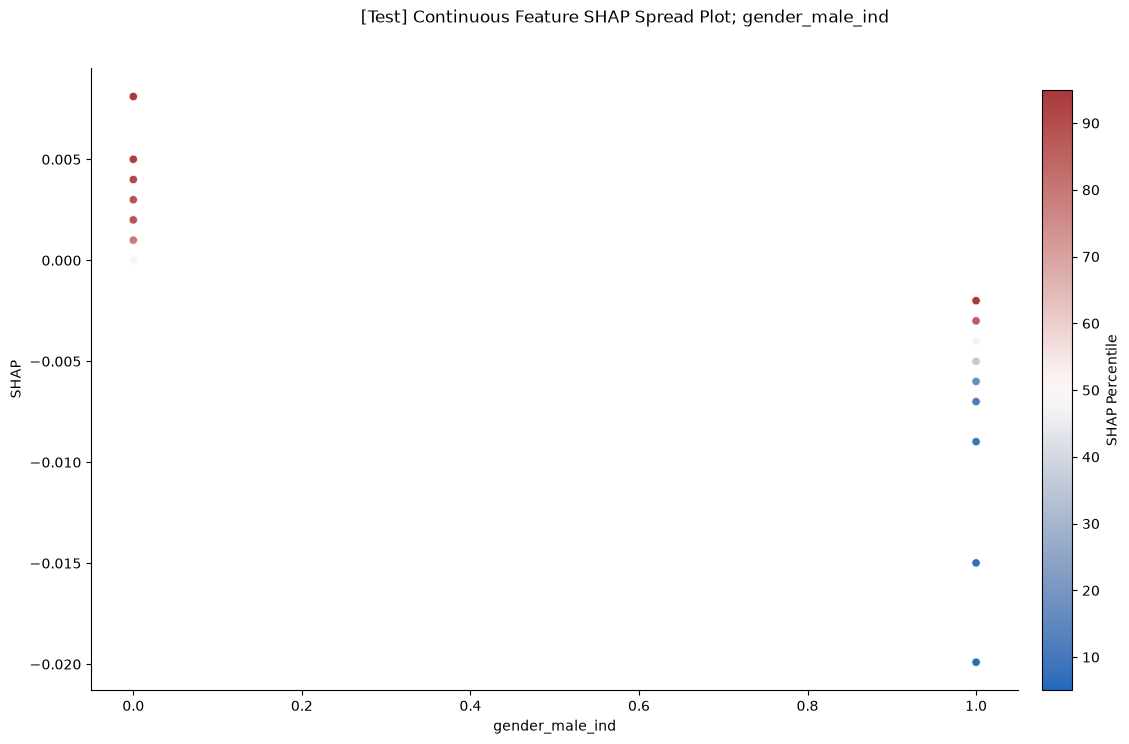


FEATURE: vc_surround_sound_raw


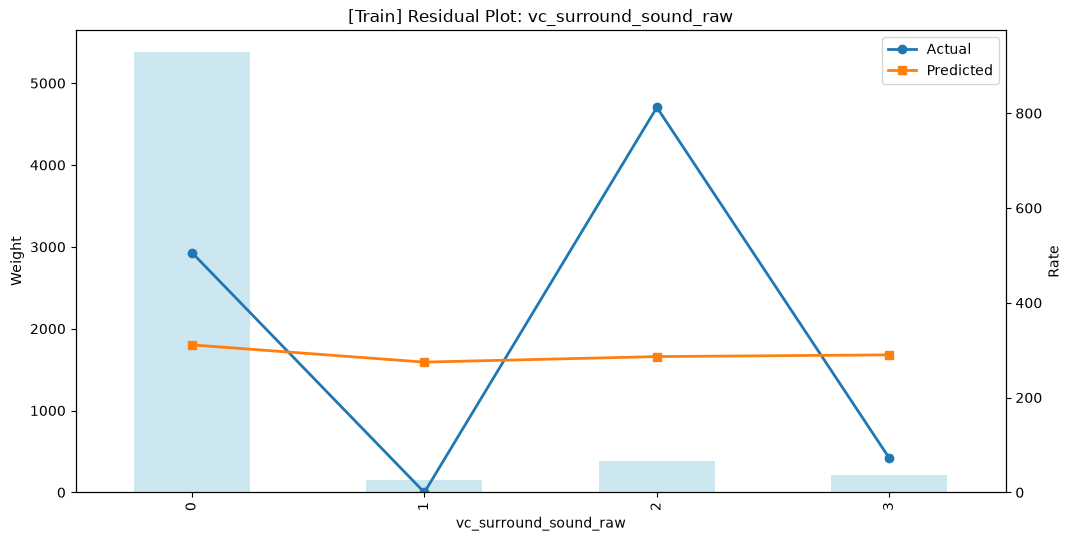

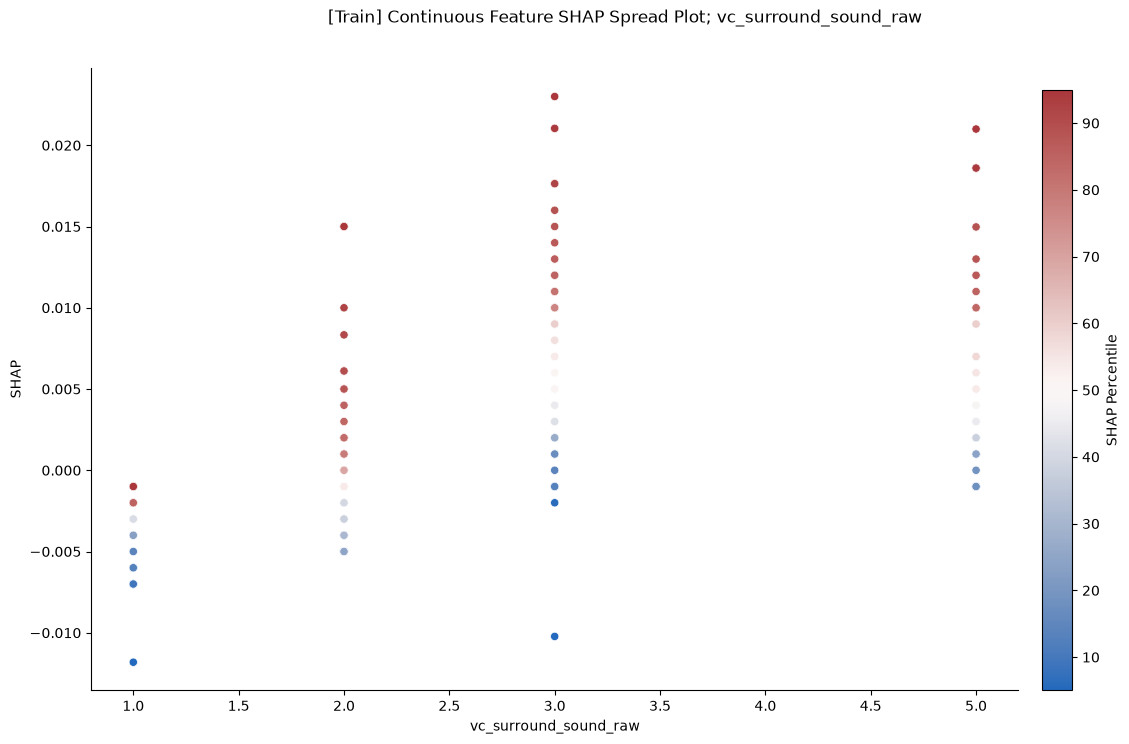

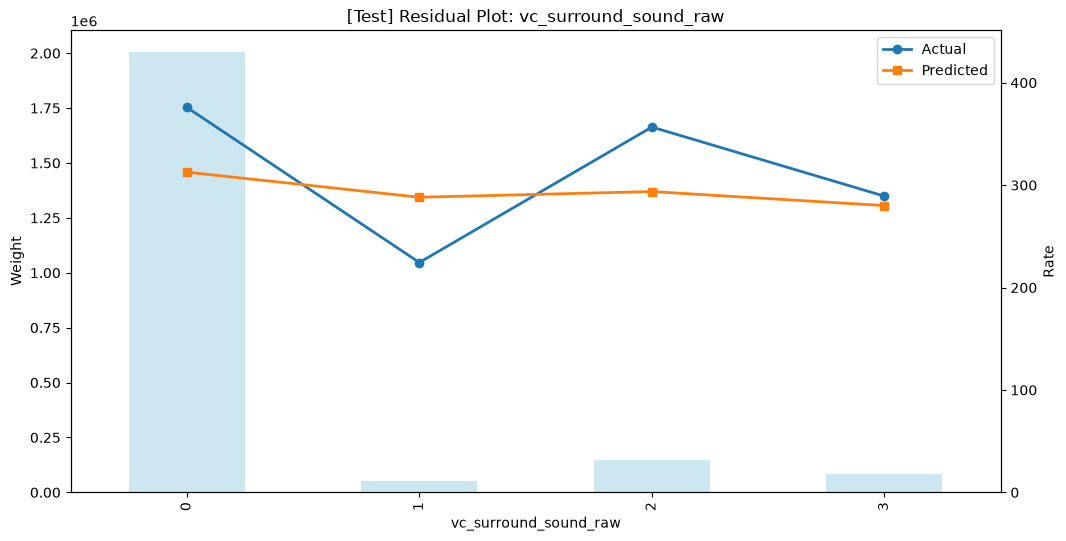

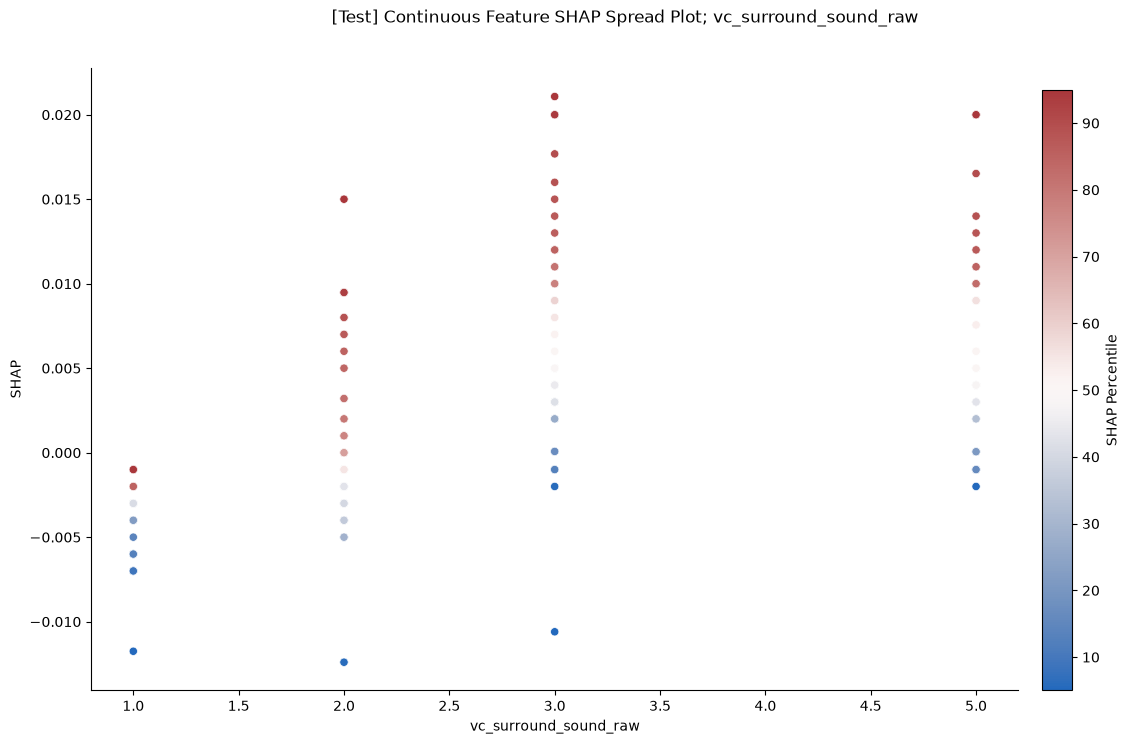


FEATURE: vc_active_parking_assistance_raw


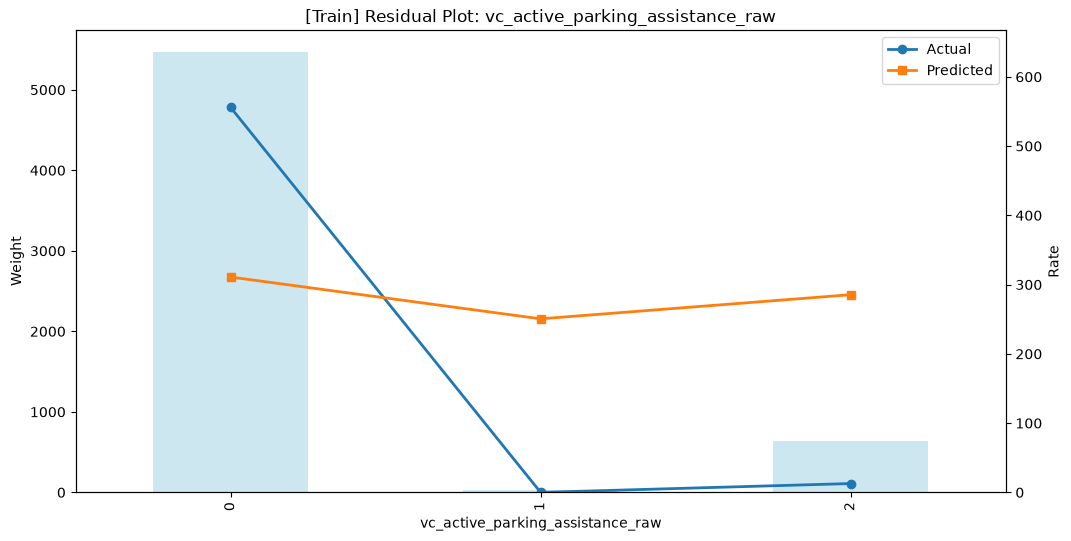

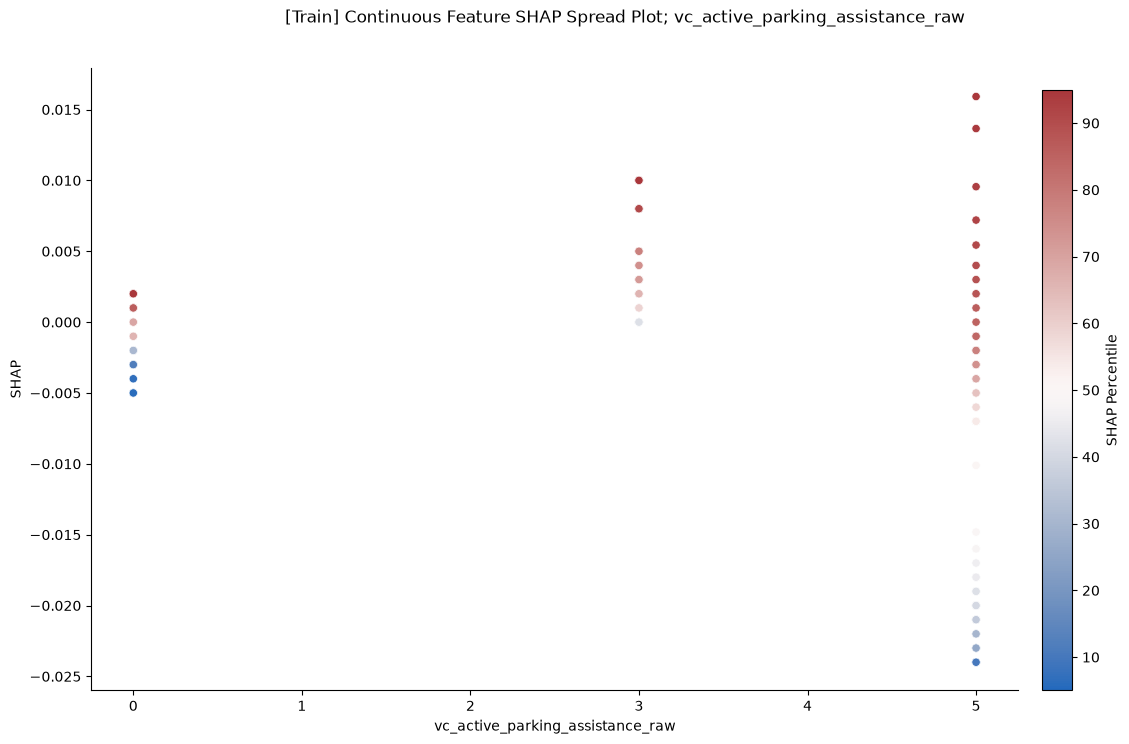

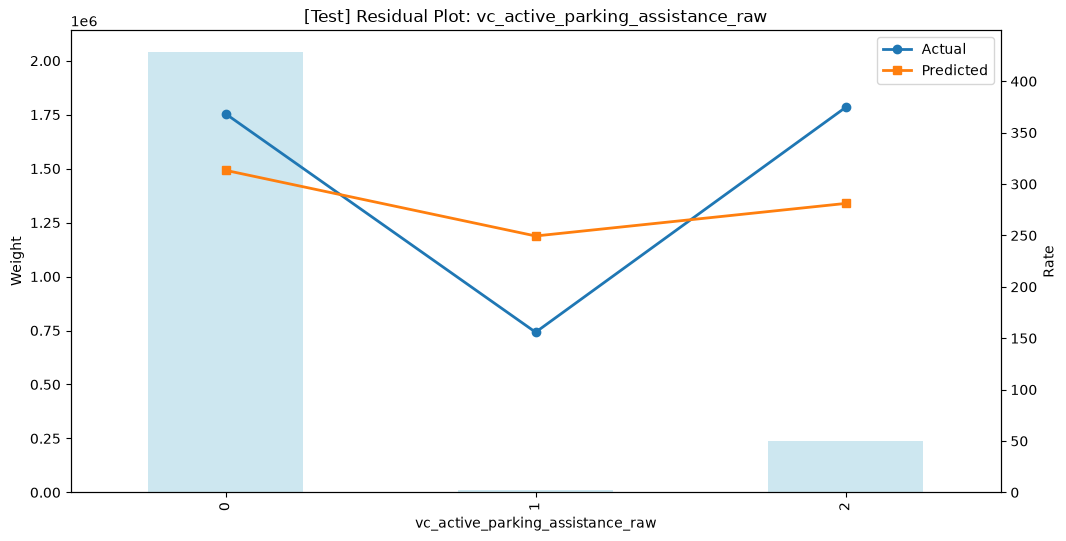

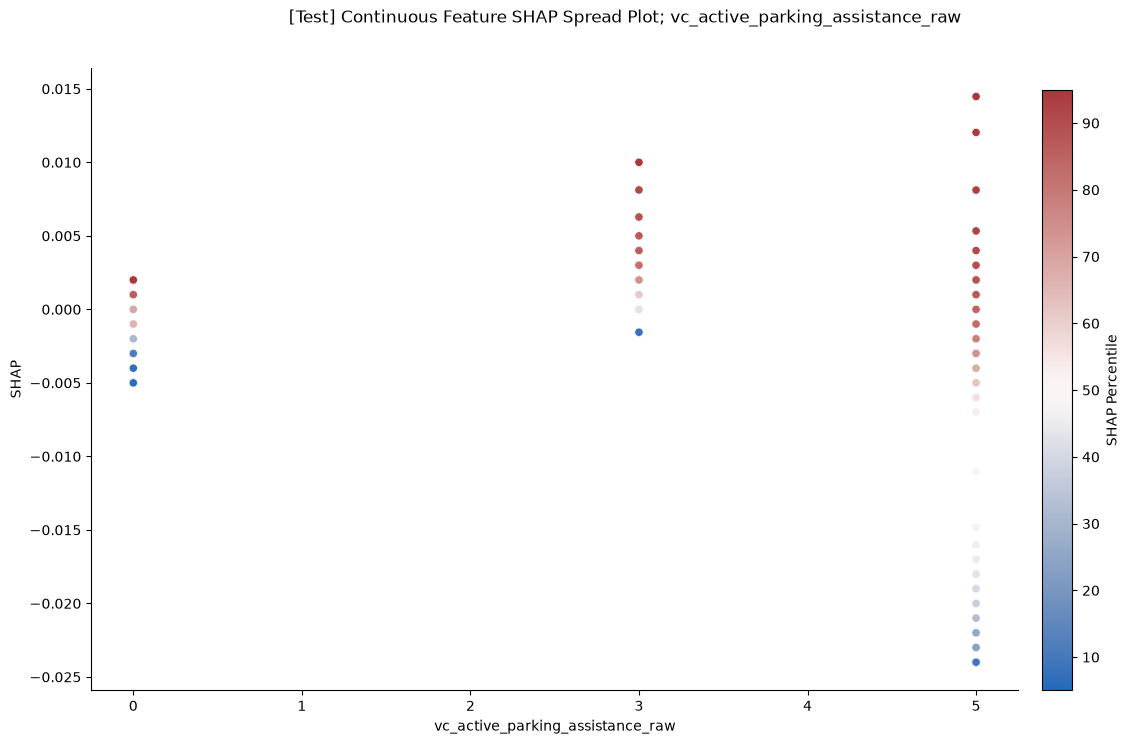


FEATURE: cef_first_cpo_ind


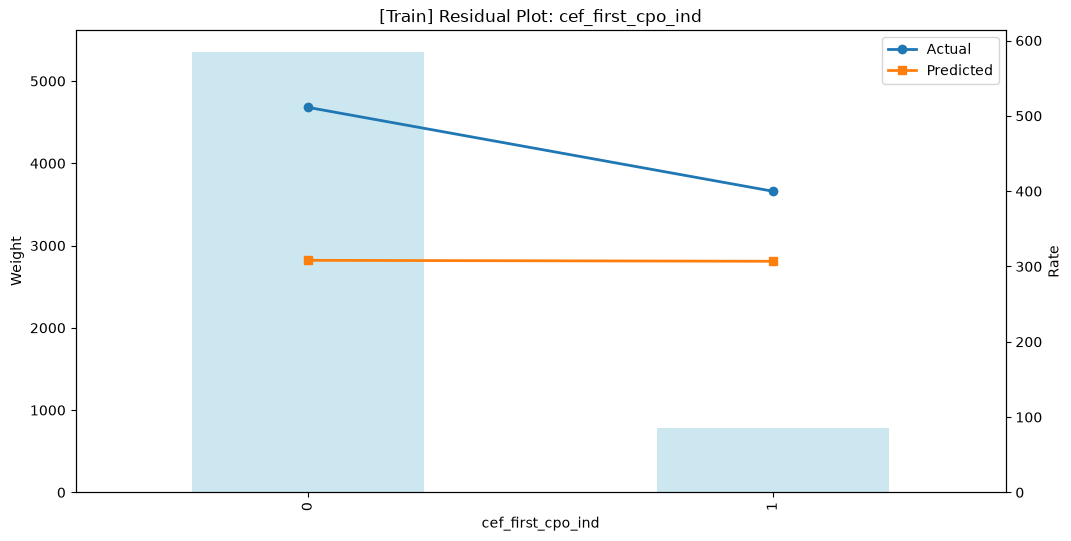

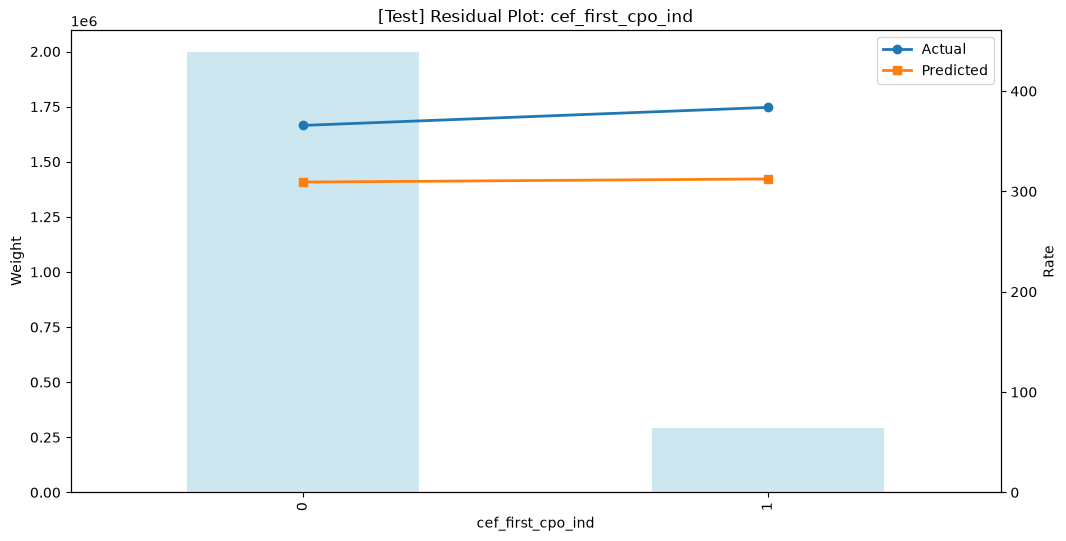


FEATURE: vc_seating_rows_raw


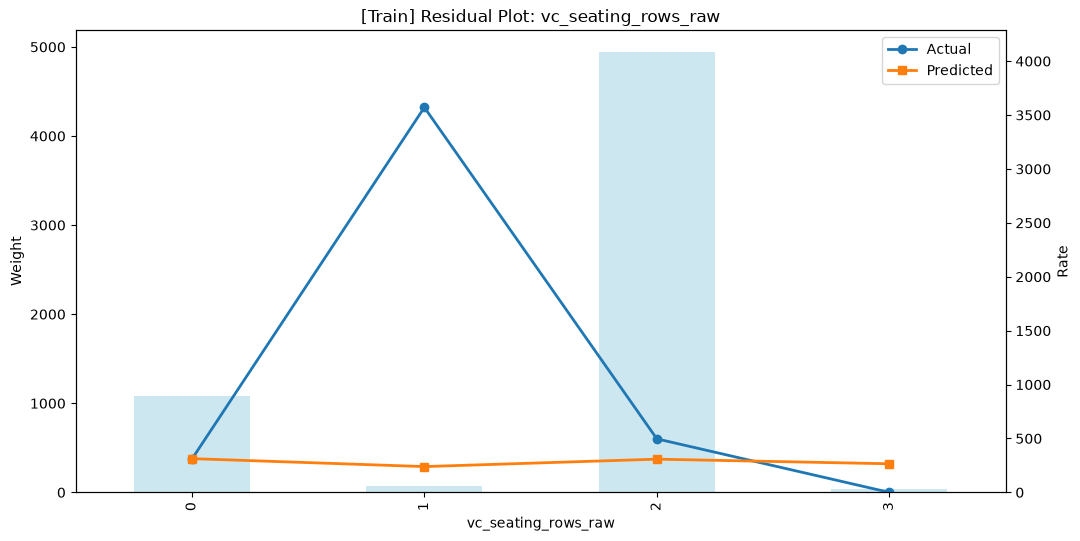

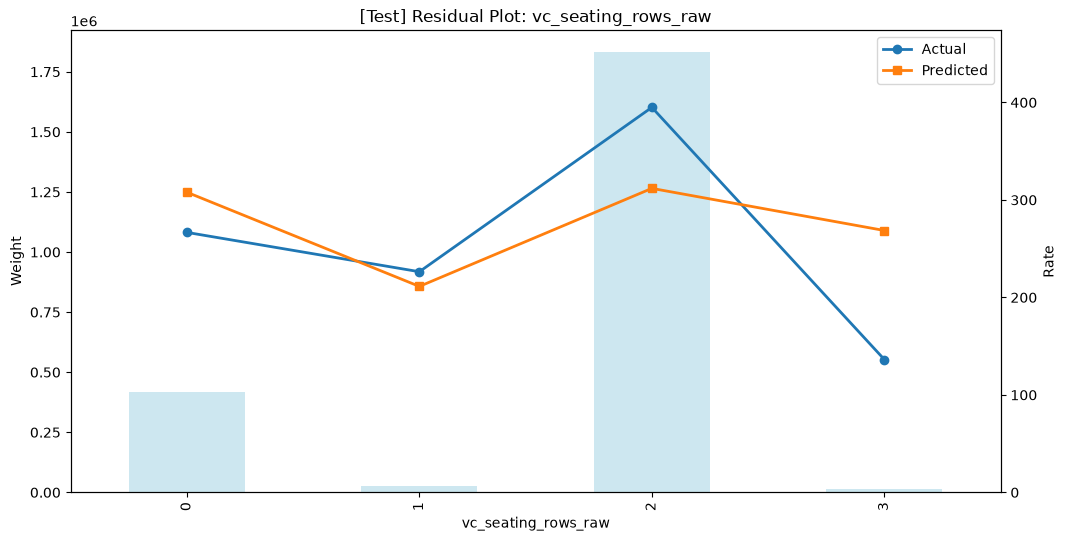


FEATURE: vc_active_driving_assistance_raw


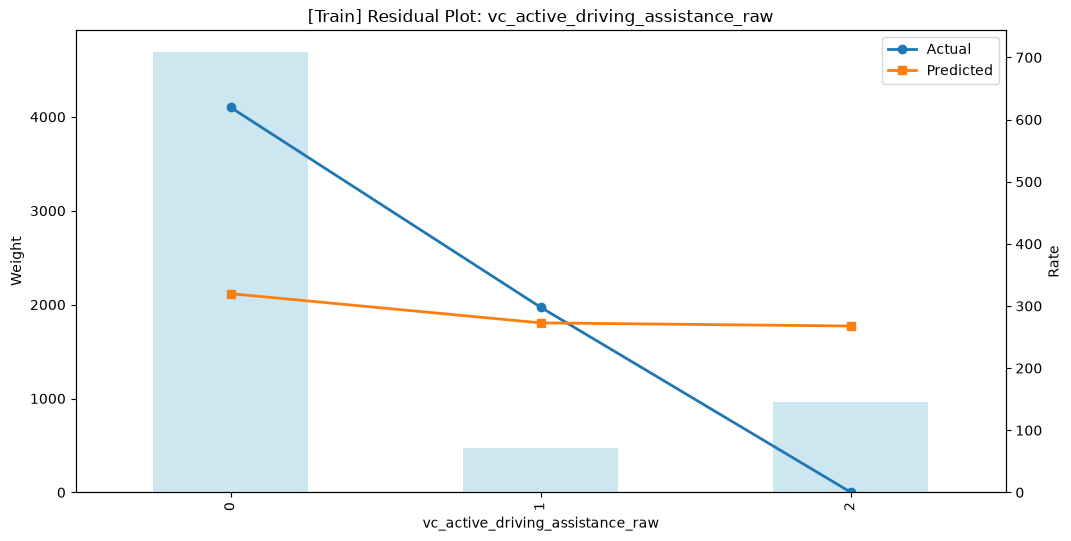

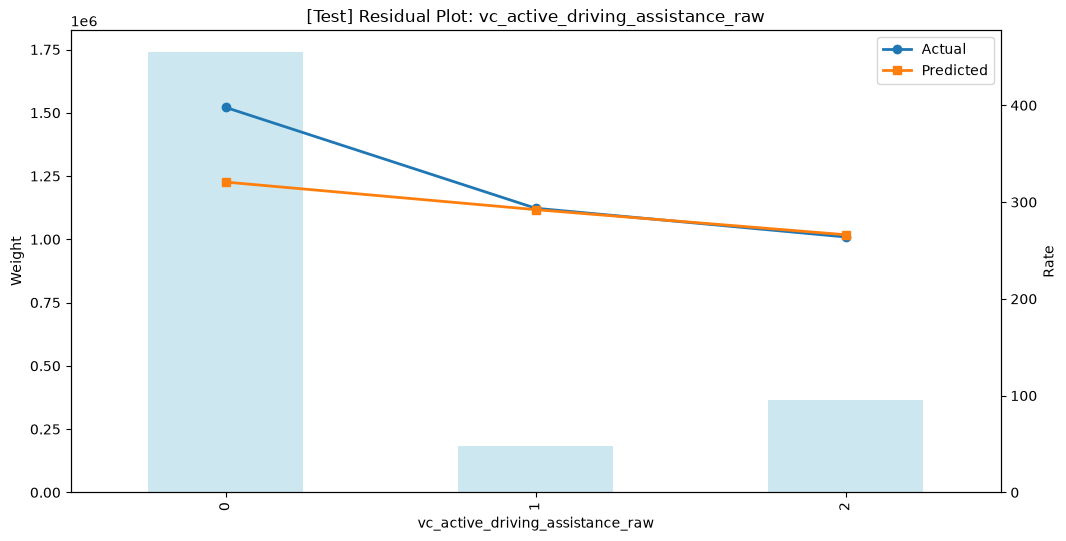


FEATURE: vc_fog_lights_raw


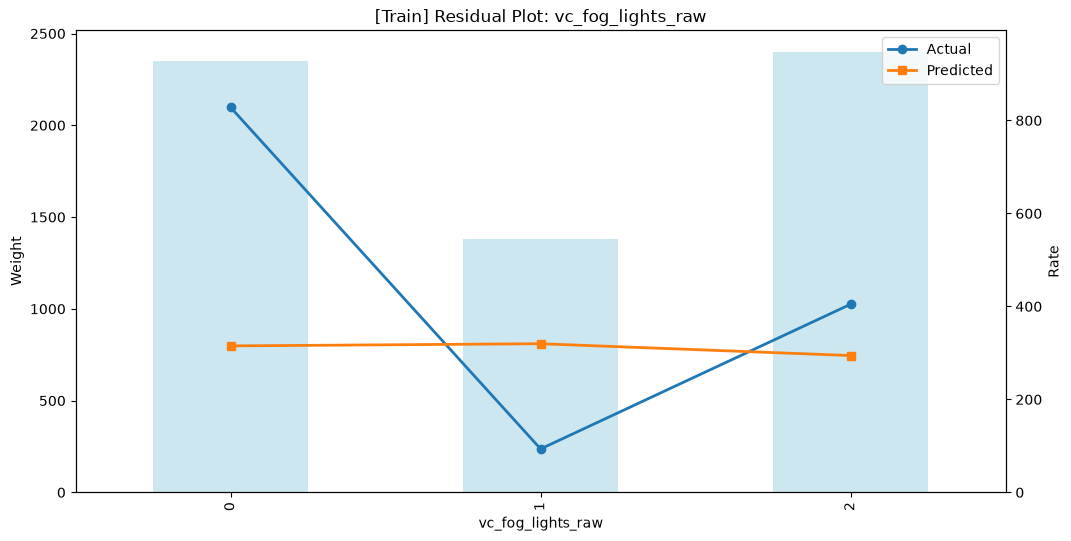

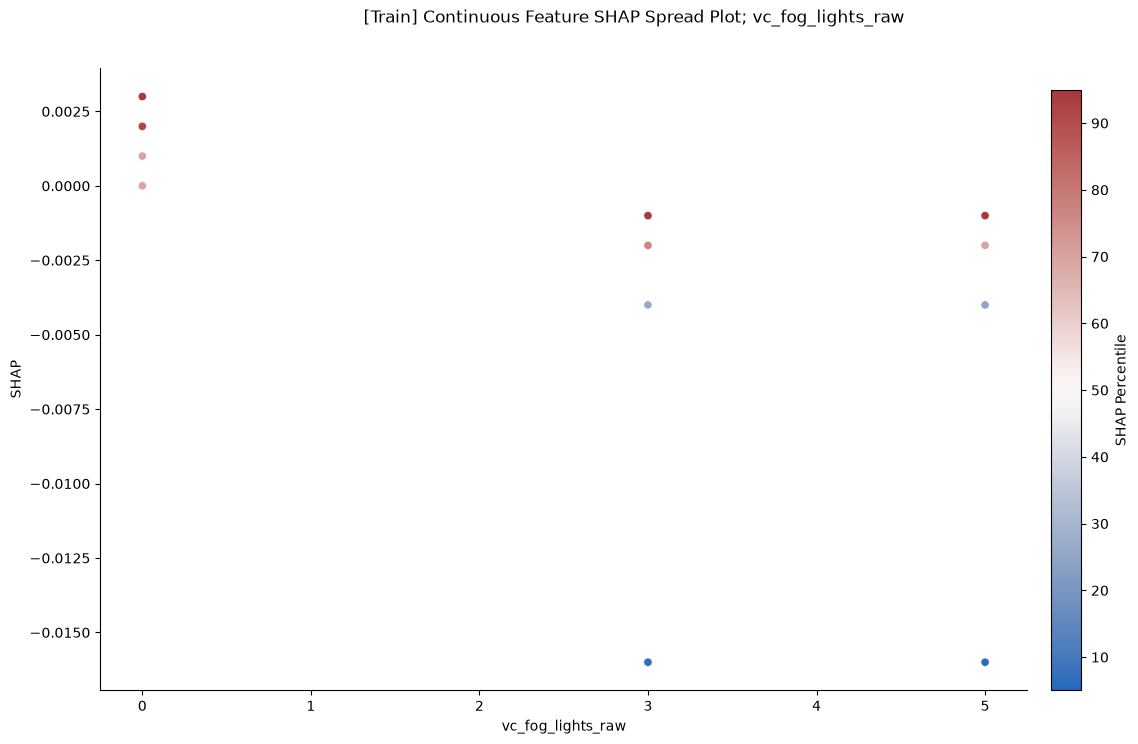

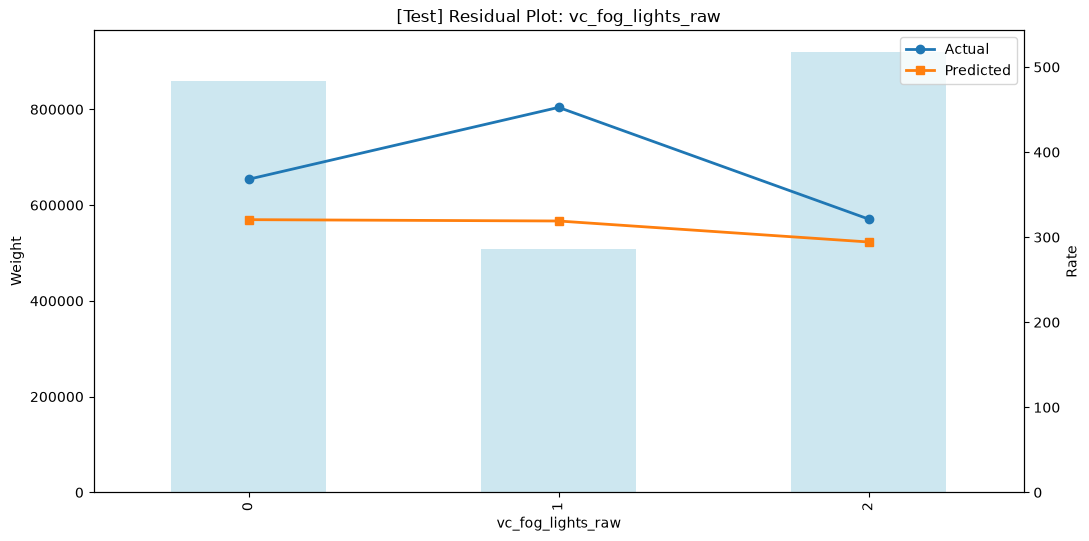

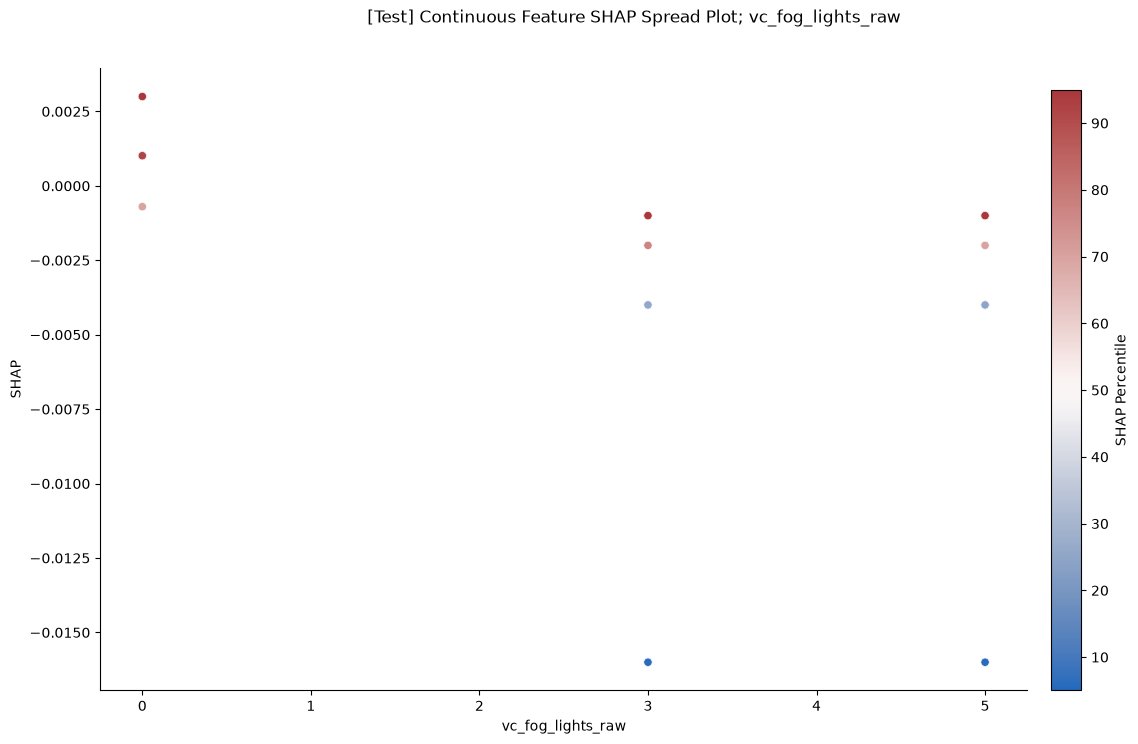


FEATURE: vc_parking_collision_warning_raw


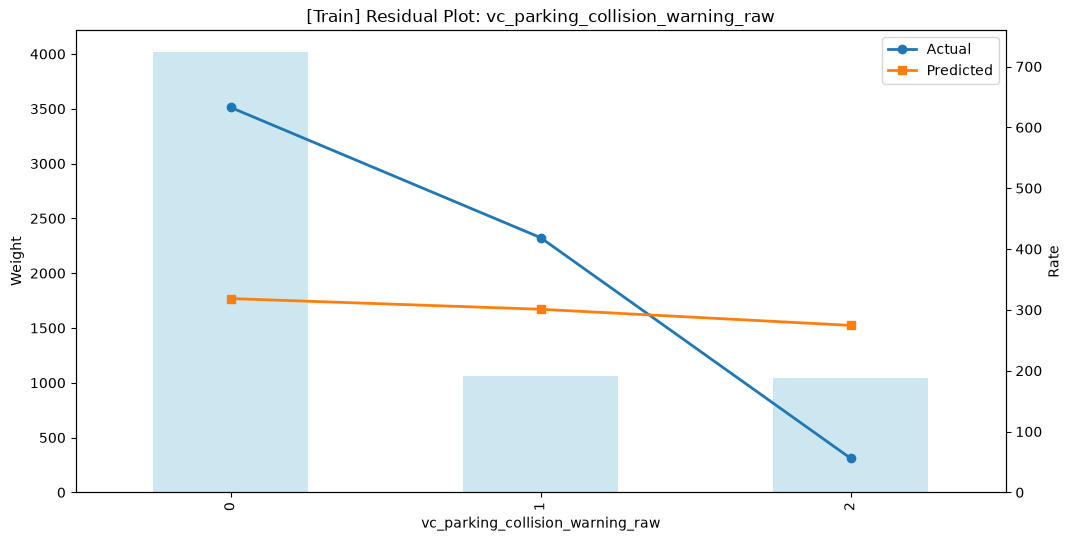

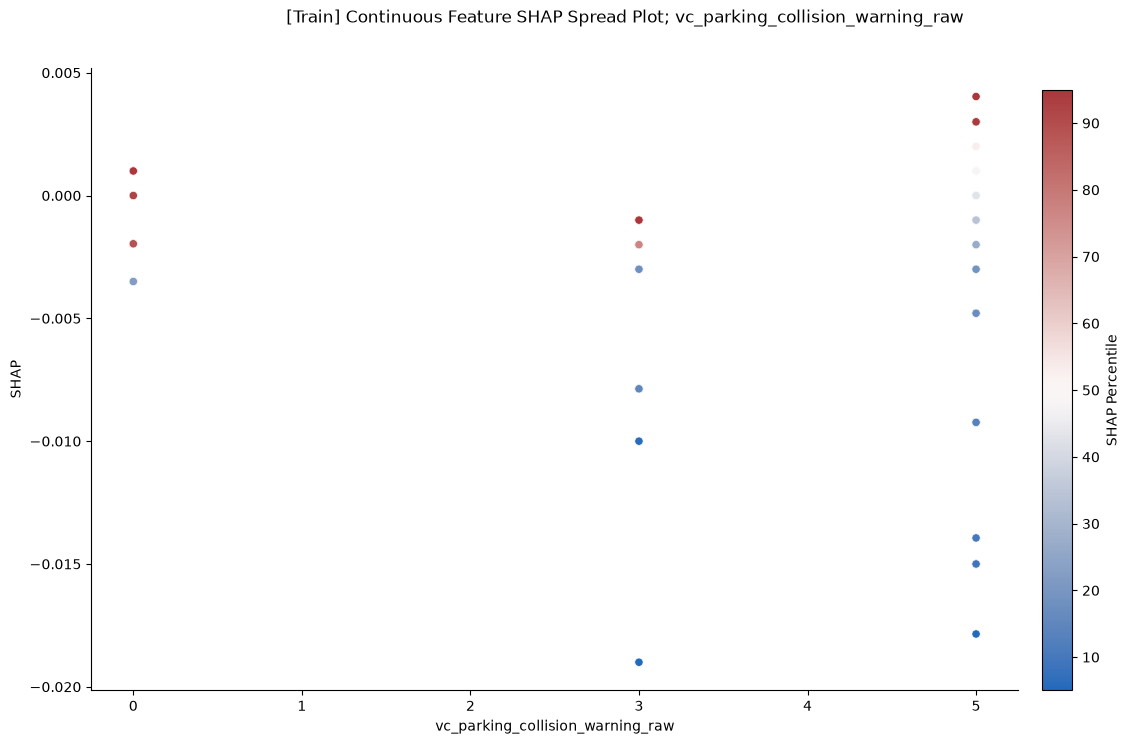

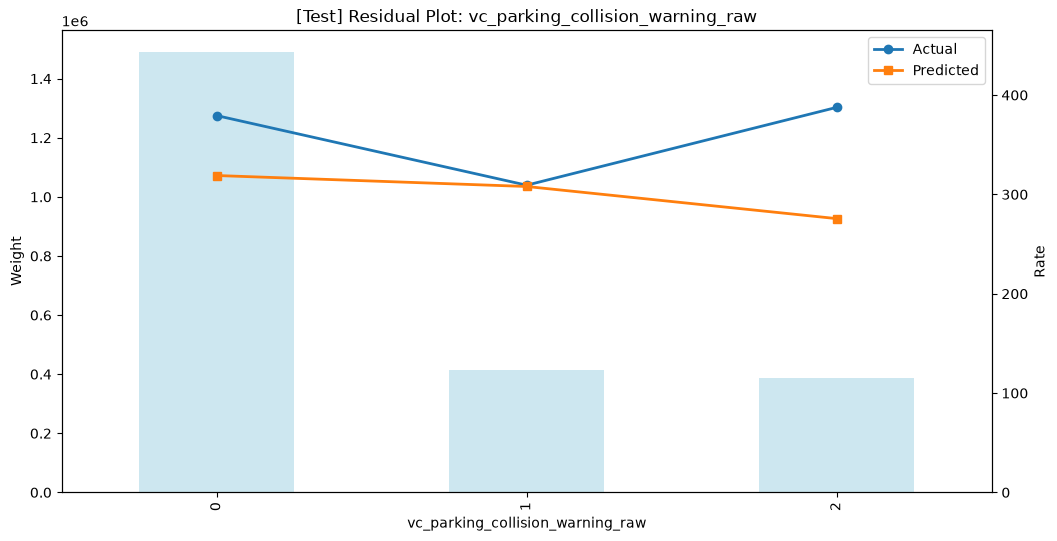

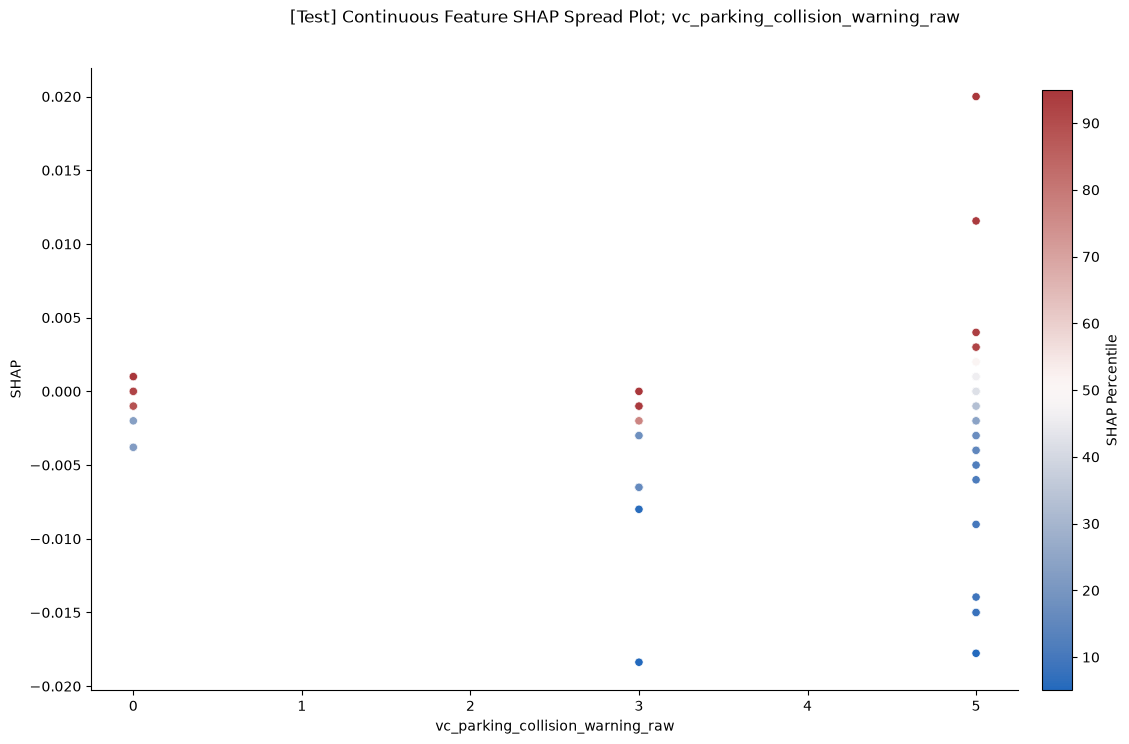


FEATURE: vc_aspiration_forced_induction_ind


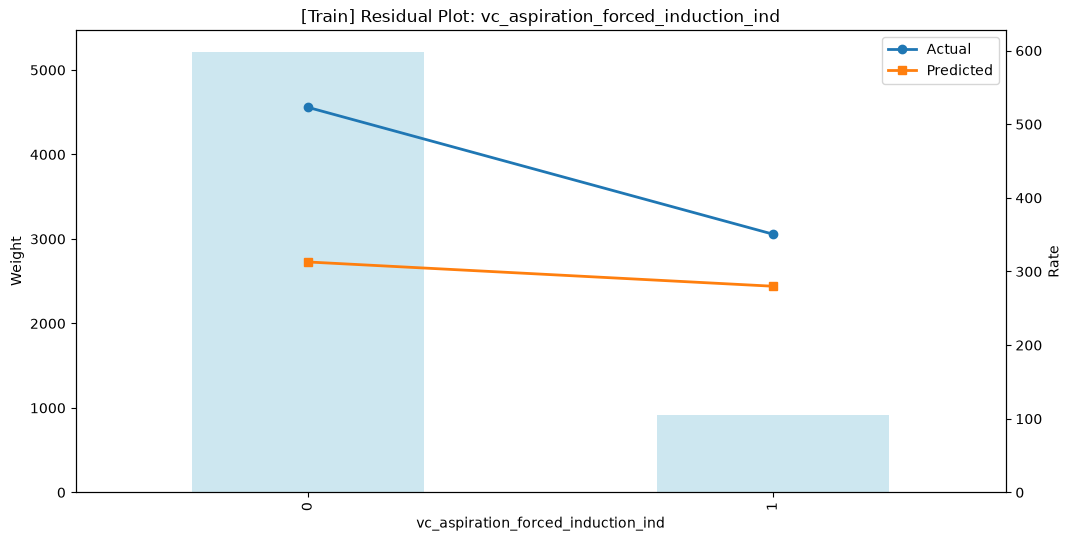

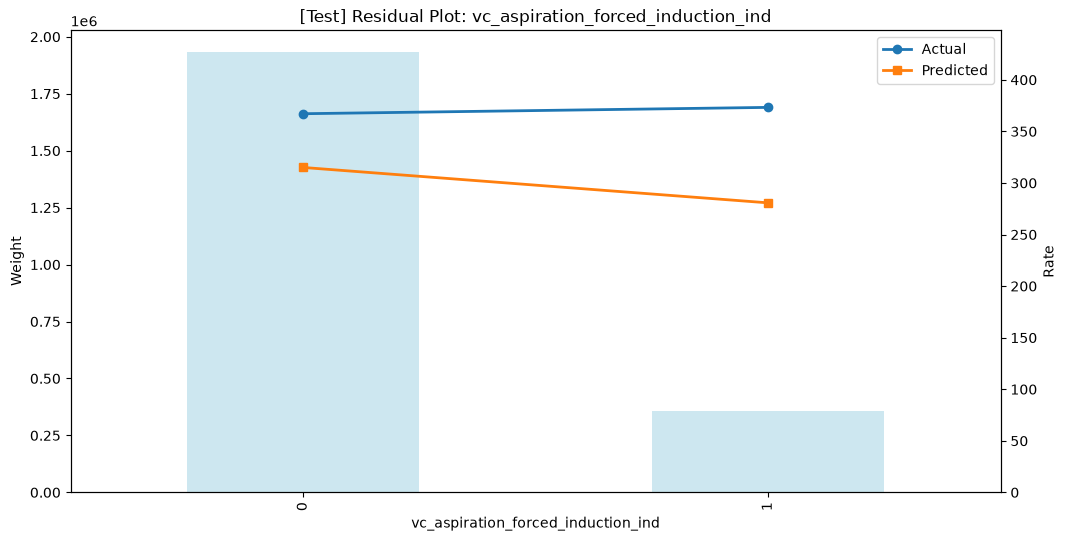


[OK] Displayed 127 plots


In [13]:
from IPython.display import Image, display
print("\n" + "="*60)
print("DISPLAYING ALL PLOTS")
print("="*60)
for f in features:
    if f not in plots_by_feature or not plots_by_feature[f]:
        continue
    print("\n" + "="*60)
    print(f"FEATURE: {f}")
    print("="*60)
    for plot_path in plots_by_feature[f]:
        if Path(plot_path).exists():
            display(Image(filename=plot_path))
        else:
            print(f"WARNING: {plot_path} not found")
print(f"\n[OK] Displayed {sum(len(v) for v in plots_by_feature.values())} plots")

In [14]:
summary["features"] = features
summary["top_n"] = top_n
summary_file = f"{output_base}/results/07_analysis_summary.yaml"
with open(summary_file, "w") as f:
    yaml.dump(summary, f)
print(f"\nSummary: {summary_file}")


Summary: output/car_coll/v1/results/07_analysis_summary.yaml


In [15]:
print("\n" + "#"*40)
print("# STAGE 07: COMPLETE")
print("#"*40)
print(f"Plots: {summary['plots']}")


########################################
# STAGE 07: COMPLETE
########################################
Plots: 127
